# Transformer Based Multimodal Trajectory Prediction on the Waymo Open Motion Dataset

A transformer that predicts a road agent's next 8 seconds of motion from 1.1 seconds of history,
its neighbors, the local road graph, and traffic-light states. It produces 32 candidate futures
("modes"), each with a confidence and per-timestep uncertainty, and scores the best 6. Built and trained in Google Colab on the Waymo Open Motion Dataset.

## Approach

- **Data:** 150 shards of the Waymo Open Motion Dataset, split by shard into train / val / test
  (120 / 15 / 15), ~108k / 13.6k / 13.8k samples.
- **Inputs:** target history plus 8 nearest neighbors, a 768-point road-graph crop centered 30 m
  ahead of the agent, and up to 16 traffic lights. Everything is in the target's agent frame.
- **Model (~6.4M params):** a 6-layer Pre-LN transformer encoder over agent and map tokens, then a
  6-layer decoder with 32 mode queries. Each query is conditioned on a k-means anchor trajectory and
  predicts a residual offset from that anchor (MultiPath style) plus a confidence.
- **Loss:** Gaussian NLL on the single closest-by-path mode (winner-take-all approach) plus cross-entropy on
  the confidences. The predicted standard deviation is floored at ~0.2 m.
- **Selection:** the 6 scored modes are chosen by endpoint non-maximum suppression (MTR style):
  walk modes in descending confidence and skip any whose 8 s endpoint is within 2.5 m of one already
  kept, so near-duplicates don't fill all six slots.
- **Evaluation:** minADE / minFDE / miss rate on the held-out test split, broken down by agent type.
- **Training Env** 6 hrs on Google Colab with A100 GPU

**Model size:** ~6.4M parameters.

In [ ]:
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans

tf.config.set_visible_devices([], "GPU")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"TensorFlow {tf.__version__}, PyTorch {torch.__version__}, device: {DEVICE}")

TensorFlow 2.20.0, PyTorch 2.11.0+cu128, device: cuda


In [ ]:
import os, torch

print(f"CPU cores available: {os.cpu_count()}")
print(f"torch threads before: {torch.get_num_threads()}")
torch.set_num_threads(os.cpu_count())
print(f"torch threads after:  {torch.get_num_threads()}")

CPU cores available: 12
torch threads before: 6
torch threads after:  12


In [ ]:
!gcloud auth login

SHARD_IDS = list(range(150))
DATA_PATHS = []
for shard_id in SHARD_IDS:
    fname = f"training_tfexample.tfrecord-{shard_id:05d}-of-01000"
    local_path = f"./shard_{shard_id:05d}.tfrecord"
    if not os.path.exists(local_path):
        !gsutil cp gs://waymo_open_dataset_motion_v_1_2_0/uncompressed/tf_example/training/{fname} {local_path}
    DATA_PATHS.append(local_path)

print(f"{len(DATA_PATHS)} shards ready: {DATA_PATHS}")

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=un4CiQS6BhYkZoMcgqXVFAkd6hGxCk&prompt=consent&token_usage=remote&access_type=offline&code_challenge=1VOhHwK7PvS1Mt_cvrztfp_xA926OdXZE6IK4gMJhno&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AXlqoi6tkNhbyEIqAZEGZhUIagaRP_QuXhLoqB-k1302KThOX4reKKvbiuELEfZzy_nwnw

You are now logged in as [rajprakashshinde07@gmail.com].
Your current p

In [ ]:
# Constants and tf.Example parsing. Each scene stores a fixed grid of 128 agent
# tracks, a road graph of up to 30k points, and up to 16 traffic lights.

MAX_AGENTS = 8                # agents kept per sample, including target
PAST_STEPS = 10               # state/past/* steps (1s before current, 0.1s resolution)
HIST_STEPS = PAST_STEPS + 1   # past + current (t=0): what the model sees
FUTURE_STEPS = 80             # 8s of future at 0.1s resolution

MAX_ROAD_POINTS = 768         # map-point budget per sample
ROAD_RADIUS_M = 120.0         # crop radius around the (forward-shifted) crop center
ROAD_POINT_STRIDE = 6         # keep every 6th sample along each polyline
ROAD_FORWARD_OFFSET_M = 30.0  # crop center this far ahead of the agent along its yaw

MAX_TRAFFIC_LIGHTS = 16       # Waymo stores up to 16 lights per scene
MAX_ROAD_TOKENS = MAX_ROAD_POINTS + MAX_TRAFFIC_LIGHTS   # map rows first, then light rows

MAX_TARGETS_PER_SCENE = 2     # samples per scene (one per tracks_to_predict agent)

POS_SCALE_M = 50.0            # input positions divided by this (inputs only; outputs stay in meters)
AGENT_FEAT_DIM = 9            # x, y, vx, vy, cos(dyaw), sin(dyaw), is_vehicle, is_pedestrian, is_cyclist
ROAD_FEAT_DIM = 5             # x, y, dir_x, dir_y, tl_time_in_state (0 for map points)

# Waymo object type codes: 0=unset, 1=vehicle, 2=pedestrian, 3=cyclist, 4=other
TYPE_NAMES = {0: "unset", 1: "vehicle", 2: "pedestrian", 3: "cyclist", 4: "other"}
TYPE_COLORS = {0: "gray", 1: "steelblue", 2: "darkorange", 3: "seagreen", 4: "gray"}
AGENT_TYPE_SLOT = {1: 0, 2: 1, 3: 2}   # one-hot slot within the agent feature vector

# Waymo roadgraph_samples/type codes grouped into buckets (waymo.com/open/data/motion/tfexample):
#   1-3 lane centers, 6-13 road lines, 15-16 road edges,
#   17 stop sign, 18 crosswalk, 19 speed bump, 20 driveway
ROAD_TYPE_BUCKET = {t: 1 for t in (1, 2, 3)}
ROAD_TYPE_BUCKET.update({t: 2 for t in range(6, 14)})
ROAD_TYPE_BUCKET.update({t: 3 for t in (15, 16)})
ROAD_TYPE_BUCKET[17] = 4  # stop sign
ROAD_TYPE_BUCKET[18] = 5  # crosswalk
ROAD_TYPE_BUCKET[19] = 6  # speed bump
ROAD_TYPE_BUCKET[20] = 7  # driveway

# Traffic-light tokens use bucket TL_BUCKET_OFFSET + Waymo state code:
#   0 unknown, 1 arrow stop, 2 arrow caution, 3 arrow go, 4 stop, 5 caution,
#   6 go, 7 flashing stop, 8 flashing caution
TL_BUCKET_OFFSET = 8
NUM_TL_STATES = 9
NUM_ROAD_BUCKETS = TL_BUCKET_OFFSET + NUM_TL_STATES   # 17; bucket 0 = unset/other

ROAD_TYPE_LUT = np.zeros(64, dtype=np.int64)   # vectorized type -> bucket lookup
for _t, _b in ROAD_TYPE_BUCKET.items():
    ROAD_TYPE_LUT[_t] = _b

# Plot styles: lines for polylines, markers for point-like features and lights
ROAD_BUCKET_STYLE = {
    1: dict(color="lightgray", kind="line", lw=1.0, label="lane center"),
    2: dict(color="khaki", kind="line", lw=1.0, label="road line"),
    3: dict(color="dimgray", kind="line", lw=1.4, label="road edge"),
    4: dict(color="red", kind="point", marker="x", size=40, label="stop sign"),
    5: dict(color="royalblue", kind="point", marker="s", size=10, label="crosswalk"),
    6: dict(color="orange", kind="point", marker="^", size=14, label="speed bump"),
    7: dict(color="silver", kind="line", lw=0.8, label="driveway"),
    0: dict(color="whitesmoke", kind="point", marker=".", size=3, label="other map"),
}
_TL_STYLE = {  # state code -> (color, marker, label)
    0: ("gray", "o", "light: unknown"),
    1: ("red", "D", "light: arrow stop"), 2: ("orange", "D", "light: arrow caution"), 3: ("limegreen", "D", "light: arrow go"),
    4: ("red", "o", "light: stop"), 5: ("orange", "o", "light: caution"), 6: ("limegreen", "o", "light: go"),
    7: ("red", "h", "light: flashing stop"), 8: ("orange", "h", "light: flashing caution"),
}
for _s, (_c, _mk, _lb) in _TL_STYLE.items():
    ROAD_BUCKET_STYLE[TL_BUCKET_OFFSET + _s] = dict(color=_c, kind="point", marker=_mk, size=70, label=_lb)

feature_spec = {
    "state/type": tf.io.FixedLenFeature([128], tf.float32, default_value=None),
    "state/past/x": tf.io.FixedLenFeature([128, PAST_STEPS], tf.float32, default_value=None),
    "state/past/y": tf.io.FixedLenFeature([128, PAST_STEPS], tf.float32, default_value=None),
    "state/past/velocity_x": tf.io.FixedLenFeature([128, PAST_STEPS], tf.float32, default_value=None),
    "state/past/velocity_y": tf.io.FixedLenFeature([128, PAST_STEPS], tf.float32, default_value=None),
    "state/past/bbox_yaw": tf.io.FixedLenFeature([128, PAST_STEPS], tf.float32, default_value=None),
    "state/past/valid": tf.io.FixedLenFeature([128, PAST_STEPS], tf.int64, default_value=None),
    "state/current/x": tf.io.FixedLenFeature([128, 1], tf.float32, default_value=None),
    "state/current/y": tf.io.FixedLenFeature([128, 1], tf.float32, default_value=None),
    "state/current/velocity_x": tf.io.FixedLenFeature([128, 1], tf.float32, default_value=None),
    "state/current/velocity_y": tf.io.FixedLenFeature([128, 1], tf.float32, default_value=None),
    "state/current/bbox_yaw": tf.io.FixedLenFeature([128, 1], tf.float32, default_value=None),
    "state/current/valid": tf.io.FixedLenFeature([128, 1], tf.int64, default_value=None),
    "state/future/x": tf.io.FixedLenFeature([128, FUTURE_STEPS], tf.float32, default_value=None),
    "state/future/y": tf.io.FixedLenFeature([128, FUTURE_STEPS], tf.float32, default_value=None),
    "state/future/valid": tf.io.FixedLenFeature([128, FUTURE_STEPS], tf.int64, default_value=None),
    "state/tracks_to_predict": tf.io.FixedLenFeature([128], tf.int64, default_value=None),
    "roadgraph_samples/xyz": tf.io.FixedLenFeature([30000, 3], tf.float32, default_value=None),
    "roadgraph_samples/dir": tf.io.FixedLenFeature([30000, 3], tf.float32, default_value=None),
    "roadgraph_samples/type": tf.io.FixedLenFeature([30000, 1], tf.int64, default_value=None),
    "roadgraph_samples/id": tf.io.FixedLenFeature([30000, 1], tf.int64, default_value=None),
    "roadgraph_samples/valid": tf.io.FixedLenFeature([30000, 1], tf.int64, default_value=None),
}
# Traffic lights: [time, light] grids (10 past steps, 1 current step)
for _k, _dt in (("state", tf.int64), ("valid", tf.int64), ("x", tf.float32), ("y", tf.float32)):
    feature_spec[f"traffic_light_state/past/{_k}"] = tf.io.FixedLenFeature([PAST_STEPS, MAX_TRAFFIC_LIGHTS], _dt, default_value=None)
    feature_spec[f"traffic_light_state/current/{_k}"] = tf.io.FixedLenFeature([1, MAX_TRAFFIC_LIGHTS], _dt, default_value=None)

def parse_scene(serialized_example):
    return tf.io.parse_single_example(serialized_example, feature_spec)

def load_dataset(paths):
    """Loads one shard path or a list of shard paths as a single parsed dataset."""
    if isinstance(paths, str):
        paths = [paths]
    return tf.data.TFRecordDataset(paths, compression_type="").map(parse_scene)


In [ ]:
# Scene extraction: road-graph cropping, traffic lights, and one sample per
# tracks_to_predict agent (target at row 0, nearest valid neighbors as context).

def extract_road_graph(parsed_scene, origin_xy, radius=ROAD_RADIUS_M, max_points=MAX_ROAD_POINTS,
                       square=False, forward_dir=None, forward_offset=0.0, stride=1):
    """Crops the road graph. Returns (xy, bucket, feature_id, dir_xy) in world coordinates.

    stride: keep every `stride`-th point per polyline (plus each polyline's
      first point and all stop signs / speed bumps).
    forward_dir / forward_offset: shift the crop center ahead of the agent.
    square=True: square crop (visualization only).
    Beyond max_points, the points farthest from the crop center are dropped.
    """
    xyz = parsed_scene["roadgraph_samples/xyz"].numpy()
    rdir = parsed_scene["roadgraph_samples/dir"].numpy()
    rtype = parsed_scene["roadgraph_samples/type"].numpy().reshape(-1).astype(int)
    rid = parsed_scene["roadgraph_samples/id"].numpy().reshape(-1).astype(int)
    rvalid = parsed_scene["roadgraph_samples/valid"].numpy().reshape(-1).astype(bool)

    empty = (np.zeros((0, 2), np.float32), np.zeros((0,), np.int64),
             np.zeros((0,), np.int64), np.zeros((0, 2), np.float32))

    n = len(rtype)
    if stride > 1:
        starts = np.r_[True, rid[1:] != rid[:-1]]
        seg_start = np.maximum.accumulate(np.where(starts, np.arange(n), 0))
        pos_in_seg = np.arange(n) - seg_start
        point_like = np.isin(rtype, (17, 19))
        keep = rvalid & ((pos_in_seg % stride == 0) | point_like)
    else:
        keep = rvalid
    idx = np.where(keep)[0]
    if len(idx) == 0:
        return empty

    xy, types, ids, dirs = xyz[idx, :2], rtype[idx], rid[idx], rdir[idx, :2]

    center = np.asarray(origin_xy, dtype=np.float64)
    if forward_dir is not None and forward_offset != 0.0:
        center = center + forward_offset * np.asarray(forward_dir, dtype=np.float64)
    offset = xy - center
    dist = np.abs(offset).max(axis=1) if square else np.linalg.norm(offset, axis=1)

    within = np.where(dist <= radius)[0]
    if len(within) > max_points:
        within = within[np.argsort(dist[within])[:max_points]]
        within.sort()  # restore sequential-along-polyline order
    if len(within) == 0:
        return empty

    bucket = ROAD_TYPE_LUT[np.clip(types[within], 0, len(ROAD_TYPE_LUT) - 1)]
    return (xy[within].astype(np.float32), bucket.astype(np.int64),
            ids[within].astype(np.int64), dirs[within].astype(np.float32))


def extract_traffic_lights(parsed_scene):
    """Lights valid at t=0 -> (xy [K, 2] world, bucket [K], time_in_state [K]).
    time_in_state is the fraction of the 1.1s history the light has held its
    current state (1.0 = unchanged, small = just changed)."""
    st = np.concatenate([parsed_scene["traffic_light_state/past/state"].numpy(),
                         parsed_scene["traffic_light_state/current/state"].numpy()], axis=0)   # [11, L]
    va = np.concatenate([parsed_scene["traffic_light_state/past/valid"].numpy(),
                         parsed_scene["traffic_light_state/current/valid"].numpy()], axis=0) > 0
    cx = parsed_scene["traffic_light_state/current/x"].numpy()[0]
    cy = parsed_scene["traffic_light_state/current/y"].numpy()[0]

    lights = np.where(va[-1])[0]
    if len(lights) == 0:
        return np.zeros((0, 2), np.float32), np.zeros((0,), np.int64), np.zeros((0,), np.float32)

    cur = st[-1, lights]
    same = va[:, lights] & (st[:, lights] == cur[None, :])            # [11, K]
    # length of the unbroken run of `same` ending at t=0
    broken = ~same[::-1]                                              # reversed time
    run = np.where(broken.any(axis=0), broken.argmax(axis=0), HIST_STEPS)
    time_in_state = (run / HIST_STEPS).astype(np.float32)

    bucket = TL_BUCKET_OFFSET + np.clip(cur, 0, NUM_TL_STATES - 1)
    xy = np.stack([cx[lights], cy[lights]], axis=1).astype(np.float32)
    return xy, bucket.astype(np.int64), time_in_state


def _hist(parsed_scene, key):
    """[128, HIST_STEPS]: the 10 past steps followed by current (last column = t=0)."""
    past = parsed_scene[f"state/past/{key}"].numpy()
    cur = parsed_scene[f"state/current/{key}"].numpy()
    return np.concatenate([past, cur], axis=1)


def extract_scene_agents(parsed_scene, max_agents=MAX_AGENTS, max_targets=MAX_TARGETS_PER_SCENE):
    x, y = _hist(parsed_scene, "x"), _hist(parsed_scene, "y")
    vx, vy = _hist(parsed_scene, "velocity_x"), _hist(parsed_scene, "velocity_y")
    yaw = _hist(parsed_scene, "bbox_yaw")
    valid = _hist(parsed_scene, "valid")
    obj_type = parsed_scene["state/type"].numpy().astype(int)
    fut_x = parsed_scene["state/future/x"].numpy()
    fut_y = parsed_scene["state/future/y"].numpy()
    fut_valid = parsed_scene["state/future/valid"].numpy()
    to_predict = parsed_scene["state/tracks_to_predict"].numpy()
    tl_xy, tl_type, tl_time = extract_traffic_lights(parsed_scene)

    # each agent's last valid history position, used to rank neighbors
    last_t = np.where(valid > 0, np.arange(HIST_STEPS), -1).max(axis=1)
    has_hist = last_t >= 0
    rows = np.arange(len(last_t))
    safe_t = np.maximum(last_t, 0)
    last_xy = np.stack([x[rows, safe_t], y[rows, safe_t]], axis=1)

    samples = []
    for target_idx in np.where(to_predict == 1)[0]:
        if len(samples) >= max_targets:
            break
        # target needs a valid CURRENT state (defines the frame) and some future
        if valid[target_idx, -1] == 0 or fut_valid[target_idx].sum() == 0:
            continue

        origin = np.array([x[target_idx, -1], y[target_idx, -1]], dtype=np.float32)
        yaw0 = float(yaw[target_idx, -1])

        others = np.where(has_hist)[0]
        others = others[others != target_idx]
        dists = np.linalg.norm(last_xy[others] - origin, axis=1)
        nearest = others[np.argsort(dists)[: max_agents - 1]]
        selected = np.concatenate([[target_idx], nearest]).astype(int)

        road_xy, road_type, road_id, road_dir = extract_road_graph(
            parsed_scene, origin,
            forward_dir=(math.cos(yaw0), math.sin(yaw0)), forward_offset=ROAD_FORWARD_OFFSET_M,
            stride=ROAD_POINT_STRIDE,
        )

        samples.append({
            "target_idx": 0,               # target is always row 0
            "agent_ids": selected,
            "type": obj_type[selected],
            "x": x[selected], "y": y[selected],                # [A, HIST_STEPS], world coords
            "vx": vx[selected], "vy": vy[selected],
            "bbox_yaw": yaw[selected],
            "valid": valid[selected],
            "future_x": fut_x[selected], "future_y": fut_y[selected],
            "future_valid": fut_valid[selected],
            "origin": origin,              # target's current position (world)
            "yaw0": yaw0,                  # target's current yaw (world) -> agent frame +x
            "road_xy": road_xy, "road_type": road_type,        # world coords, cropped
            "road_id": road_id, "road_dir": road_dir,
            "tl_xy": tl_xy, "tl_type": tl_type, "tl_time": tl_time,   # world coords
        })
    return samples


def draw_road_graph(ax, road_xy, road_type, road_id, zorder=1):
    """Draws polylines (lane centers, road lines, road edges) as lines grouped
    by feature id, and point features and traffic lights as markers."""
    if road_xy is None or len(road_xy) == 0:
        return
    seen_labels = set()
    for bucket, style in ROAD_BUCKET_STYLE.items():
        mask = road_type == bucket
        if mask.sum() == 0:
            continue
        label = style["label"] if style["label"] not in seen_labels else None
        seen_labels.add(style["label"])

        if style["kind"] == "line":
            for feat_id in np.unique(road_id[mask]):
                seg_mask = mask & (road_id == feat_id)
                if seg_mask.sum() < 2:
                    continue
                ax.plot(
                    road_xy[seg_mask, 0], road_xy[seg_mask, 1],
                    "-", color=style["color"], linewidth=style["lw"],
                    alpha=0.9, zorder=zorder, label=label,
                )
                label = None
        else:
            is_light = bucket >= TL_BUCKET_OFFSET
            ax.scatter(
                road_xy[mask, 0], road_xy[mask, 1],
                s=style["size"], c=style["color"], marker=style["marker"],
                alpha=0.9, zorder=zorder + (3 if is_light else 0), label=label,
                edgecolors="black" if is_light else "none", linewidths=0.6,
            )


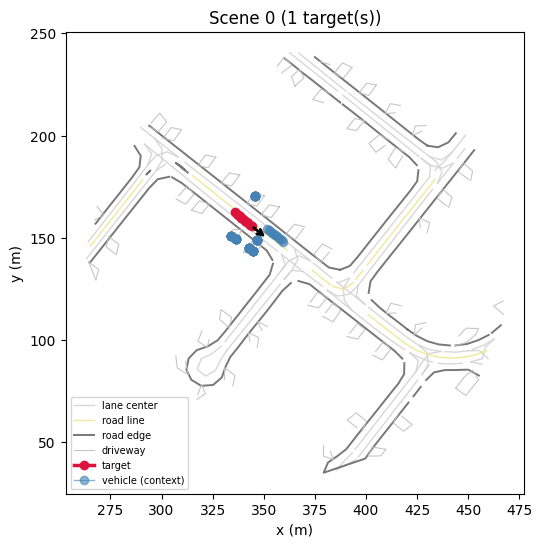

/tmp/ipykernel_4030/610047860.py:177: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


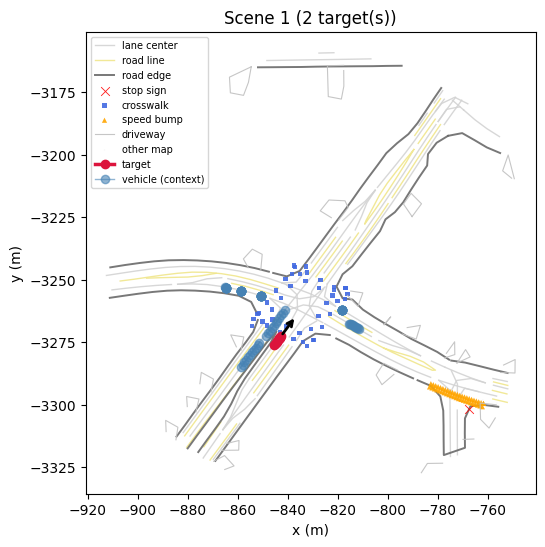

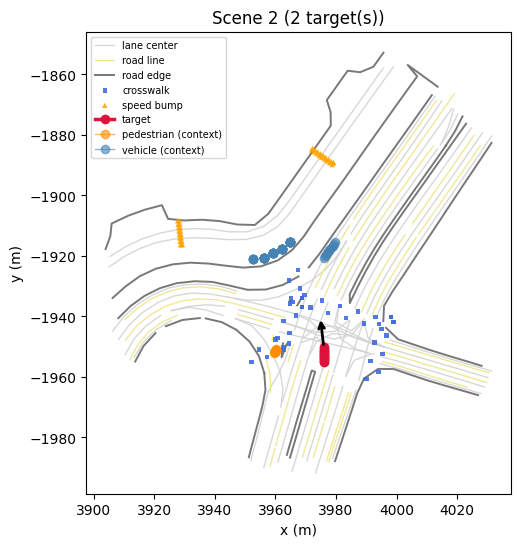

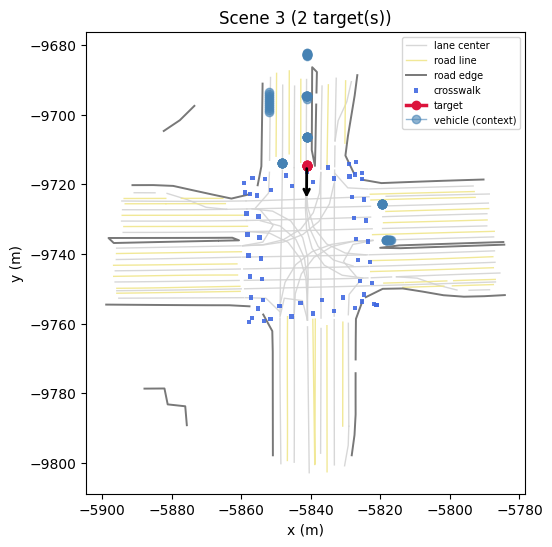

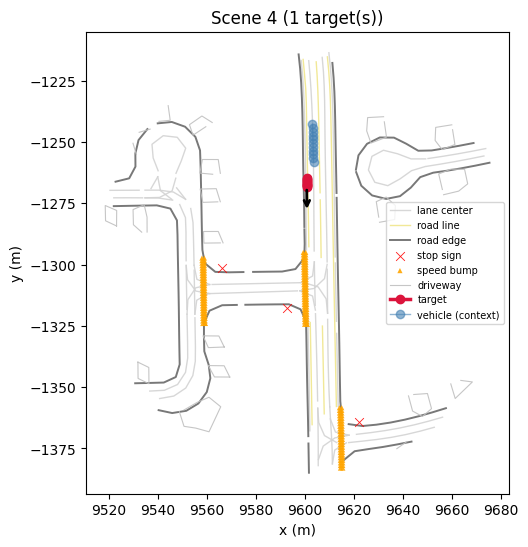

In [ ]:
# Sanity check: render a few scenes (world coords, first target per scene)
# to confirm parsing before building any model on top.

def plot_scene(scene, title="Scene"):
    fig, ax = plt.subplots(figsize=(6, 6))

    draw_road_graph(ax, scene.get("road_xy"), scene.get("road_type"), scene.get("road_id"))

    seen_labels = set()
    for i in range(scene["x"].shape[0]):
        mask = scene["valid"][i] > 0
        if mask.sum() == 0:
            continue
        xs, ys = scene["x"][i][mask], scene["y"][i][mask]
        obj_type = int(scene["type"][i])
        color = TYPE_COLORS.get(obj_type, "gray")
        type_label = TYPE_NAMES.get(obj_type, "unset")

        if i == 0:
            label = "target" if "target" not in seen_labels else None
            ax.plot(xs, ys, "o-", color="crimson", linewidth=2.5, zorder=3, label=label)
            seen_labels.add("target")
        else:
            label = f"{type_label} (context)" if type_label not in seen_labels else None
            ax.plot(xs, ys, "o-", color=color, alpha=0.6, linewidth=1, zorder=2, label=label)
            seen_labels.add(type_label)

    # target's current yaw (defines the model's agent frame)
    ox, oy = scene["origin"]
    ax.annotate("", xy=(ox + 10 * math.cos(scene["yaw0"]), oy + 10 * math.sin(scene["yaw0"])),
                xytext=(ox, oy), arrowprops=dict(arrowstyle="->", color="black", lw=2))

    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend(loc="best", fontsize=7)
    ax.set_aspect("equal")
    plt.show()

ds = load_dataset(DATA_PATHS)
for i, parsed_scene in enumerate(ds.take(5)):
    samples = extract_scene_agents(parsed_scene)
    if samples:
        plot_scene(samples[0], title=f"Scene {i} ({len(samples)} target(s))")


In [24]:
# The model. An encoder reads the agents and the road; a decoder turns the mode
# queries into that many possible futures. Each mode predicts a small offset from a
# fixed anchor path, its own per-step uncertainty, and a confidence score. Everything
# is in the target's own frame (it sits at the origin, facing +x).
# The final coordinate math runs in fp32 even under bf16 autocast, because bf16 is too
# coarse (~3 digits) for positions in metres.

NUM_MODES = 32         # one mode per k-means anchor
EVAL_TOP_K = 6         # we score the best 6 modes (Waymo's convention)
D_MODEL = 192
N_HEADS = 4
N_LAYERS = 6           # encoder layers
DECODER_ROUNDS = 6     # decoder layers (modes attend to each other and to the scene)
FF_DIM = 768
DECODER_FF_DIM = 768   # decoder FFN width and per-timestep MLP width
DROPOUT = 0.1

LOG_STD_MIN = -1.6     # clamp the predicted uncertainty to this range
LOG_STD_MAX = 2.0      # (roughly sigma in [0.2, 7.4] metres)


class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding."""

    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [seq_len, batch, d_model]
        return x + self.pe[: x.size(0)].unsqueeze(1)


class TrajectoryTransformer(nn.Module):
    def __init__(
        self,
        feat_dim=AGENT_FEAT_DIM,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        decoder_rounds=DECODER_ROUNDS,
        ff_dim=FF_DIM,
        decoder_ff_dim=DECODER_FF_DIM,
        num_modes=NUM_MODES,
        max_agents=MAX_AGENTS,
        past_steps=HIST_STEPS,
        future_steps=FUTURE_STEPS,
        num_road_buckets=NUM_ROAD_BUCKETS,
        dropout=DROPOUT,
        anchor_paths=None,   # [num_modes, future_steps, 2] fixed anchor paths, agent frame
    ):
        super().__init__()
        self.max_agents = max_agents
        self.past_steps = past_steps
        self.future_steps = future_steps
        self.num_modes = num_modes

        # Agent branch
        self.input_proj = nn.Linear(feat_dim, d_model)
        self.agent_embed = nn.Embedding(max_agents, d_model)  # marks which agent is which (target vs neighbors)
        self.pos_encoding = PositionalEncoding(d_model, max_len=past_steps)

        # Road graph + traffic-light branch
        self.road_proj = nn.Linear(ROAD_FEAT_DIM, d_model)
        self.road_type_embed = nn.Embedding(num_road_buckets, d_model)

        # Modality tag: 0 = agent-history token, 1 = road-graph token
        self.modality_embed = nn.Embedding(2, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim, dropout=dropout,
            batch_first=False, norm_first=True,  # Pre-LN
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Mode decoder: learnable mode queries, each nudged toward its anchor's endpoint,
        # that attend to each other and cross-attend into the encoded scene.
        # Small init (0.02) lets the anchor lead at the start of training.
        self.mode_queries = nn.Parameter(torch.randn(num_modes, d_model) * 0.02)
        self.anchor_proj = nn.Linear(2, d_model)  # anchor endpoint (agent frame, /POS_SCALE_M) -> query space
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=decoder_ff_dim, dropout=dropout,
            batch_first=False, norm_first=True,  # Pre-LN
        )
        self.mode_decoder = nn.TransformerDecoder(decoder_layer, num_layers=decoder_rounds)

        # Per-timestep decode: future positional encoding + shared MLP -> (dx, dy, log_std)
        self.future_pos_encoding = PositionalEncoding(d_model, max_len=future_steps)
        self.decoder_mlp = nn.Sequential(
            nn.Linear(d_model, decoder_ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(decoder_ff_dim, 3),  # (dx, dy, log_std)
        )
        self.conf_head = nn.Linear(d_model, 1)

        if anchor_paths is None:
            anchor_paths = torch.zeros(num_modes, future_steps, 2)
        self.register_buffer("anchor_paths", anchor_paths)

    def set_anchors(self, anchor_paths):
        """Overwrite the fixed anchor trajectories in place."""
        self.anchor_paths.copy_(anchor_paths.to(self.anchor_paths.device))

    def _rotated_anchors(self, heading):
        """Rotate the anchor bank [M, T, 2] by each sample's heading [B, 2] -> [B, M, T, 2].
        Identity for agent-frame inputs (heading = [1, 0])."""
        theta = torch.atan2(heading[:, 1], heading[:, 0])  # [B]
        cos_t, sin_t = torch.cos(theta), torch.sin(theta)  # [B]

        anchors = self.anchor_paths.unsqueeze(0)            # [1, M, T, 2]
        ax, ay = anchors[..., 0], anchors[..., 1]            # [1, M, T]

        cos_t = cos_t.view(-1, 1, 1)  # [B, 1, 1]
        sin_t = sin_t.view(-1, 1, 1)

        rx = ax * cos_t - ay * sin_t  # [B, M, T]
        ry = ax * sin_t + ay * cos_t  # [B, M, T]
        return torch.stack([rx, ry], dim=-1)  # [B, M, T, 2]

    def forward(self, agent_feats, agent_valid, road_xy=None, road_type=None, road_valid=None, heading=None):
        # agent_feats: [B, A, T, F], agent_valid: [B, A, T], road_xy: [B, R, ROAD_FEAT_DIM], heading: [B, 2] or None
        B, A, T, _ = agent_feats.shape
        device = agent_feats.device

        x = self.input_proj(agent_feats)  # [B, A, T, D]
        agent_ids = torch.arange(A, device=device)
        x = x + self.agent_embed(agent_ids).view(1, A, 1, -1)

        # Apply positional encoding along the time axis
        x = x.permute(2, 0, 1, 3).reshape(T, B * A, -1)
        x = self.pos_encoding(x)
        x = x.reshape(T, B, A, -1).permute(1, 2, 0, 3).reshape(B, A * T, -1)
        x = x + self.modality_embed(torch.zeros(1, dtype=torch.long, device=device)).view(1, 1, -1)

        agent_padding_mask = agent_valid.reshape(B, A * T) == 0  # True = ignore this token

        if road_xy is not None and road_xy.shape[1] > 0:
            r = self.road_proj(road_xy) + self.road_type_embed(road_type)  # [B, R, D]
            r = r + self.modality_embed(torch.ones(1, dtype=torch.long, device=device)).view(1, 1, -1)
            road_padding_mask = road_valid == 0  # [B, R]

            tokens = torch.cat([x, r], dim=1)                       # [B, A*T + R, D]
            padding_mask = torch.cat([agent_padding_mask, road_padding_mask], dim=1)
        else:
            tokens = x
            padding_mask = agent_padding_mask

        tokens = tokens.permute(1, 0, 2)  # [seq_len, B, D] — encoder expects seq-first here
        memory = self.encoder(tokens, src_key_padding_mask=padding_mask)  # [seq_len, B, D]

        # Mode decoding: condition each query on its anchor endpoint, then decode.
        # anchor_paths is agent-frame and scene-independent, so this term is shared across the batch.
        anchor_ends = self.anchor_paths[:, -1, :]                                   # [M, 2]
        mode_q = self.mode_queries + self.anchor_proj(anchor_ends / POS_SCALE_M)    # [M, D]
        queries = mode_q.unsqueeze(1).repeat(1, B, 1)  # [M, B, D]
        mode_out = self.mode_decoder(queries, memory, memory_key_padding_mask=padding_mask)  # [M, B, D]

        # Broadcast each mode across the horizon, add future positional encoding, decode per timestep
        future_pe = self.future_pos_encoding.pe[:self.future_steps]          # [T, D]
        decoder_in = mode_out.unsqueeze(2) + future_pe.view(1, 1, self.future_steps, -1)  # [M, B, T, D]
        hidden = self.decoder_mlp[:-1](decoder_in)  # [M, B, T, DECODER_FF_DIM] (bf16 under autocast)

        # Output layer, confidence head, and anchor addition in fp32 (keeps coordinate precision)
        with torch.autocast(device_type=device.type, enabled=False):
            raw = self.decoder_mlp[-1](hidden.float())  # [M, B, T, 3]
            raw = raw.permute(1, 0, 2, 3)               # [B, M, T, 3]

            offset = raw[..., :2]                                   # [B, M, T, 2]
            log_std = raw[..., 2].clamp(LOG_STD_MIN, LOG_STD_MAX)    # [B, M, T]

            if heading is not None:
                anchors = self._rotated_anchors(heading.float())     # [B, M, T, 2]
            else:
                anchors = self.anchor_paths.unsqueeze(0)              # [1, M, T, 2]
            trajs = anchors + offset  # anchor-relative regression

            confs = self.conf_head(mode_out.float()).squeeze(-1).permute(1, 0)  # [B, M]

        return trajs, confs, log_std


In [ ]:
# Converts one extracted sample into padded tensors in the target's agent frame
# (origin = current position, +x = current bbox_yaw, +y = left).
# Agent features: x, y, vx, vy, cos/sin of yaw relative to target, type one-hot.
# Scene tokens: MAX_ROAD_POINTS map rows [x, y, dir_x, dir_y, 0], then
# MAX_TRAFFIC_LIGHTS light rows [x, y, 0, 0, time_in_state].

VELOCITY_SCALE_MPS = 20.0


def to_agent_frame(xy, origin, yaw):
    """World [..., 2] points -> agent frame (translate to origin, rotate by -yaw)."""
    d = np.asarray(xy, dtype=np.float64) - np.asarray(origin, dtype=np.float64)
    c, s = math.cos(yaw), math.sin(yaw)
    return np.stack([d[..., 0] * c + d[..., 1] * s, -d[..., 0] * s + d[..., 1] * c], axis=-1).astype(np.float32)


def rotate_to_agent_frame(v, yaw):
    """World [..., 2] direction/velocity vectors -> agent frame (rotation only)."""
    v = np.asarray(v, dtype=np.float64)
    c, s = math.cos(yaw), math.sin(yaw)
    return np.stack([v[..., 0] * c + v[..., 1] * s, -v[..., 0] * s + v[..., 1] * c], axis=-1).astype(np.float32)


def build_model_inputs(scene, max_agents=MAX_AGENTS, hist_steps=HIST_STEPS, max_road_points=MAX_ROAD_POINTS,
                       max_lights=MAX_TRAFFIC_LIGHTS):
    origin, yaw0 = scene["origin"], scene["yaw0"]
    num_agents = scene["x"].shape[0]

    feats = np.zeros((max_agents, hist_steps, AGENT_FEAT_DIM), dtype=np.float32)
    valid = np.zeros((max_agents, hist_steps), dtype=np.float32)

    for i in range(min(num_agents, max_agents)):
        m = scene["valid"][i] > 0
        pos = to_agent_frame(np.stack([scene["x"][i], scene["y"][i]], axis=-1), origin, yaw0)
        vel = rotate_to_agent_frame(np.stack([scene["vx"][i], scene["vy"][i]], axis=-1), yaw0)
        dyaw = scene["bbox_yaw"][i] - yaw0
        feats[i, :, 0:2] = pos / POS_SCALE_M
        feats[i, :, 2:4] = vel / VELOCITY_SCALE_MPS
        feats[i, :, 4] = np.cos(dyaw)
        feats[i, :, 5] = np.sin(dyaw)
        slot = AGENT_TYPE_SLOT.get(int(scene["type"][i]))
        if slot is not None:
            feats[i, :, 6 + slot] = 1.0
        feats[i, ~m] = 0.0          # zero out padding steps (-1 sentinels), they're masked anyway
        valid[i] = m

    future_valid = scene["future_valid"][0] > 0
    future_xy = to_agent_frame(np.stack([scene["future_x"][0], scene["future_y"][0]], axis=-1), origin, yaw0)
    future_xy[~future_valid] = 0.0

    road_xy_raw = scene.get("road_xy", np.zeros((0, 2), dtype=np.float32))
    road_dir_raw = scene.get("road_dir", np.zeros((0, 2), dtype=np.float32))
    road_type_raw = scene.get("road_type", np.zeros((0,), dtype=np.int64))
    road_id_raw = scene.get("road_id", np.zeros((0,), dtype=np.int64))
    n_road = min(len(road_xy_raw), max_road_points)

    n_tokens = max_road_points + max_lights
    road_feats = np.zeros((n_tokens, ROAD_FEAT_DIM), dtype=np.float32)
    road_type = np.zeros((n_tokens,), dtype=np.int64)
    road_valid = np.zeros((n_tokens,), dtype=np.float32)
    road_id = np.full((n_tokens,), -1, dtype=np.int64)

    if n_road > 0:
        road_feats[:n_road, 0:2] = to_agent_frame(road_xy_raw[:n_road], origin, yaw0) / POS_SCALE_M
        road_feats[:n_road, 2:4] = rotate_to_agent_frame(road_dir_raw[:n_road], yaw0)
        road_type[:n_road] = road_type_raw[:n_road]
        road_valid[:n_road] = 1.0
        road_id[:n_road] = road_id_raw[:n_road]

    # traffic lights occupy the fixed slot range [max_road_points, max_road_points + max_lights)
    tl_xy_raw = scene.get("tl_xy", np.zeros((0, 2), dtype=np.float32))
    n_tl = min(len(tl_xy_raw), max_lights)
    if n_tl > 0:
        sl = slice(max_road_points, max_road_points + n_tl)
        road_feats[sl, 0:2] = to_agent_frame(tl_xy_raw[:n_tl], origin, yaw0) / POS_SCALE_M
        road_feats[sl, 4] = scene["tl_time"][:n_tl]
        road_type[sl] = scene["tl_type"][:n_tl]
        road_valid[sl] = 1.0

    return {
        "agent_feats": torch.from_numpy(feats),              # [max_agents, HIST_STEPS, AGENT_FEAT_DIM]
        "agent_valid": torch.from_numpy(valid),              # [max_agents, HIST_STEPS]
        "future_xy": torch.from_numpy(future_xy),            # [FUTURE_STEPS, 2], meters, agent frame
        "future_valid": torch.from_numpy(future_valid.astype(np.float32)),
        "road_xy": torch.from_numpy(road_feats),             # [MAX_ROAD_TOKENS, 5], map points + traffic lights
        "road_type": torch.from_numpy(road_type),            # [MAX_ROAD_TOKENS]
        "road_valid": torch.from_numpy(road_valid),          # [MAX_ROAD_TOKENS]
        "road_id": torch.from_numpy(road_id),                # [MAX_ROAD_TOKENS], viz only
        "heading": torch.tensor([1.0, 0.0]),                 # agent frame: forward is +x, anchor rotation = identity
        "origin": origin,                                    # world, for viz only
        "yaw0": yaw0,                                        # world, for viz only
    }


In [25]:
# Loss = Gaussian NLL (how well the chosen path fits) + cross-entropy on the confidence head.
# ASSIGNMENT_MODE picks which mode(s) each example trains:
#   "trajectory": only the mode whose whole path is closest to the truth (what we use; the
#                 Wayformer / MultiPath++ hard rule). Both losses use that one winner.
#   "endpoint":   only the mode whose 8 s endpoint is closest (the v2 run).
#   "anchor":     only the mode of the ground truth's k-means anchor (MultiPath; the v3 run).
#   "soft":       every mode, weighted by softmax(-ADE / temp) (runs 1-2; confidence collapsed).
# The confidence target is that same winner (one-hot), label-smoothed so the logits don't saturate at p=1.
# For the first NLL_WARMUP_EPOCHS, sigma is held at 1 (plain squared error).

NLL_WARMUP_EPOCHS = 10
ASSIGNMENT_MODE = "trajectory"   # "trajectory", "endpoint", "anchor", or "soft"
# Soft runs collapsed: even at temp 0.5 the confidence loss drifted toward ln(32) (near-uniform),
# so we switched to the published hard rule.
SOFT_ASSIGN_TEMP_M = 0.5     # used only when ASSIGNMENT_MODE == "soft"
LABEL_SMOOTHING = 0.1        # spread this much confidence mass evenly over all modes

# Per-batch diagnostics read by the training loop:
#   w_top1    largest assignment weight (1.0 for hard modes)
#   eff_modes effective number of modes getting gradient, 1 / sum(w^2) (1.0 for hard modes)
#   p_top1    largest predicted confidence (saturation check)
LOSS_STATS = {}

# Set by the anchor-fit cell; kept if already set, so re-running this cell is safe.
ANCHOR_KF = globals().get("ANCHOR_KF")


def anchor_labels(target_xy, target_valid, kf=None):
    """Ground truth -> anchor index [B], matching kmeans.predict at fit time:
    forward-fill invalid steps, take (2s, 5s, last-valid) keyframes,
    min-max normalize, nearest cluster center."""
    kf = ANCHOR_KF if kf is None else kf
    if kf is None:
        raise RuntimeError("ANCHOR_KF is not set: run the anchor-fit cell before training "
                           "(or set ASSIGNMENT_MODE = 'endpoint').")
    B, T, _ = target_xy.shape
    valid = target_valid > 0
    t = torch.arange(T, device=target_xy.device).unsqueeze(0).expand(B, T)
    last_valid_le_t = torch.where(valid, t, torch.full_like(t, -1)).cummax(dim=1).values   # [B, T]
    first_valid = valid.float().argmax(dim=1, keepdim=True)                                # [B, 1]
    src = torch.where(last_valid_le_t < 0, first_valid.expand(B, T), last_valid_le_t)
    traj = torch.gather(target_xy, 1, src.unsqueeze(-1).expand(B, T, 2))                  # forward-filled

    last = last_valid_le_t[:, -1].clamp(min=0)
    rows = torch.arange(B, device=target_xy.device)
    k2 = torch.clamp(last, max=20)
    k5 = torch.clamp(last, max=50)
    feats = torch.cat([traj[rows, k2], traj[rows, k5], traj[rows, last]], dim=-1)         # [B, 6]
    norm = (feats - kf["min"]) / kf["range"]
    return torch.cdist(norm, kf["centers"]).argmin(dim=1)                                  # [B]


def gaussian_nll_loss(pred_trajs, pred_confs, pred_log_std, target_xy, target_valid, use_learned_std=True):
    # pred_trajs: [B, M, T, 2], pred_confs: [B, M], pred_log_std: [B, M, T]
    # target_xy: [B, T, 2], target_valid: [B, T]
    B, M, T, _ = pred_trajs.shape
    batch_idx = torch.arange(B, device=pred_trajs.device)

    sq_dist = ((pred_trajs - target_xy.unsqueeze(1)) ** 2).sum(-1)   # [B, M, T]
    vmask = target_valid.unsqueeze(1)                                  # [B, 1, T]
    denom = target_valid.sum(-1).clamp(min=1.0).unsqueeze(1)           # [B, 1]

    # Isotropic 2D Gaussian NLL per mode and timestep, constant log(2*pi) dropped:
    #   NLL = 2*log_std + squared_dist / (2 * sigma^2), sigma = exp(log_std)
    log_std = pred_log_std if use_learned_std else torch.zeros_like(pred_log_std)  # sigma=1 during warmup
    nll_per_t = 2.0 * log_std + sq_dist * torch.exp(-2.0 * log_std) / 2.0         # [B, M, T]
    nll_per_mode = (nll_per_t * vmask).sum(-1) / denom                             # [B, M]

    # Mean displacement of every mode from the truth (meters), no gradient: used to pick winners.
    with torch.no_grad():
        ade = (sq_dist.clamp(min=0.0).sqrt() * vmask).sum(-1) / denom             # [B, M]

    if ASSIGNMENT_MODE == "soft":
        # Responsibilities are treated as fixed targets (no gradient through the weights).
        weights = F.softmax(-ade / SOFT_ASSIGN_TEMP_M, dim=1)                      # [B, M]
    else:
        if ASSIGNMENT_MODE == "trajectory":
            winner = ade.argmin(dim=1)                                             # [B]
        elif ASSIGNMENT_MODE == "anchor":
            winner = anchor_labels(target_xy, target_valid)                        # [B]
        elif ASSIGNMENT_MODE == "endpoint":
            # future_valid is not always a contiguous prefix, so find the true last-valid step
            time_idx = torch.arange(T, device=target_valid.device)
            last_idx = (target_valid * time_idx.unsqueeze(0)).max(dim=1).values.long()  # [B]
            winner = sq_dist[batch_idx, :, last_idx].argmin(dim=1)                      # [B]
        else:
            raise ValueError(f"Unknown ASSIGNMENT_MODE: {ASSIGNMENT_MODE}")
        weights = F.one_hot(winner, M).float()

    nll_loss = (weights * nll_per_mode).sum(dim=1).mean()

    conf_target = (1.0 - LABEL_SMOOTHING) * weights + LABEL_SMOOTHING / M
    conf_loss = -(conf_target * F.log_softmax(pred_confs, dim=-1)).sum(dim=-1).mean()

    total_loss = nll_loss + conf_loss

    with torch.no_grad():
        LOSS_STATS["w_top1"] = weights.max(dim=1).values.mean().item()
        LOSS_STATS["eff_modes"] = (1.0 / (weights ** 2).sum(dim=1)).mean().item()
        LOSS_STATS["p_top1"] = F.softmax(pred_confs, dim=-1).max(dim=1).values.mean().item()

    return total_loss, nll_loss.item(), conf_loss.item()


def collate_scenes(batch):
    feats = torch.stack([s["agent_feats"] for s in batch])
    valid = torch.stack([s["agent_valid"] for s in batch])
    future_xy = torch.stack([s["future_xy"] for s in batch])
    future_valid = torch.stack([s["future_valid"] for s in batch])
    road_xy = torch.stack([s["road_xy"] for s in batch])
    road_type = torch.stack([s["road_type"] for s in batch])
    road_valid = torch.stack([s["road_valid"] for s in batch])
    heading = torch.stack([s["heading"] for s in batch])  # [B, 2], always [1, 0] in the agent frame
    return feats, valid, future_xy, future_valid, road_xy, road_type, road_valid, heading


In [ ]:
# Collect samples, split BY SHARD into train / val / test (80 / 10 / 10), so all
# targets from one scene land in the same split. Val drives checkpoint selection,
# LR decay, and early stopping; test is used only for final evaluation.

VAL_SHARD_FRACTION = 0.1
TEST_SHARD_FRACTION = 0.1
MAX_PLAUSIBLE_COORD_M = 150.0   # drop samples whose ground truth jumps implausibly far (corrupted tracks)

n_shards = len(DATA_PATHS)
n_test_shards = max(1, int(round(n_shards * TEST_SHARD_FRACTION)))
n_val_shards = max(1, int(round(n_shards * VAL_SHARD_FRACTION)))
n_train_shards = n_shards - n_val_shards - n_test_shards
train_paths = DATA_PATHS[:n_train_shards]
val_paths = DATA_PATHS[n_train_shards:n_train_shards + n_val_shards]
test_paths = DATA_PATHS[n_train_shards + n_val_shards:]


def collect_split(paths, name):
    out, n_scenes, n_implausible = [], 0, 0
    t0 = time.time()
    for parsed_scene in load_dataset(paths):
        n_scenes += 1
        for scene in extract_scene_agents(parsed_scene):
            inputs = build_model_inputs(scene)
            fv = inputs["future_valid"].numpy() > 0
            if fv.sum() == 0:
                continue
            if np.linalg.norm(inputs["future_xy"].numpy()[fv], axis=1).max() > MAX_PLAUSIBLE_COORD_M:
                n_implausible += 1
                continue
            out.append(inputs)
    print(f"{name:>5}: {len(paths)} shards, {n_scenes} scenes -> {len(out)} samples "
          f"(dropped {n_implausible} implausible) in {(time.time() - t0) / 60:.1f} min")
    return out


train_scenes = collect_split(train_paths, "train")
val_scenes = collect_split(val_paths, "val")
test_scenes = collect_split(test_paths, "test")
random.shuffle(train_scenes)


# Coverage statistics on val: map reach vs. ground-truth endpoint distance, target types.
# Map rows are [:MAX_ROAD_POINTS]; traffic-light rows follow.
def _target_type(s):
    onehot = s["agent_feats"][0, -1, 6:9].numpy()
    return int(np.argmax(onehot)) if onehot.sum() > 0 else -1

chk = val_scenes[:3000]
road_pts = [s["road_xy"].numpy()[:MAX_ROAD_POINTS][s["road_valid"].numpy()[:MAX_ROAD_POINTS] > 0, :2] * POS_SCALE_M
            for s in chk]
fwd_reach = [p[:, 0].max() for p in road_pts if len(p)]
radial = [np.linalg.norm(p, axis=1).max() for p in road_pts if len(p)]
cap_hit = np.mean([s["road_valid"][:MAX_ROAD_POINTS].sum() >= MAX_ROAD_POINTS for s in chk])
ends = [np.linalg.norm(s["future_xy"].numpy()[np.where(s["future_valid"].numpy() > 0)[0][-1]]) for s in chk]
types = np.array([_target_type(s) for s in chk])
print(f"\nmap forward reach (m) p10/p50/p90: {np.percentile(fwd_reach, [10, 50, 90]).round(1)}")
print(f"map max radial distance (m) p50: {np.median(radial):.1f} | samples at point cap: {cap_hit:.1%}")
print(f"GT endpoint distance (m) p50/p90: {np.percentile(ends, [50, 90]).round(1)}")
print(f"val target types: vehicle {np.mean(types == 0):.1%}, pedestrian {np.mean(types == 1):.1%}, "
      f"cyclist {np.mean(types == 2):.1%}")

# Traffic-light coverage
n_lights = np.array([s["road_valid"][MAX_ROAD_POINTS:].sum().item() for s in chk])
ahead = []
for s in chk:
    tl = s["road_valid"].numpy()[MAX_ROAD_POINTS:] > 0
    xy = s["road_xy"].numpy()[MAX_ROAD_POINTS:][tl, :2] * POS_SCALE_M
    ahead.append(bool(((xy[:, 0] > 0) & (xy[:, 0] < 60) & (np.abs(xy[:, 1]) < 15)).any()) if len(xy) else False)
print(f"traffic lights: samples with >=1 light {np.mean(n_lights > 0):.1%}, mean lights/sample {n_lights.mean():.1f}, "
      f"light 0-60m ahead within 15m lateral {np.mean(ahead):.1%}")


train: 120 shards, 58249 scenes -> 108625 samples (dropped 3689 implausible) in 5.6 min
  val: 15 shards, 7324 scenes -> 13637 samples (dropped 467 implausible) in 0.7 min
 test: 15 shards, 7405 scenes -> 13832 samples (dropped 420 implausible) in 0.7 min

map forward reach (m) p10/p50/p90: [ 78.9  94.9 125.3]
map max radial distance (m) p50: 98.6 | samples at point cap: 92.7%
GT endpoint distance (m) p50/p90: [42.1 97.1]
val target types: vehicle 96.4%, pedestrian 3.0%, cyclist 0.6%
traffic lights: samples with >=1 light 67.7%, mean lights/sample 6.4, light 0-60m ahead within 15m lateral 37.1%


Fitting anchors on 108625 endpoints (dropped 0 outliers beyond 150m displacement)
Anchor cluster sizes: [1277, 5621, 2776, 4070, 6819, 3281, 2281, 1155, 2868, 2578, 4451, 3298, 4676, 689, 4538, 1221, 1545, 3042, 1977, 12096, 3773, 4860, 1858, 2240, 1805, 4092, 982, 2779, 4240, 3880, 5215, 2642]
anchor 0: endpoint (  60.9,   51.6) m, heading-to-end   40.3 deg
anchor 1: endpoint (  20.9,    0.1) m, heading-to-end    0.2 deg
anchor 2: endpoint ( 139.9,   -0.4) m, heading-to-end   -0.2 deg
anchor 3: endpoint (  74.0,    0.1) m, heading-to-end    0.1 deg
anchor 4: endpoint (  12.3,   -0.2) m, heading-to-end   -0.7 deg
anchor 5: endpoint (  17.5,  -35.3) m, heading-to-end  -63.6 deg
anchor 6: endpoint (  15.8,   43.2) m, heading-to-end   69.9 deg
anchor 7: endpoint (  48.9,  -46.2) m, heading-to-end  -43.4 deg
anchor 8: endpoint (  82.7,    1.3) m, heading-to-end    0.9 deg
anchor 9: endpoint (  37.2,   42.4) m, heading-to-end   48.8 deg
anchor 10: endpoint (  58.8,    0.5) m, heading-to-end

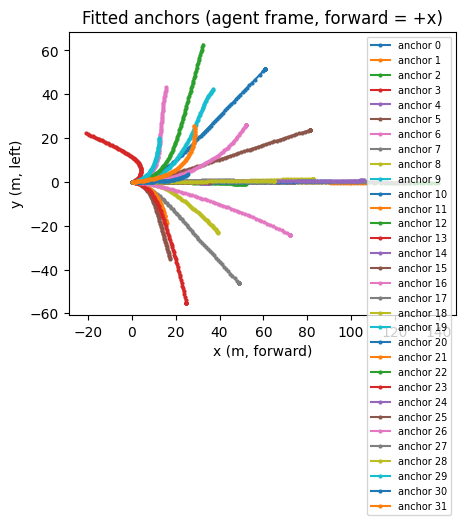

In [ ]:
# Anchor fitting: k-means over training futures in the agent frame. Also stores
# the k-means normalizer and centers (ANCHOR_KF) used for anchor assignment in the loss.


def rotate_points(points, angle):
    """Rotates [..., 2] xy points counterclockwise by `angle` radians."""
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    x, y = points[..., 0], points[..., 1]
    return np.stack([x * cos_a - y * sin_a, x * sin_a + y * cos_a], axis=-1)


def fit_anchor_paths(train_scenes, num_modes=NUM_MODES, future_steps=FUTURE_STEPS,
                     max_plausible_dist=150.0):
    """K-means on trajectory-shape keyframes (2s, 5s, 8s) in the agent frame;
    each anchor is the real training trajectory closest to its cluster
    center (a medoid), so every anchor is a physically observed path.
    Returns (anchor_paths [M, T, 2], kf) where kf holds the normalizer and
    cluster centers used for anchor assignment."""
    endpoints, paths, trajectory_shapes = [], [], []

    for s in train_scenes:
        fv = s["future_valid"].numpy().astype(bool)
        if fv.sum() == 0:
            continue
        valid_indices = np.where(fv)[0]
        last_idx = valid_indices[-1]
        first_v = valid_indices[0]
        traj = s["future_xy"].numpy().copy()

        # forward-fill invalid steps so gaps don't distort the shape
        for t in range(future_steps):
            if not fv[t]:
                traj[t] = traj[t - 1] if t > 0 else traj[first_v]

        endpoints.append(traj[last_idx])
        paths.append(traj)
        idx_2s = min(20, last_idx)
        idx_5s = min(50, last_idx)
        trajectory_shapes.append(np.concatenate([traj[idx_2s], traj[idx_5s], traj[last_idx]]))

    endpoints = np.stack(endpoints)
    paths = np.stack(paths)
    trajectory_shapes = np.stack(trajectory_shapes)

    inlier_mask = np.linalg.norm(endpoints, axis=1) <= max_plausible_dist
    print(f"Fitting anchors on {inlier_mask.sum()} endpoints "
          f"(dropped {(~inlier_mask).sum()} outliers beyond {max_plausible_dist:.0f}m displacement)")

    shapes_min = trajectory_shapes[inlier_mask].min(axis=0)
    shapes_max = trajectory_shapes[inlier_mask].max(axis=0)
    shapes_range = np.clip(shapes_max - shapes_min, 1e-3, None)
    features = (trajectory_shapes - shapes_min) / shapes_range

    kmeans = KMeans(n_clusters=num_modes, n_init="auto", random_state=0).fit(features[inlier_mask])
    labels = kmeans.predict(features)

    anchor_paths = np.zeros((num_modes, future_steps, 2), dtype=np.float32)
    for m in range(num_modes):
        mask = (labels == m) & inlier_mask
        if mask.sum() == 0:
            continue
        cluster_features = features[mask]
        medoid_idx = np.argmin(np.linalg.norm(cluster_features - kmeans.cluster_centers_[m], axis=1))
        anchor_paths[m] = paths[mask][medoid_idx].copy()

    print(f"Anchor cluster sizes: {np.bincount(labels, minlength=num_modes).tolist()}")
    kf = {"centers": torch.tensor(kmeans.cluster_centers_, dtype=torch.float32),
          "min": torch.tensor(shapes_min, dtype=torch.float32),
          "range": torch.tensor(shapes_range, dtype=torch.float32)}
    return torch.from_numpy(anchor_paths), kf, labels


anchor_paths, _kf_cpu, _fit_labels = fit_anchor_paths(train_scenes, max_plausible_dist=150.0)
ANCHOR_KF = {k: v.to(DEVICE) for k, v in _kf_cpu.items()}

# Anchor endpoints, a check that the torch assignment reproduces kmeans.predict,
# and the anchor class share per split.
for m in range(NUM_MODES):
    p = anchor_paths[m].numpy()
    print(f"anchor {m}: endpoint ({p[-1, 0]:6.1f}, {p[-1, 1]:6.1f}) m, "
          f"heading-to-end {math.degrees(math.atan2(p[-1, 1], p[-1, 0])):6.1f} deg")
_chk = [s for s in train_scenes if s["future_valid"].sum() > 0][:5000]
_lab = anchor_labels(torch.stack([s["future_xy"] for s in _chk]).to(DEVICE),
                     torch.stack([s["future_valid"] for s in _chk]).to(DEVICE)).cpu().numpy()
print(f"torch assignment == kmeans.predict on {len(_chk)} train samples: {np.mean(_lab == _fit_labels[:len(_chk)]):.2%}")
for name, split in (("train", train_scenes), ("val", val_scenes)):
    lab = torch.cat([anchor_labels(torch.stack([s["future_xy"] for s in split[i:i + 4096]]).to(DEVICE),
                                   torch.stack([s["future_valid"] for s in split[i:i + 4096]]).to(DEVICE)).cpu()
                     for i in range(0, len(split), 4096)]).numpy()
    print(f"{name} anchor share:", np.round(np.bincount(lab, minlength=NUM_MODES) / len(lab), 3).tolist())

fig, ax = plt.subplots(figsize=(5, 5))
for m in range(NUM_MODES):
    ax.plot(anchor_paths[m, :, 0], anchor_paths[m, :, 1], "-o", markersize=2, label=f"anchor {m}")
ax.set_title("Fitted anchors (agent frame, forward = +x)")
ax.set_xlabel("x (m, forward)")
ax.set_ylabel("y (m, left)")
ax.legend(fontsize=7)
ax.set_aspect("equal")
plt.show()


/tmp/ipykernel_4030/610047860.py:177: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


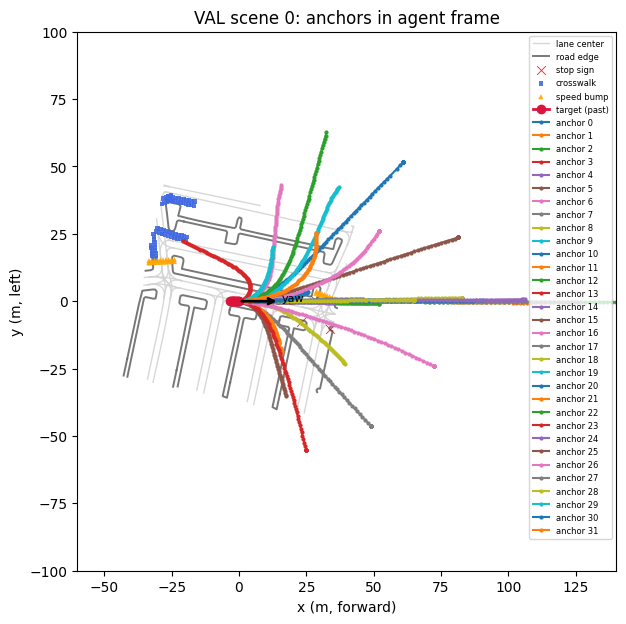

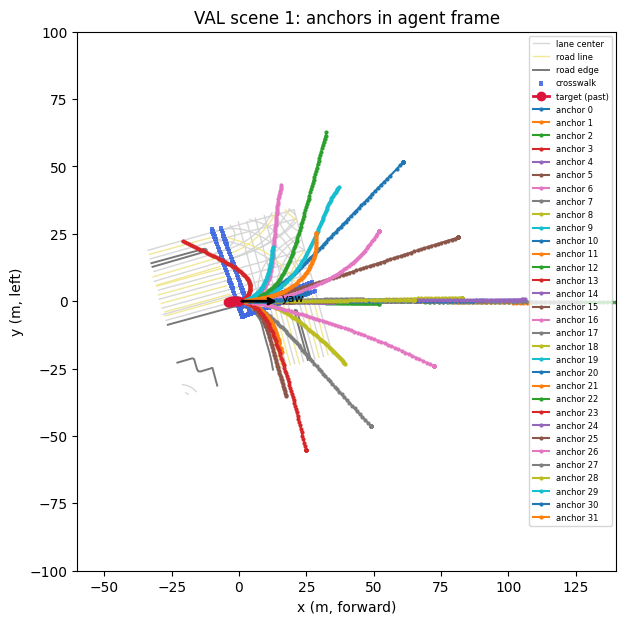

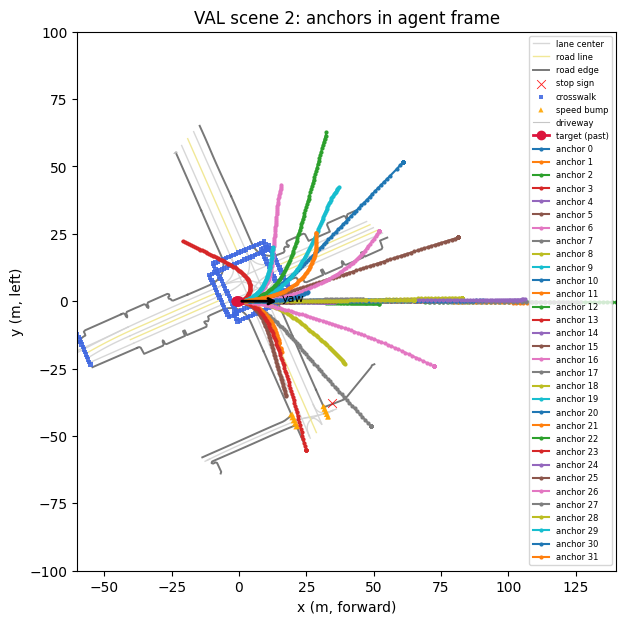

In [ ]:
# Sanity-check anchors in context: a few VAL scenes, with a wide road graph
# moved into the same agent frame the model uses (forward = +x). The model
# itself sees only its own strided, forward-shifted crop (see the
# data-collection coverage printout); this wider map is for viewing only.

VIZ_ROAD_RADIUS_M = 150.0
VIZ_MAX_ROAD_POINTS = 2000
N_ANCHOR_VIZ_SAMPLES = 3

ds_anchor_viz = load_dataset(val_paths).shuffle(500, seed=random.randint(0, 1_000_000))
n_shown = 0
for parsed_scene in ds_anchor_viz.take(50):
    samples = extract_scene_agents(parsed_scene, max_targets=1)
    if not samples:
        continue
    scene = samples[0]
    scene_inputs = build_model_inputs(scene)

    wide_xy_raw, wide_type, wide_id, _ = extract_road_graph(
        parsed_scene, scene["origin"], radius=VIZ_ROAD_RADIUS_M, max_points=VIZ_MAX_ROAD_POINTS, square=True
    )
    wide_xy = to_agent_frame(wide_xy_raw, scene["origin"], scene["yaw0"])

    fig, ax = plt.subplots(figsize=(7, 7))
    draw_road_graph(ax, wide_xy, wide_type, wide_id)

    past_xy = scene_inputs["agent_feats"].numpy()[0, :, :2] * POS_SCALE_M
    past_valid = scene_inputs["agent_valid"].numpy()[0] > 0
    ax.plot(past_xy[past_valid, 0], past_xy[past_valid, 1], "o-", color="crimson",
            linewidth=2, zorder=3, label="target (past)")
    for m in range(NUM_MODES):
        ax.plot(anchor_paths[m, :, 0], anchor_paths[m, :, 1], "-o", markersize=2, label=f"anchor {m}")
    ax.annotate("", xy=(15, 0), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="black", lw=2))
    ax.annotate("yaw", xy=(16, 0), fontsize=8)

    ax.set_xlim(-60, 140)
    ax.set_ylim(-100, 100)
    ax.set_title(f"VAL scene {n_shown}: anchors in agent frame")
    ax.set_xlabel("x (m, forward)")
    ax.set_ylabel("y (m, left)")
    ax.legend(fontsize=6, loc="best")
    ax.set_aspect("equal")
    plt.show()

    n_shown += 1
    if n_shown >= N_ANCHOR_VIZ_SAMPLES:
        break


In [ ]:
# Print the maximum coordinate values and the endpoint displacement for each anchor
for m in range(NUM_MODES):
    path = anchor_paths[m].numpy()
    max_x = np.abs(path[:, 0]).max()
    max_y = np.abs(path[:, 1]).max()
    endpoint_dist = np.linalg.norm(path[-1])
    print(f"Anchor {m}: Max |X| = {max_x:.1f}m, Max |Y| = {max_y:.1f}m, Endpoint Distance = {endpoint_dist:.1f}m")

In [26]:
# Metrics: minADE, minFDE, and miss rate over the best 6 of the 32 modes

OFFROAD_THRESH_M = 3.0
OFFROAD_STEP_STRIDE = 10   # check one point per second of the 8 s horizon
NMS_DIST_M = 2.5           # MTR's endpoint NMS threshold


def select_modes(pred_trajs, pred_confs, k, dist_thresh=NMS_DIST_M):
    """pred_trajs [B, M, T, 2], pred_confs [B, M] -> (idx [B, k], probs [B, k]), most confident first.
    Endpoint NMS: keep a mode unless its final point is within dist_thresh of an already-kept mode's
    final point; if fewer than k survive, fill with the most confident suppressed modes.
    idx[:, 0] is always the single most confident mode."""
    B, M = pred_confs.shape
    k = min(k, M)
    dev = pred_confs.device
    probs = F.softmax(pred_confs, dim=-1)                                              # [B, M]
    order = probs.argsort(dim=1, descending=True)                                      # [B, M]
    ends = torch.gather(pred_trajs[:, :, -1], 1, order.unsqueeze(-1).expand(B, M, 2))  # [B, M, 2], sorted
    close = torch.cdist(ends, ends) < dist_thresh                                      # [B, M, M]
    kept = torch.zeros(B, M, dtype=torch.bool, device=dev)
    n_kept = torch.zeros(B, dtype=torch.long, device=dev)
    for j in range(M):
        suppressed = (close[:, j] & kept).any(dim=1)
        take = ~suppressed & (n_kept < k)
        kept[:, j] = take
        n_kept += take.long()
    rank_key = (~kept).long() * M + torch.arange(M, device=dev)    # kept modes first, each group by confidence
    pos = rank_key.argsort(dim=1)[:, :k]
    idx = torch.gather(order, 1, pos)
    return idx, torch.gather(probs, 1, idx)


def _offroad_flags(traj, traj_valid, lane_xy, lane_mask, reach, center):
    """traj [B, K, S, 2] m, traj_valid [B, K, S] bool, lane_xy [B, R, 2] m, lane_mask [B, R] bool,
    reach [B] m -> [B, K] bool: any checkable point farther than the threshold from every lane point."""
    B, K, S, _ = traj.shape
    d = torch.cdist(traj.reshape(B, K * S, 2), lane_xy)                       # [B, K*S, R]
    d = d.masked_fill(~lane_mask.unsqueeze(1), float("inf")).min(dim=-1).values.view(B, K, S)
    checkable = traj_valid & ((traj - center).norm(dim=-1) <= reach.view(B, 1, 1))
    return ((d > OFFROAD_THRESH_M) & checkable).any(dim=-1)


def compute_metrics(model, scenes, batch_size=128, miss_threshold_m=2.0, return_per_sample=False, top_k=None):
    top_k = EVAL_TOP_K if top_k is None else top_k
    model.eval()
    min_ades, min_fdes, misses, p_top1s, top1_best = [], [], [], [], []
    off_modes, off_top1, off_gt = [], [], []
    center = torch.tensor([ROAD_FORWARD_OFFSET_M, 0.0], device=DEVICE)   # crop center in the agent frame

    with torch.no_grad():
        for i in range(0, len(scenes), batch_size):
            batch = scenes[i : i + batch_size]
            feats, valid, future_xy, future_valid, road_xy, road_type, road_valid, heading = collate_scenes(batch)
            feats, valid = feats.to(DEVICE), valid.to(DEVICE)
            future_xy, future_valid = future_xy.to(DEVICE), future_valid.to(DEVICE)
            road_xy, road_type, road_valid = road_xy.to(DEVICE), road_type.to(DEVICE), road_valid.to(DEVICE)
            heading = heading.to(DEVICE)

            pred_trajs, pred_confs, _ = model(feats, valid, road_xy, road_type, road_valid, heading)  # [B, M, T, 2]
            B, M, T, _ = pred_trajs.shape
            k = min(top_k, M)
            top_idx, top_p = select_modes(pred_trajs, pred_confs, k)       # [B, k], most confident first
            pred_trajs = torch.gather(pred_trajs, 1, top_idx[:, :, None, None].expand(B, k, T, 2))  # [B, k, T, 2]

            dist = (pred_trajs - future_xy.unsqueeze(1)).norm(dim=-1)  # [B, k, T]
            valid_exp = future_valid.unsqueeze(1)                      # [B, 1, T]

            ade_per_mode = (dist * valid_exp).sum(-1) / valid_exp.sum(-1).clamp(min=1.0)  # [B, k]
            min_ade = ade_per_mode.min(dim=1).values

            # future_valid is not always a contiguous prefix, so find the true last-valid step
            time_idx = torch.arange(future_valid.shape[1], device=future_valid.device)
            last_idx = (future_valid * time_idx.unsqueeze(0)).max(dim=1).values.long()
            fde_per_mode = dist[torch.arange(B, device=dist.device), :, last_idx]  # [B, k]
            min_fde = fde_per_mode.min(dim=1).values

            min_ades.extend(min_ade.cpu().tolist())
            min_fdes.extend(min_fde.cpu().tolist())
            misses.extend((min_fde > miss_threshold_m).float().cpu().tolist())
            p_top1s.extend(top_p[:, 0].cpu().tolist())
            top1_best.extend((ade_per_mode.argmin(dim=1) == 0).float().cpu().tolist())

            # Off-road check, vehicle targets with at least one lane-center point in the crop
            map_xy = road_xy[:, :MAX_ROAD_POINTS, :2] * POS_SCALE_M                  # [B, R, 2] m
            map_valid = road_valid[:, :MAX_ROAD_POINTS] > 0
            lane_mask = map_valid & (road_type[:, :MAX_ROAD_POINTS] == 1)            # bucket 1 = lane center
            reach = torch.where(map_valid, (map_xy - center).norm(dim=-1),
                                torch.zeros_like(map_valid, dtype=map_xy.dtype)).max(dim=1).values  # [B]
            eligible = (feats[:, 0, -1, 6] > 0) & lane_mask.any(dim=1)               # vehicles with lanes

            sidx = torch.arange(OFFROAD_STEP_STRIDE - 1, T, OFFROAD_STEP_STRIDE, device=DEVICE)
            pred_s = pred_trajs[:, :, sidx]                                          # [B, k, S, 2]
            pred_off = _offroad_flags(pred_s, torch.ones(pred_s.shape[:3], dtype=torch.bool, device=DEVICE),
                                      map_xy, lane_mask, reach, center)              # [B, k]
            gt_s = future_xy[:, sidx].unsqueeze(1)                                   # [B, 1, S, 2]
            gt_off = _offroad_flags(gt_s, (future_valid[:, sidx] > 0).unsqueeze(1),
                                    map_xy, lane_mask, reach, center)[:, 0]          # [B]

            off_modes.extend(pred_off.float().mean(dim=1)[eligible].cpu().tolist())
            off_top1.extend(pred_off[:, 0].float()[eligible].cpu().tolist())
            off_gt.extend(gt_off.float()[eligible].cpu().tolist())

    model.train()
    result = {
        "minADE": float(np.mean(min_ades)),
        "minFDE": float(np.mean(min_fdes)),
        "miss_rate": float(np.mean(misses)),
        "p_top1": float(np.mean(p_top1s)),
        "top1_is_best": float(np.mean(top1_best)),
        "offroad_rate": float(np.mean(off_modes)) if off_modes else float("nan"),       # all selected modes
        "offroad_top1": float(np.mean(off_top1)) if off_top1 else float("nan"),         # most confident mode
        "gt_offroad_rate": float(np.mean(off_gt)) if off_gt else float("nan"),          # baseline
    }
    if return_per_sample:
        result["per_sample"] = {"minADE": np.array(min_ades), "minFDE": np.array(min_fdes),
                                "miss": np.array(misses)}
    return result


In [ ]:
# Training: time-boxed, AdamW with linear LR warmup then cosine decay to MIN_LR over the
# time budget (so the LR reaches its minimum exactly when time runs out), best-checkpoint
# saving and early stopping on val minADE (top-6 modes), bf16 mixed precision on A100.
# Checkpoints include the anchors, anchor k-means, and run config, and are written to
# Google Drive so they survive a runtime reset. Each run gets its own timestamped folder
# (~55 MB), so a second run never overwrites an earlier run's best checkpoint.

from google.colab import drive
if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")
RUN_NAME = time.strftime("run_%Y%m%d_%H%M")
CKPT_DIR = f"/content/drive/MyDrive/waymo_trajectory/{RUN_NAME}"
os.makedirs(CKPT_DIR, exist_ok=True)

RESUME_FROM_CHECKPOINT = False
PRETRAINED_CHECKPOINT_PATH = f"{CKPT_DIR}/trajectory_transformer_best.pt"   # to resume, point at an earlier run's folder

TRAIN_TIME_BUDGET_SEC = 6 * 60 * 60     # SET THIS to the compute time you actually have left
CHECKPOINT_EVERY_SEC = 5 * 60
CHECKPOINT_PATH = f"{CKPT_DIR}/trajectory_transformer_checkpoint.pt"   # periodic/final
BEST_CHECKPOINT_PATH = f"{CKPT_DIR}/trajectory_transformer_best.pt"    # best val minADE

VAL_EVERY_EPOCHS = 2
EARLY_STOP_PATIENCE_CHECKS = 999  # effectively off: the cosine tail at the end of the budget is often where the best epoch is
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
PEAK_LR = 3e-4
MIN_LR = 1e-6

# bf16 autocast for the heavy matmuls (A100/L4/H100). The output layer, confidence head,
# and loss stay fp32 (see the model cell). Set False to train fully in fp32.
USE_BF16 = DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
torch.backends.cuda.matmul.allow_tf32 = True   # TF32 for remaining fp32 matmuls (Ampere+)
torch.backends.cudnn.allow_tf32 = True

BATCH_SIZE = 32
EVAL_BATCH_SIZE = 128
STEPS_PER_EPOCH_ESTIMATE = max(1, (len(train_scenes) - BATCH_SIZE) // BATCH_SIZE + 1)
WARMUP_EPOCHS = 5
WARMUP_STEPS = WARMUP_EPOCHS * STEPS_PER_EPOCH_ESTIMATE


def lr_schedule(step, elapsed_sec):
    """Linear warmup over WARMUP_STEPS, times a cosine decay from PEAK_LR to MIN_LR
    over the wall-clock budget."""
    warm = min(1.0, (step + 1) / WARMUP_STEPS)
    progress = min(1.0, elapsed_sec / TRAIN_TIME_BUDGET_SEC)
    return warm * (MIN_LR + 0.5 * (PEAK_LR - MIN_LR) * (1.0 + math.cos(math.pi * progress)))


RUN_CONFIG = dict(
    run_name=RUN_NAME,
    assignment_mode=ASSIGNMENT_MODE, soft_assign_temp_m=SOFT_ASSIGN_TEMP_M, label_smoothing=LABEL_SMOOTHING,
    EVAL_TOP_K=EVAL_TOP_K, lr_schedule="warmup + cosine over time budget", use_bf16=USE_BF16,
    MAX_AGENTS=MAX_AGENTS, HIST_STEPS=HIST_STEPS, FUTURE_STEPS=FUTURE_STEPS,
    MAX_ROAD_POINTS=MAX_ROAD_POINTS, MAX_TRAFFIC_LIGHTS=MAX_TRAFFIC_LIGHTS, ROAD_RADIUS_M=ROAD_RADIUS_M,
    ROAD_POINT_STRIDE=ROAD_POINT_STRIDE, ROAD_FORWARD_OFFSET_M=ROAD_FORWARD_OFFSET_M,
    POS_SCALE_M=POS_SCALE_M, VELOCITY_SCALE_MPS=VELOCITY_SCALE_MPS,
    AGENT_FEAT_DIM=AGENT_FEAT_DIM, ROAD_FEAT_DIM=ROAD_FEAT_DIM, NUM_ROAD_BUCKETS=NUM_ROAD_BUCKETS,
    TL_BUCKET_OFFSET=TL_BUCKET_OFFSET, NUM_MODES=NUM_MODES, D_MODEL=D_MODEL, N_HEADS=N_HEADS,
    N_LAYERS=N_LAYERS, DECODER_ROUNDS=DECODER_ROUNDS, FF_DIM=FF_DIM, DECODER_FF_DIM=DECODER_FF_DIM,
    DROPOUT=DROPOUT, LOG_STD_MIN=LOG_STD_MIN, LOG_STD_MAX=LOG_STD_MAX,
    anchor_conditioned_queries=True,   # mode queries add a Linear(2, D_MODEL) embedding of each anchor's endpoint
    split=(f"shards 0-{n_train_shards - 1} train / "
           f"{n_train_shards}-{n_train_shards + n_val_shards - 1} val / "
           f"{n_train_shards + n_val_shards}-{n_shards - 1} test"),
)

model = TrajectoryTransformer(anchor_paths=anchor_paths).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M | bf16 autocast: {USE_BF16}")

start_epoch = 0
best_val_minade = float("inf")
if RESUME_FROM_CHECKPOINT and os.path.exists(PRETRAINED_CHECKPOINT_PATH):
    ckpt = torch.load(PRETRAINED_CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    start_epoch = ckpt["epoch"]
    best_val_minade = ckpt.get("val_minADE", float("inf"))
    print(f"Resuming from checkpoint: epoch {start_epoch}, val minADE {best_val_minade:.2f}")
else:
    print("Fresh random init.")

optimizer = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=WEIGHT_DECAY)


def compute_val_loss(model, scenes, batch_size=EVAL_BATCH_SIZE, use_learned_std=True):
    """Training loss on held-out samples (reported only; selection uses val minADE)."""
    model.eval()
    total, n_batches = 0.0, 0
    with torch.no_grad():
        for i in range(0, len(scenes) - batch_size + 1, batch_size):
            batch = scenes[i : i + batch_size]
            feats, valid, future_xy, future_valid, road_xy, road_type, road_valid, heading = collate_scenes(batch)
            feats, valid = feats.to(DEVICE), valid.to(DEVICE)
            future_xy, future_valid = future_xy.to(DEVICE), future_valid.to(DEVICE)
            road_xy, road_type, road_valid = road_xy.to(DEVICE), road_type.to(DEVICE), road_valid.to(DEVICE)
            heading = heading.to(DEVICE)

            pred_trajs, pred_confs, pred_log_std = model(feats, valid, road_xy, road_type, road_valid, heading)
            loss, _, _ = gaussian_nll_loss(pred_trajs, pred_confs, pred_log_std, future_xy, future_valid,
                                           use_learned_std=use_learned_std)
            total += loss.item()
            n_batches += 1
    model.train()
    return total / max(n_batches, 1)


def _save(path, epoch, avg_loss, extra=None):
    payload = {"model_state_dict": model.state_dict(), "anchor_paths": anchor_paths,
               "anchor_kf": {k: v.detach().cpu() for k, v in ANCHOR_KF.items()},
               "config": RUN_CONFIG, "epoch": epoch, "loss": avg_loss}
    if extra:
        payload.update(extra)
    torch.save(payload, path)


start_time = time.time()
last_checkpoint_time = start_time
epoch = start_epoch
global_step = 0
val_no_improve = 0
stopped_early = False
interrupted = False
avg_loss = float("nan")

print(f"Training for up to {TRAIN_TIME_BUDGET_SEC / 3600:.1f} h on {len(train_scenes)} samples "
      f"(val {len(val_scenes)} samples every {VAL_EVERY_EPOCHS} epochs; test {len(test_scenes)} held out), "
      f"LR warmup {WARMUP_STEPS} steps to {PEAK_LR:.1e} then cosine to {MIN_LR:.0e} over the budget, "
      f"sigma=1 warmup for {NLL_WARMUP_EPOCHS} epochs, "
      f"modes={NUM_MODES} (eval top-{EVAL_TOP_K}), assignment={ASSIGNMENT_MODE} "
      f"(T={SOFT_ASSIGN_TEMP_M} m), label_smoothing={LABEL_SMOOTHING}, checkpoints -> {CKPT_DIR}")

try:
    while time.time() - start_time < TRAIN_TIME_BUDGET_SEC:
        epoch += 1
        use_learned_std = epoch > NLL_WARMUP_EPOCHS
        random.shuffle(train_scenes)
        epoch_loss, epoch_nll, epoch_conf, epoch_grad_norm, n_batches = 0.0, 0.0, 0.0, 0.0, 0
        epoch_w_top1, epoch_eff_modes, epoch_p_top1 = 0.0, 0.0, 0.0

        for i in range(0, len(train_scenes) - BATCH_SIZE + 1, BATCH_SIZE):
            batch = train_scenes[i : i + BATCH_SIZE]
            feats, valid, future_xy, future_valid, road_xy, road_type, road_valid, heading = collate_scenes(batch)
            feats, valid = feats.to(DEVICE), valid.to(DEVICE)
            future_xy, future_valid = future_xy.to(DEVICE), future_valid.to(DEVICE)
            road_xy, road_type, road_valid = road_xy.to(DEVICE), road_type.to(DEVICE), road_valid.to(DEVICE)
            heading = heading.to(DEVICE)

            lr = lr_schedule(global_step, time.time() - start_time)
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr

            with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=USE_BF16):
                pred_trajs, pred_confs, pred_log_std = model(feats, valid, road_xy, road_type, road_valid, heading)
            # model outputs are already fp32; the loss runs outside autocast
            loss, nll_loss, conf_loss = gaussian_nll_loss(pred_trajs, pred_confs, pred_log_std, future_xy,
                                                          future_valid, use_learned_std=use_learned_std)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss at epoch {epoch}, step {global_step}: "
                                   f"set USE_BF16 = False and restart.")

            optimizer.zero_grad()
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
            global_step += 1

            epoch_loss += loss.item()
            epoch_nll += nll_loss
            epoch_conf += conf_loss
            epoch_grad_norm += float(grad_norm)
            epoch_w_top1 += LOSS_STATS["w_top1"]
            epoch_eff_modes += LOSS_STATS["eff_modes"]
            epoch_p_top1 += LOSS_STATS["p_top1"]
            n_batches += 1

        nb = max(n_batches, 1)
        avg_loss = epoch_loss / nb
        avg_nll = epoch_nll / nb
        avg_conf = epoch_conf / nb
        avg_grad_norm = epoch_grad_norm / nb
        elapsed_min = (time.time() - start_time) / 60
        current_lr = optimizer.param_groups[0]["lr"]
        warm_tag = " [warmup: sigma=1]" if not use_learned_std else ""
        line = (f"Epoch {epoch} ({elapsed_min:.1f} min) - loss: {avg_loss:.4f} - nll: {avg_nll:.4f} "
                f"- conf: {avg_conf:.4f} - grad_norm: {avg_grad_norm:.3f} "
                f"- w_top1: {epoch_w_top1 / nb:.2f} - eff_modes: {epoch_eff_modes / nb:.1f} "
                f"- p_top1: {epoch_p_top1 / nb:.2f}")

        now = time.time()
        if now - last_checkpoint_time >= CHECKPOINT_EVERY_SEC:
            _save(CHECKPOINT_PATH, epoch, avg_loss)
            last_checkpoint_time = now

        if epoch % VAL_EVERY_EPOCHS == 0:
            val_m = compute_metrics(model, val_scenes, batch_size=EVAL_BATCH_SIZE)
            val_loss = compute_val_loss(model, val_scenes, use_learned_std=use_learned_std)
            score = val_m["minADE"]

            improved = score < best_val_minade
            if improved:
                best_val_minade = score
                val_no_improve = 0
                _save(BEST_CHECKPOINT_PATH, epoch, avg_loss, {
                    "val_minADE": val_m["minADE"], "val_minFDE": val_m["minFDE"],
                    "val_miss_rate": val_m["miss_rate"], "val_loss": val_loss,
                    "val_p_top1": val_m["p_top1"], "val_top1_is_best": val_m["top1_is_best"],
                    "val_offroad_rate": val_m["offroad_rate"], "val_gt_offroad_rate": val_m["gt_offroad_rate"],
                })
            else:
                val_no_improve += 1

            print(f"{line} | val minADE {val_m['minADE']:.2f} minFDE {val_m['minFDE']:.2f} "
                  f"MR {val_m['miss_rate']:.1%} p_top1 {val_m['p_top1']:.2f} "
                  f"top1_is_best {val_m['top1_is_best']:.1%} "
                  f"off-road {val_m['offroad_rate']:.1%} (GT {val_m['gt_offroad_rate']:.1%}) "
                  f"val_loss {val_loss:.4f}{' (best)' if improved else ''} "
                  f"- lr: {current_lr:.2e}{warm_tag}")

            if val_no_improve >= EARLY_STOP_PATIENCE_CHECKS:
                print(f"\nEarly stopping: val minADE hasn't improved in {val_no_improve} checks "
                      f"({val_no_improve * VAL_EVERY_EPOCHS} epochs). Best: {best_val_minade:.2f}m")
                stopped_early = True
                break
        else:
            print(f"{line} - lr: {current_lr:.2e}{warm_tag}")
except KeyboardInterrupt:
    interrupted = True
    print("\nInterrupted: saving final state.")

_save(CHECKPOINT_PATH, epoch, avg_loss)

total_min = (time.time() - start_time) / 60
status = " (stopped early)" if stopped_early else " (interrupted)" if interrupted else ""
print(f"\nDone: {epoch - start_epoch} epochs in {total_min:.1f} min, final train loss {avg_loss:.4f}, "
      f"best val minADE {best_val_minade:.2f}m{status}")
print(f"Best checkpoint (by val minADE): {BEST_CHECKPOINT_PATH}")


In [27]:
# Load the best checkpoint (chosen by val minADE) before evaluating or plotting.
# Self-contained: it builds the model and takes the anchors from the checkpoint itself,
# so the training cell doesn't need to have run. It uses the checkpoint's own anchors,
# since the model's offsets only make sense relative to the anchors it trained on.

BEST_CHECKPOINT_PATH = "/content/drive/MyDrive/waymo_trajectory/run_20260929_1110/trajectory_transformer_best.pt"

ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)

# Anchors from the payload (fall back to the refitted ones if absent for any reason)
ckpt_anchors = ckpt.get("anchor_paths")
if ckpt_anchors is None:
    ckpt_anchors = anchor_paths
    print("WARNING: checkpoint has no anchor_paths; using refitted anchors.")

model = TrajectoryTransformer(anchor_paths=ckpt_anchors).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.set_anchors(ckpt_anchors.to(DEVICE))
model.to(DEVICE)

# Restore ANCHOR_KF from the payload too, so anchor-based assignment (if used) matches training.
if ckpt.get("anchor_kf") is not None:
    ANCHOR_KF = {k: v.to(DEVICE) for k, v in ckpt["anchor_kf"].items()}

# Sanity: does the checkpoint's anchor bank match the anchors just refitted this session?
try:
    _match = torch.allclose(ckpt_anchors.cpu(), anchor_paths.cpu(), atol=1e-4)
    _maxdiff = (ckpt_anchors.cpu() - anchor_paths.cpu()).abs().max().item()
    print(f"Refit anchors match checkpoint anchors: {_match} (max abs diff {_maxdiff:.4g})")
except Exception as e:
    print(f"(anchor comparison skipped: {e})")

print(f"Loaded best checkpoint: epoch {ckpt['epoch']}, train loss {ckpt['loss']:.4f}, "
      f"val minADE {ckpt.get('val_minADE', float('nan')):.2f}m, val minFDE {ckpt.get('val_minFDE', float('nan')):.2f}m, "
      f"val_loss {ckpt.get('val_loss', float('nan')):.4f}")


Refit anchors match checkpoint anchors: False (max abs diff 127.2)
Loaded best checkpoint: epoch 84, train loss 2.8294, val minADE 1.63m, val minFDE 3.92m, val_loss 3.6711


/tmp/ipykernel_4030/3992996098.py:79: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


In [28]:
# Final evaluation. Val was used to pick the checkpoint, so the number to report is TEST:
# held-out shards never seen in training, anchor fitting, or checkpoint selection.
# Broken down by agent type, since vehicles, pedestrians, and cyclists behave very differently.

TYPE_SLOT_NAMES = ["vehicle", "pedestrian", "cyclist"]

def _target_type(s):
    onehot = s["agent_feats"][0, -1, 6:9].numpy()
    return int(np.argmax(onehot)) if onehot.sum() > 0 else -1

for name, scenes in [("VAL (used for selection)", val_scenes), ("TEST (held out)", test_scenes)]:
    m = compute_metrics(model, scenes, return_per_sample=True)
    print(f"{name}: {len(scenes)} samples | minADE {m['minADE']:.2f} m | minFDE {m['minFDE']:.2f} m "
          f"| miss rate {m['miss_rate']:.1%} (2.0 m at 8s) | top-{EVAL_TOP_K} of {NUM_MODES} modes")
    print(f"    calibration: mean top-1 confidence {m['p_top1']:.2f}, "
          f"top-1 mode is the best mode {m['top1_is_best']:.1%}")
    print(f"    off-road (vehicles, >{OFFROAD_THRESH_M:.0f} m from lane centers): top-{EVAL_TOP_K} modes "
          f"{m['offroad_rate']:.1%}, top-1 mode {m['offroad_top1']:.1%}, ground truth baseline {m['gt_offroad_rate']:.1%}")
    types = np.array([_target_type(s) for s in scenes])
    ps = m["per_sample"]
    for t, tn in enumerate(TYPE_SLOT_NAMES):
        mask = types == t
        if mask.sum():
            print(f"    {tn:<10} n={mask.sum():>6}  minADE {ps['minADE'][mask].mean():.2f}  "
                  f"minFDE {ps['minFDE'][mask].mean():.2f}  MR {ps['miss'][mask].mean():.1%}")


VAL (used for selection): 13637 samples | minADE 1.63 m | minFDE 3.93 m | miss rate 47.4% (2.0 m at 8s) | top-6 of 32 modes
    calibration: mean top-1 confidence 0.17, top-1 mode is the best mode 21.3%
    off-road (vehicles, >3 m from lane centers): top-6 modes 16.6%, top-1 mode 15.9%, ground truth baseline 13.3%
    vehicle    n= 13188  minADE 1.65  minFDE 3.99  MR 48.0%
    pedestrian n=   365  minADE 0.74  minFDE 1.64  MR 24.4%
    cyclist    n=    84  minADE 1.87  minFDE 4.43  MR 46.4%
TEST (held out): 13832 samples | minADE 1.60 m | minFDE 3.86 m | miss rate 47.4% (2.0 m at 8s) | top-6 of 32 modes
    calibration: mean top-1 confidence 0.17, top-1 mode is the best mode 21.7%
    off-road (vehicles, >3 m from lane centers): top-6 modes 16.5%, top-1 mode 15.1%, ground truth baseline 12.8%
    vehicle    n= 13409  minADE 1.63  minFDE 3.93  MR 48.1%
    pedestrian n=   356  minADE 0.70  minFDE 1.60  MR 20.8%
    cyclist    n=    67  minADE 1.36  minFDE 3.06  MR 41.8%


Saving plots to /content/drive/MyDrive/waymo_trajectory/run_20260929_1110/plots
1455 TEST candidates, 664 turn-like


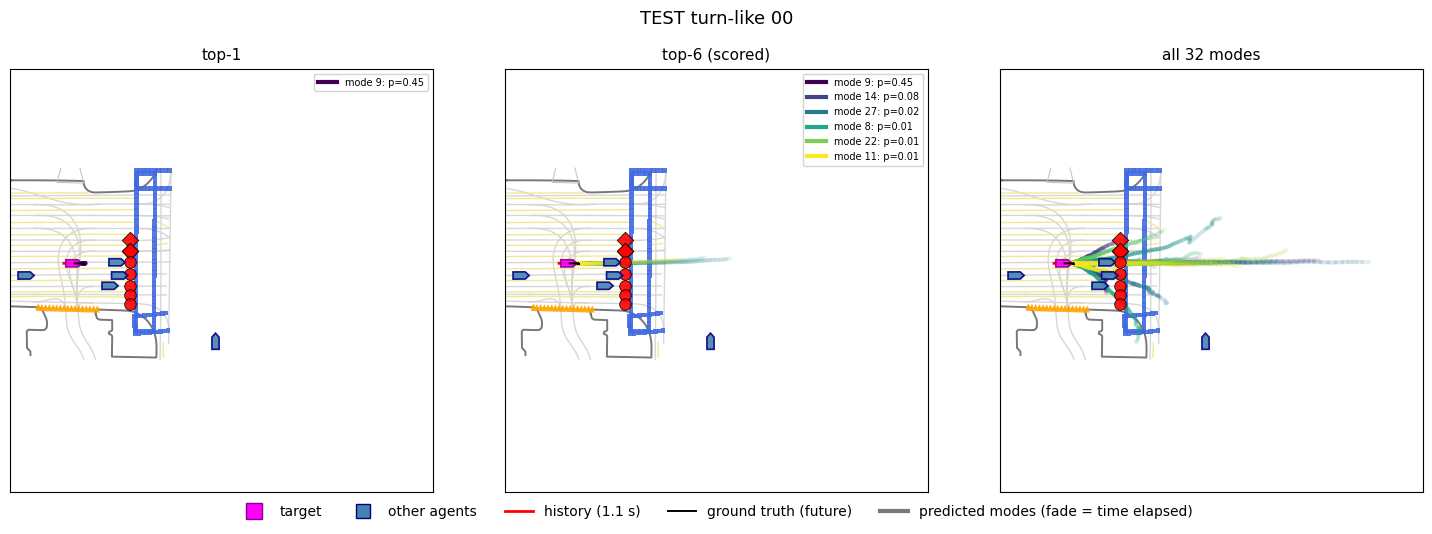

/tmp/ipykernel_4030/610047860.py:177: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


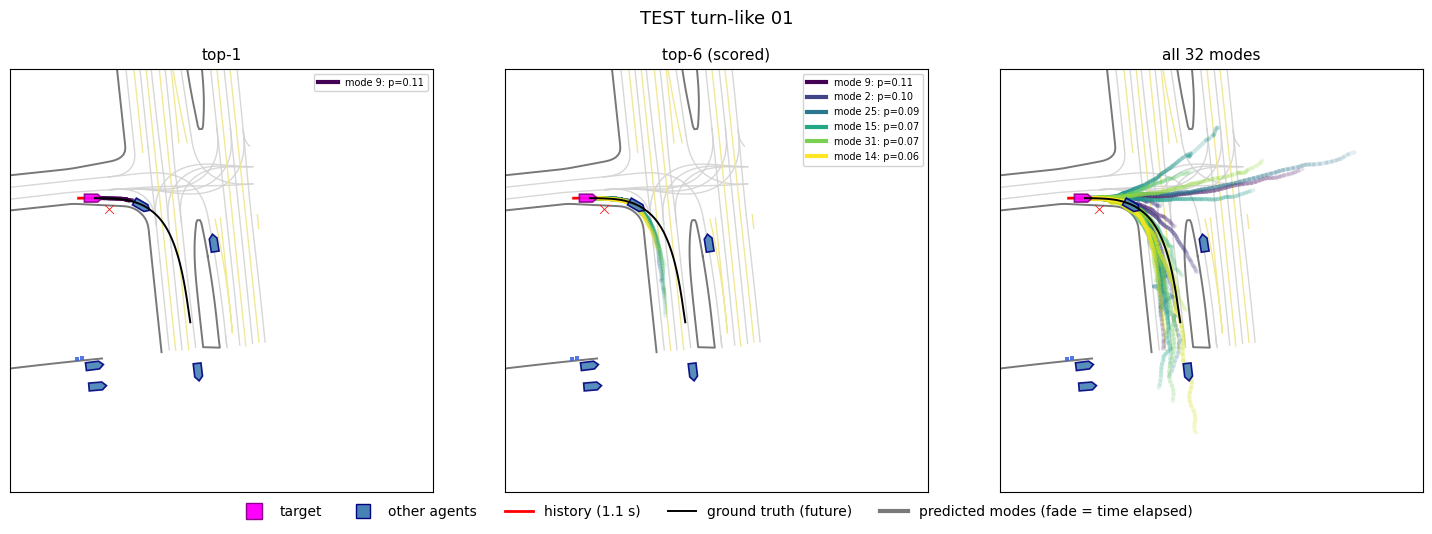

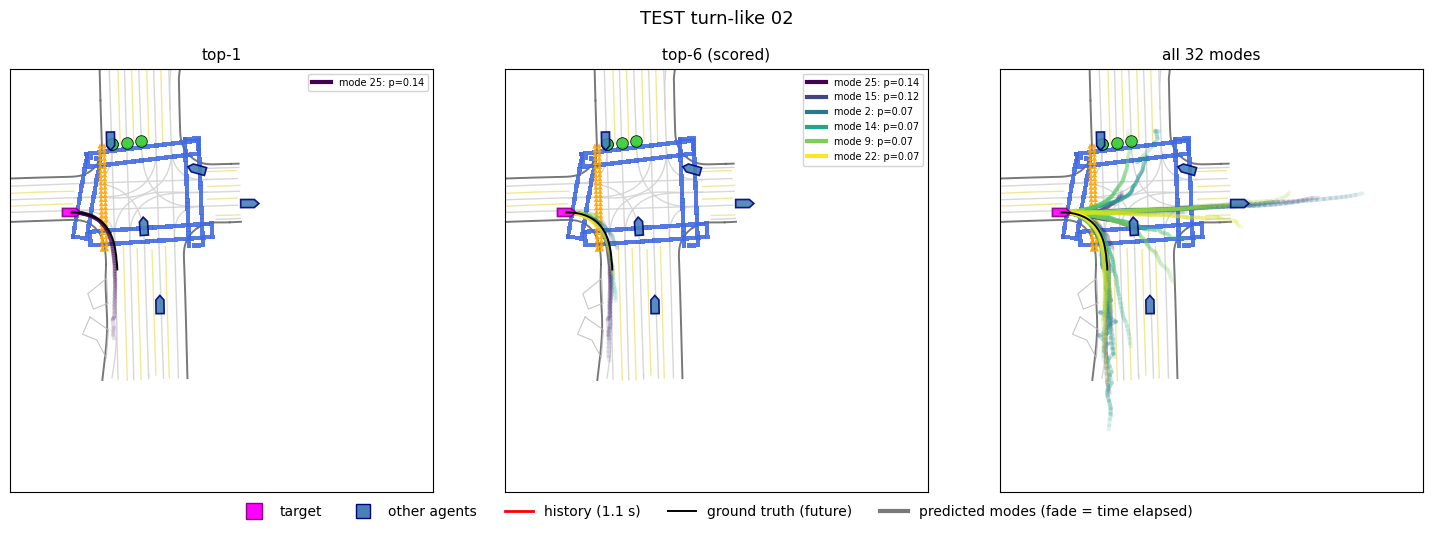

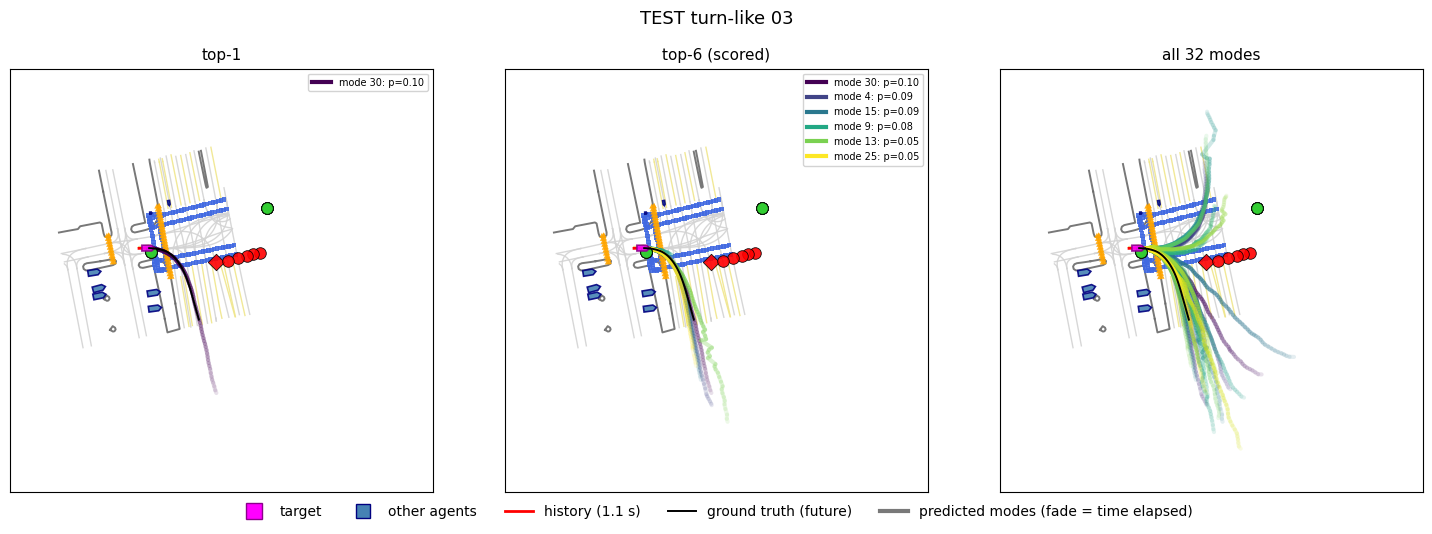

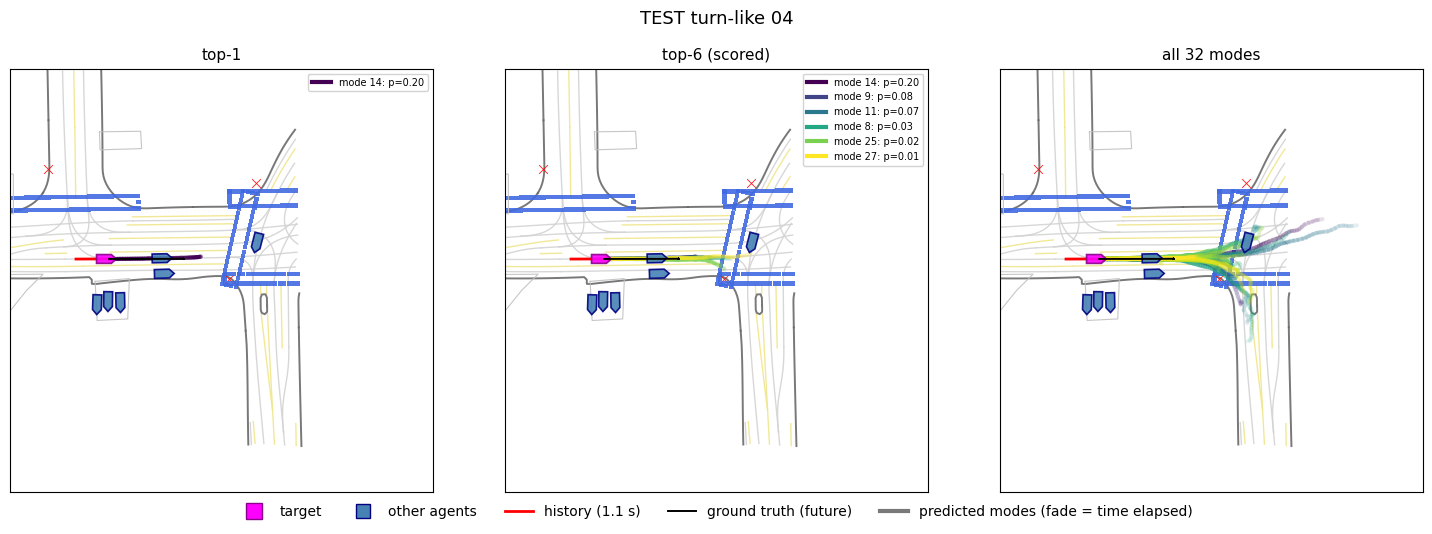

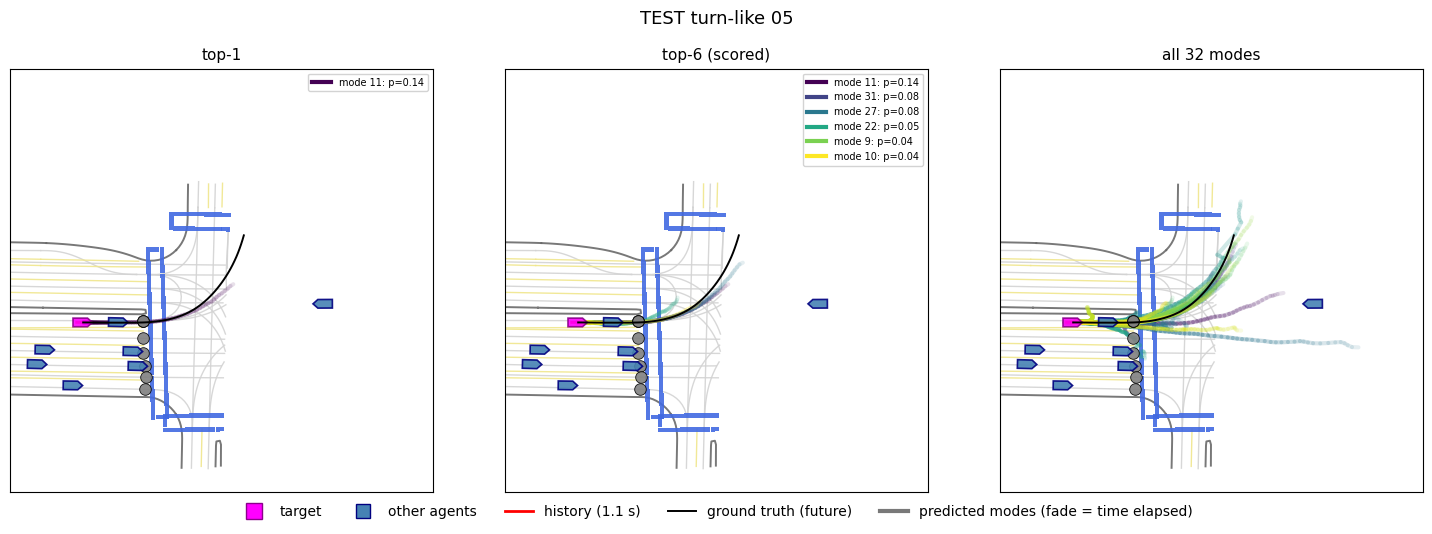

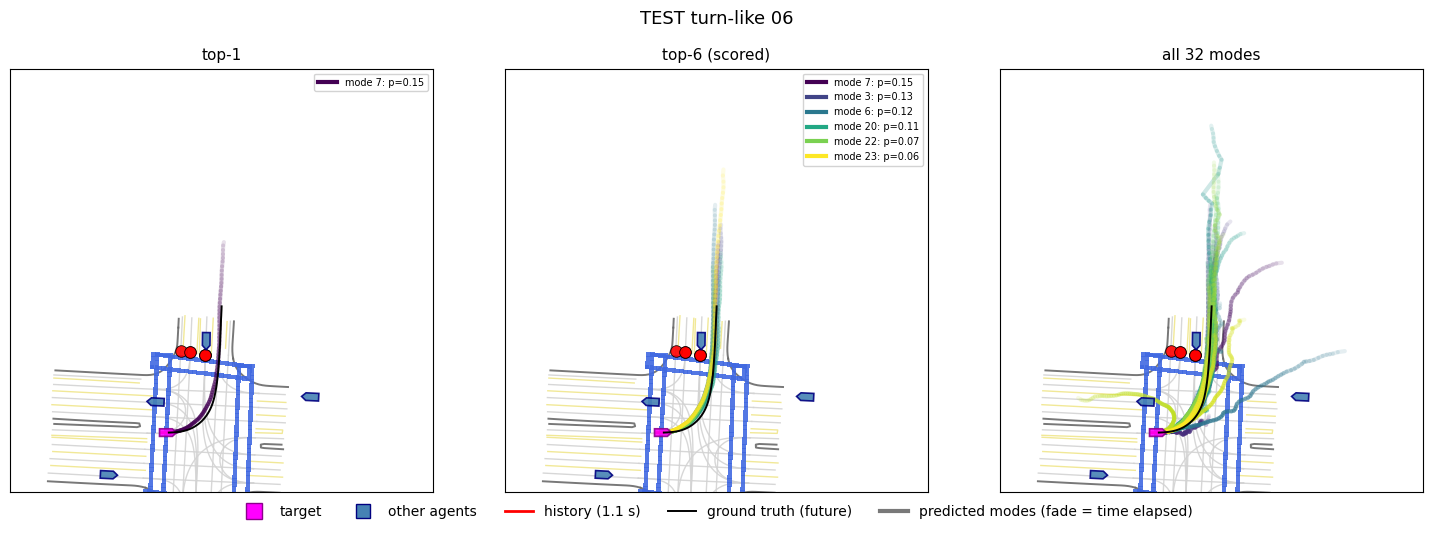

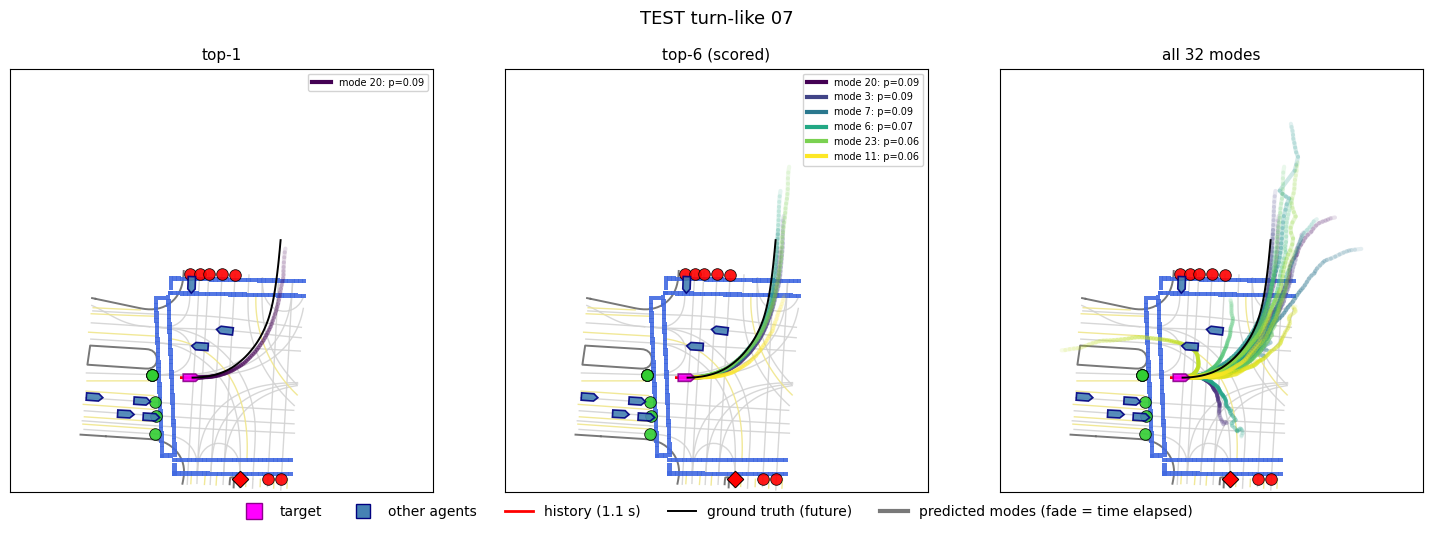

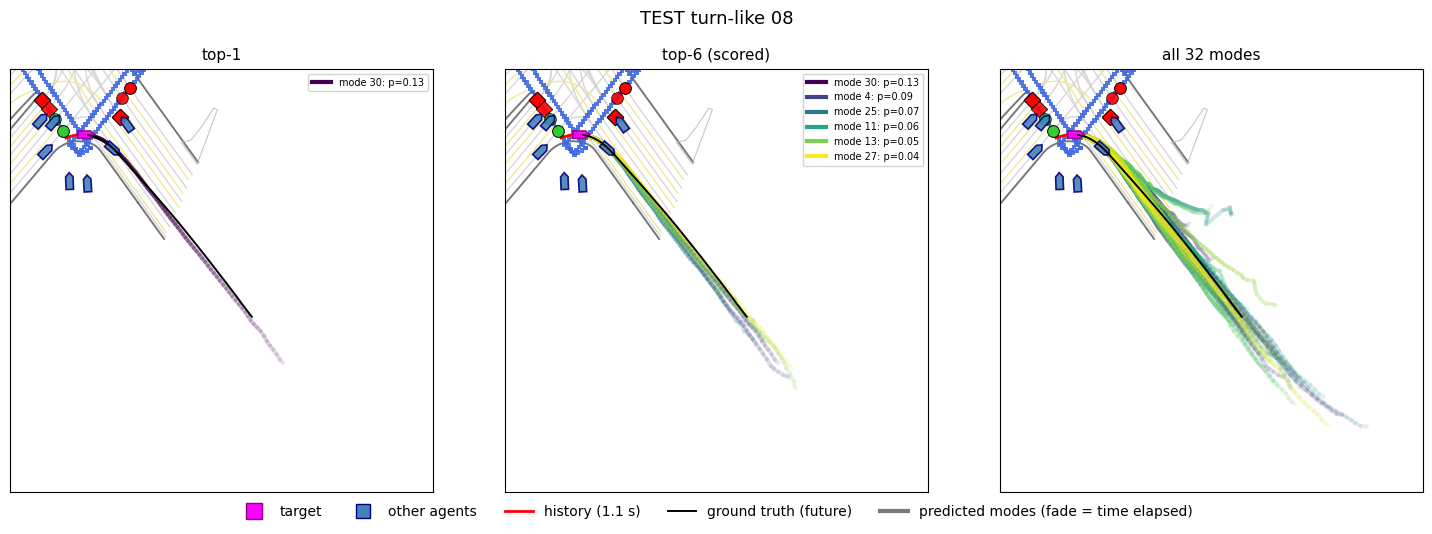

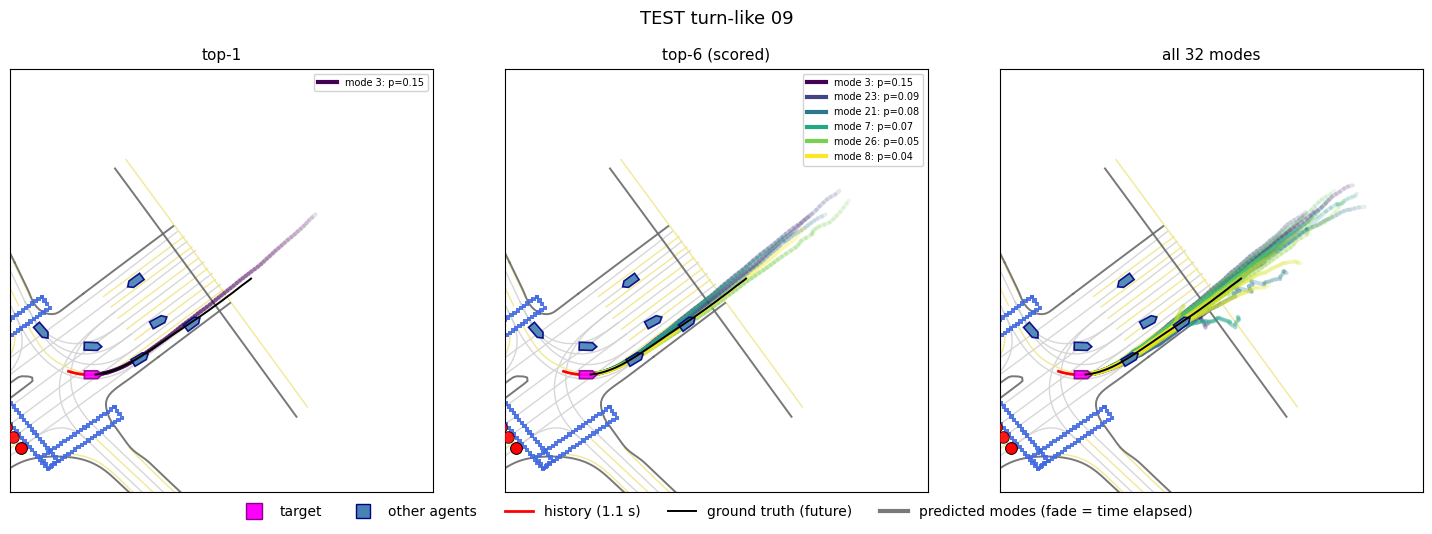

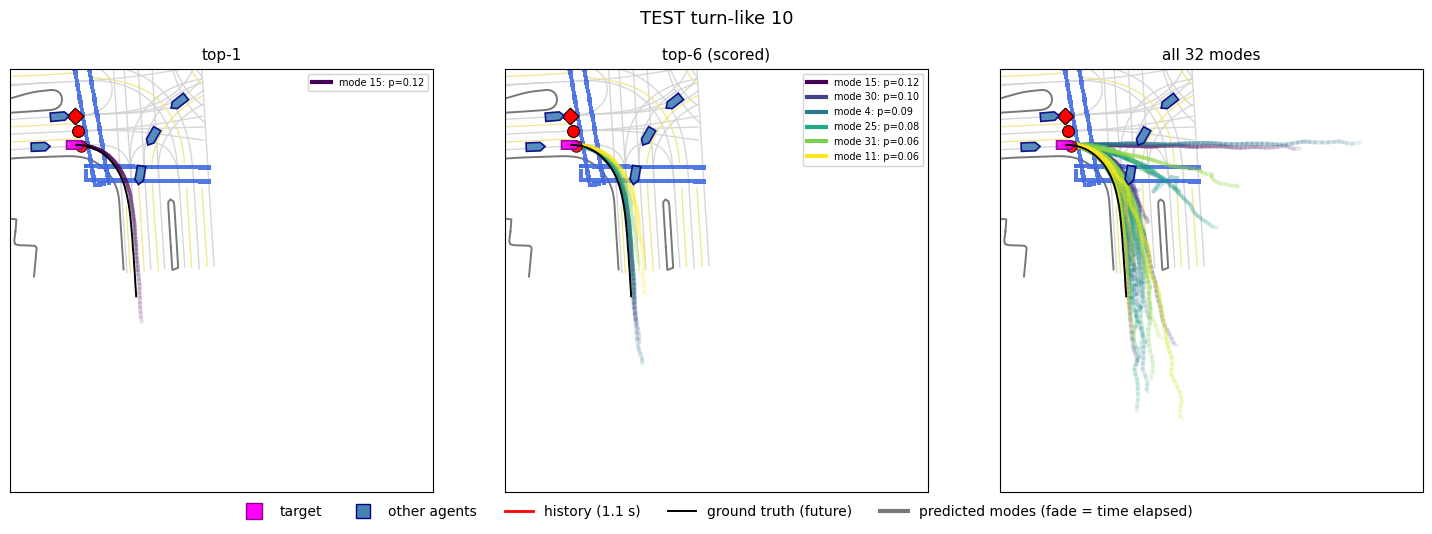

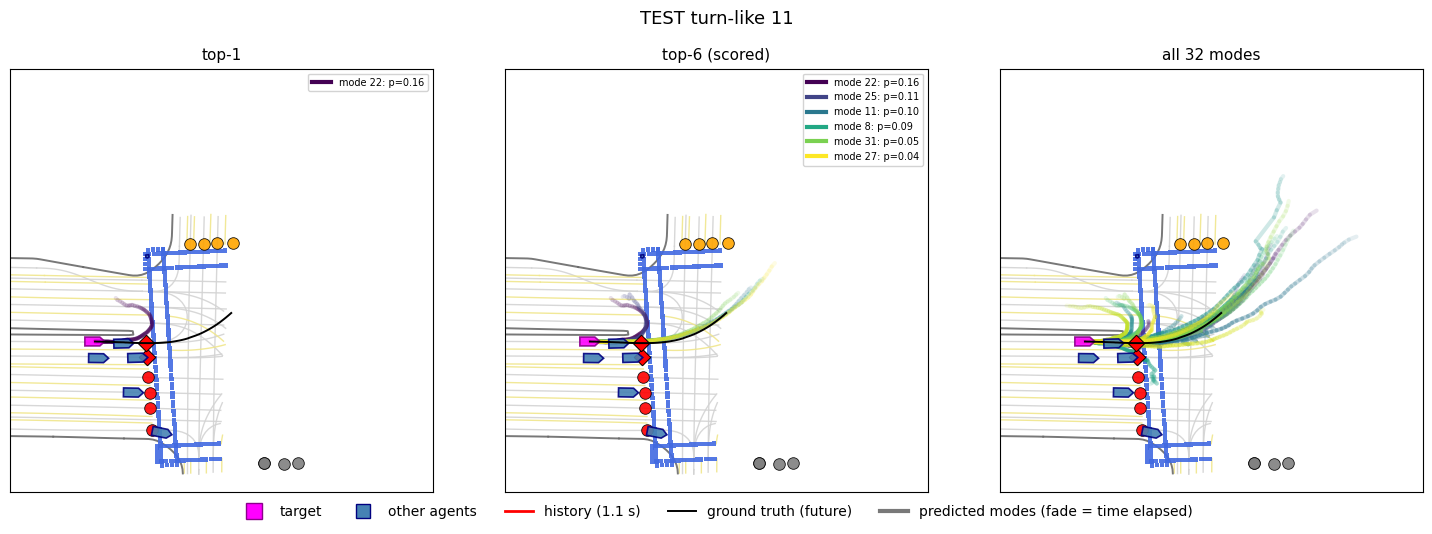

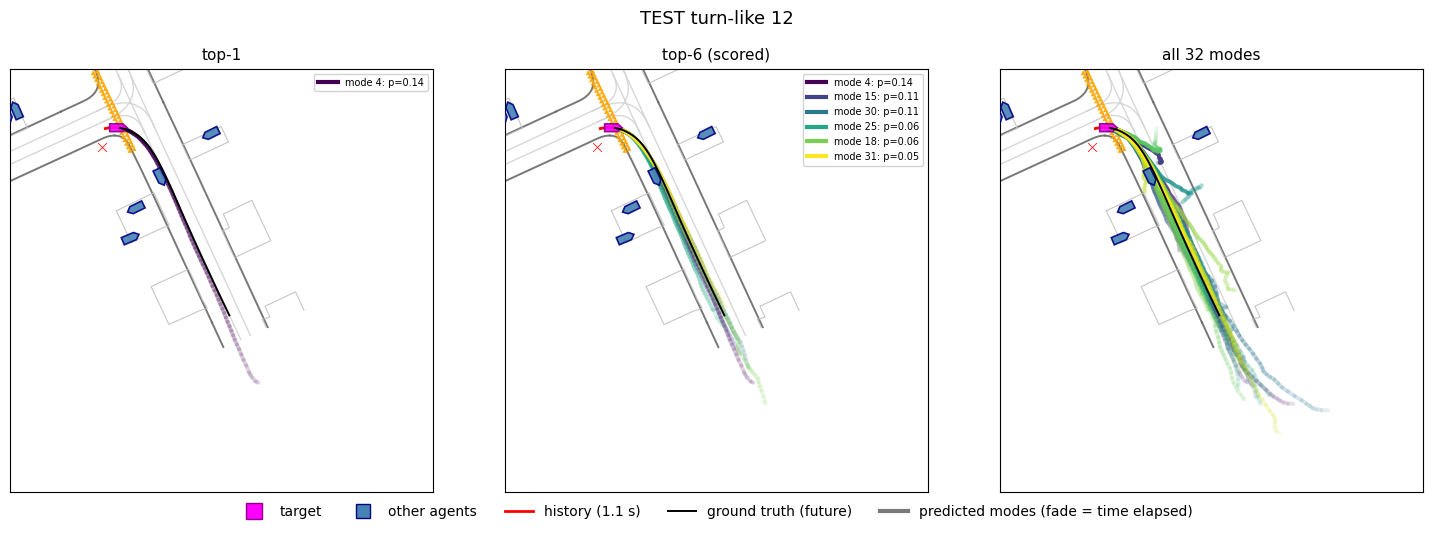

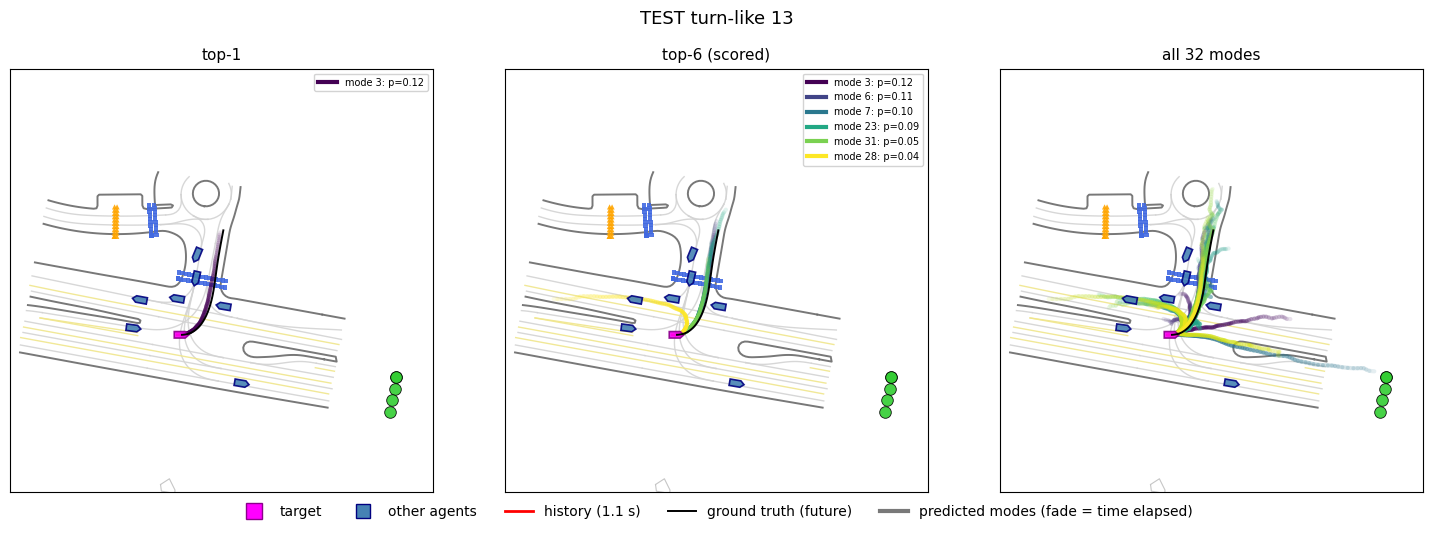

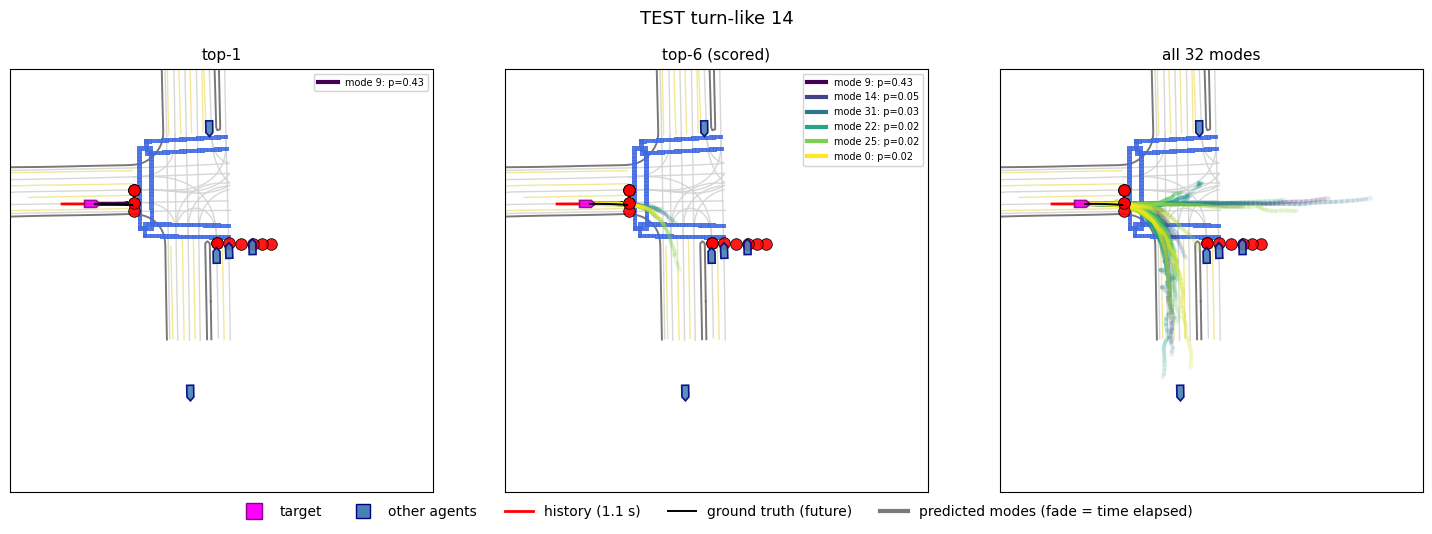

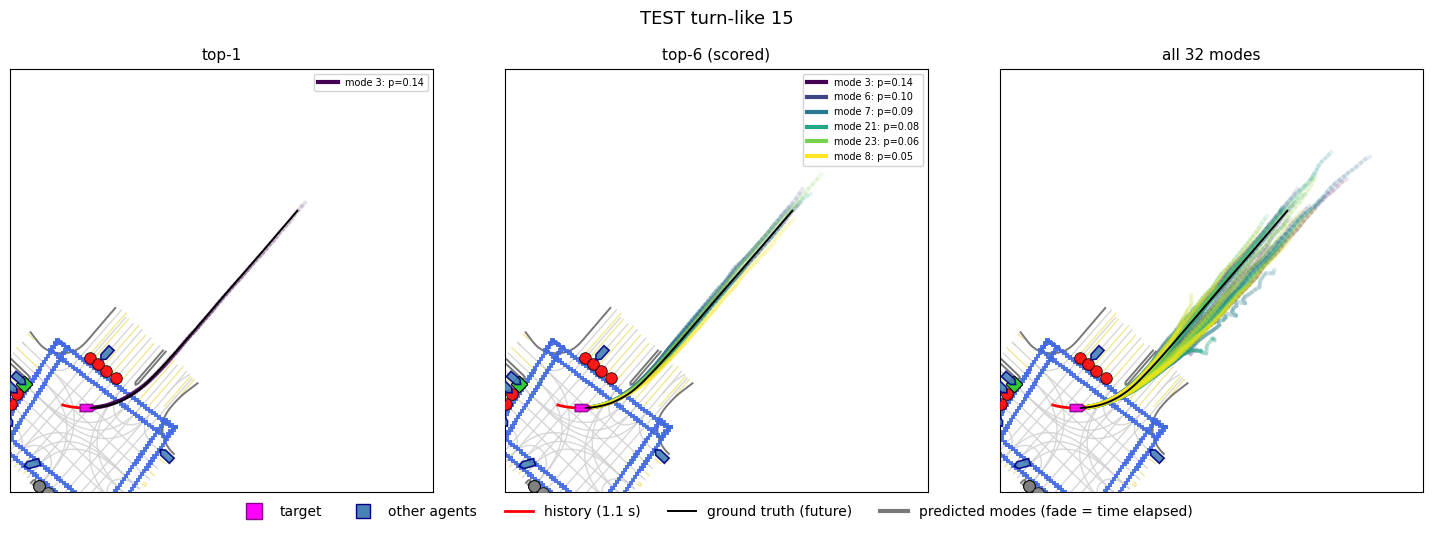

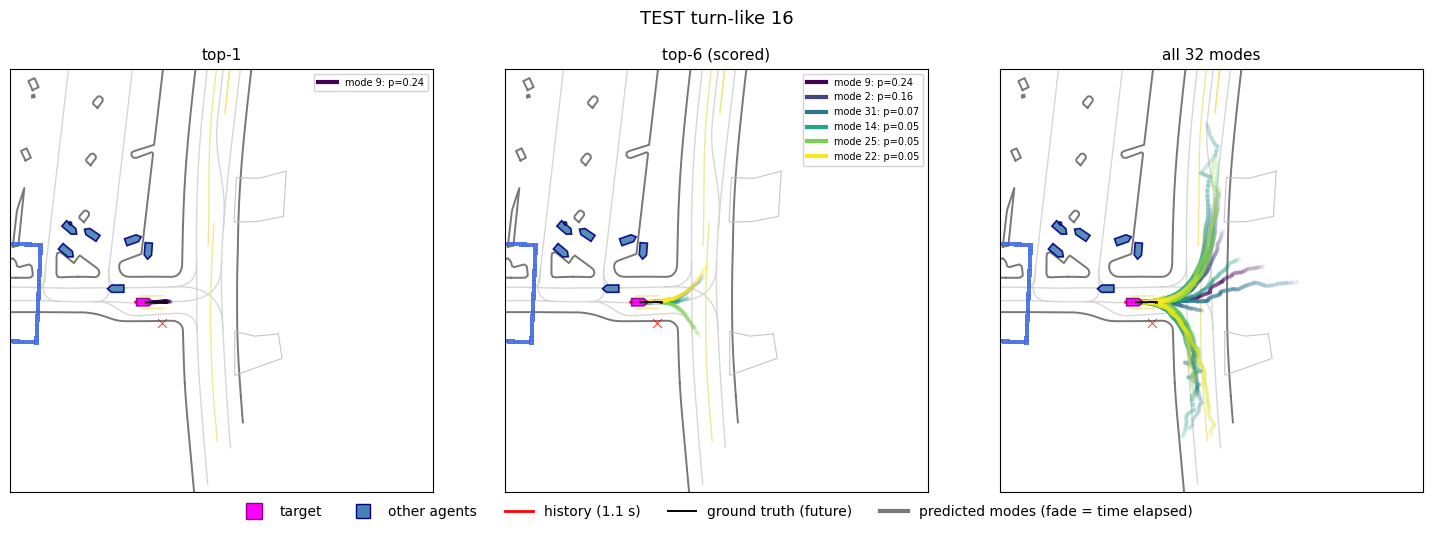

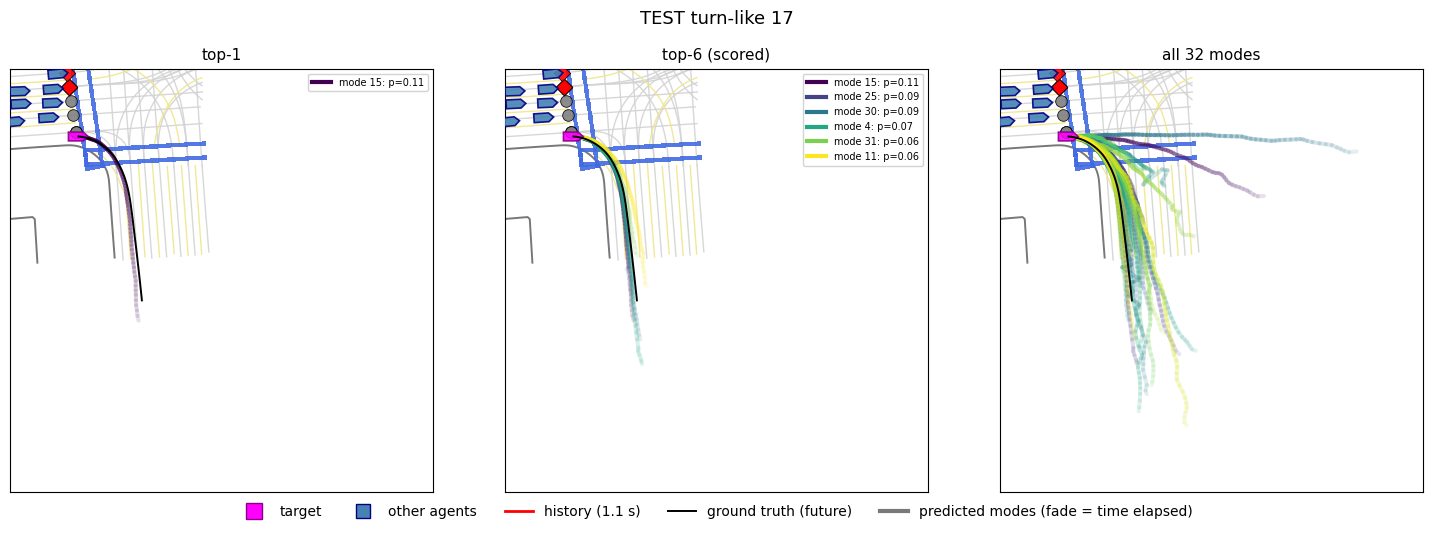

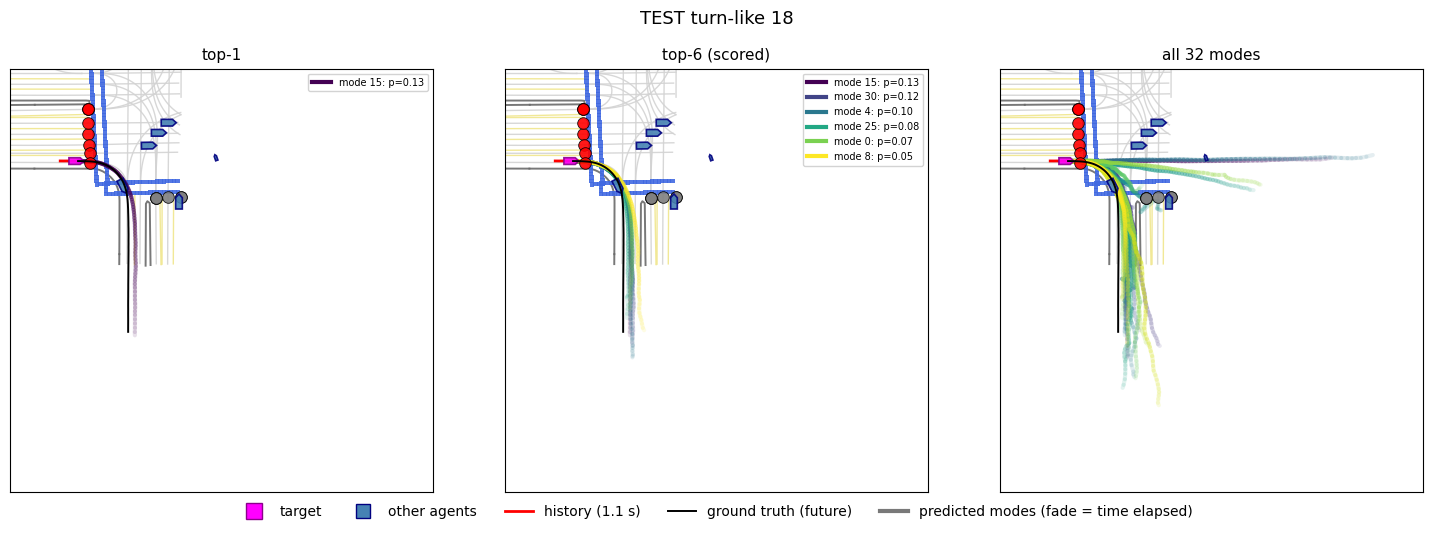

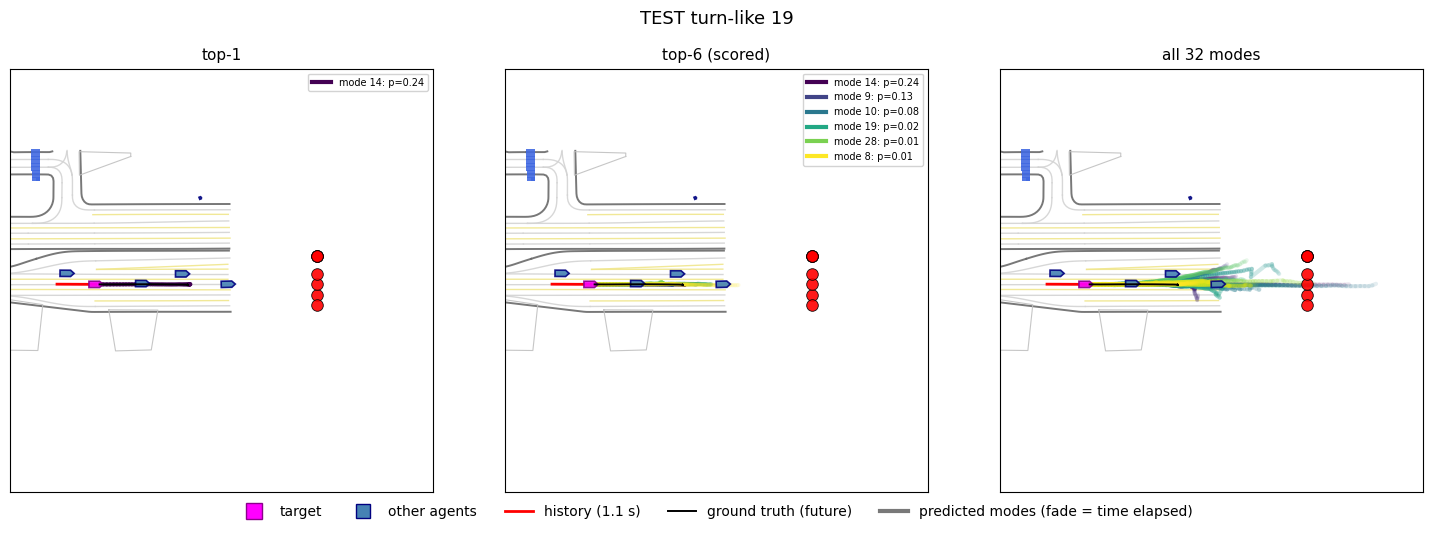

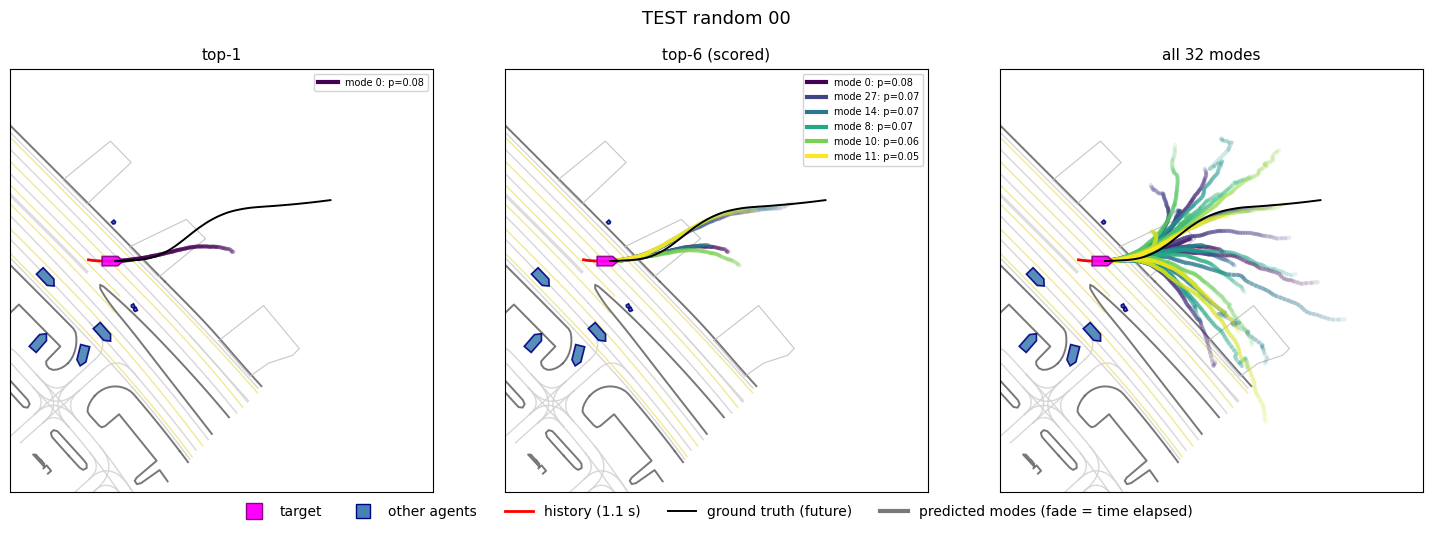

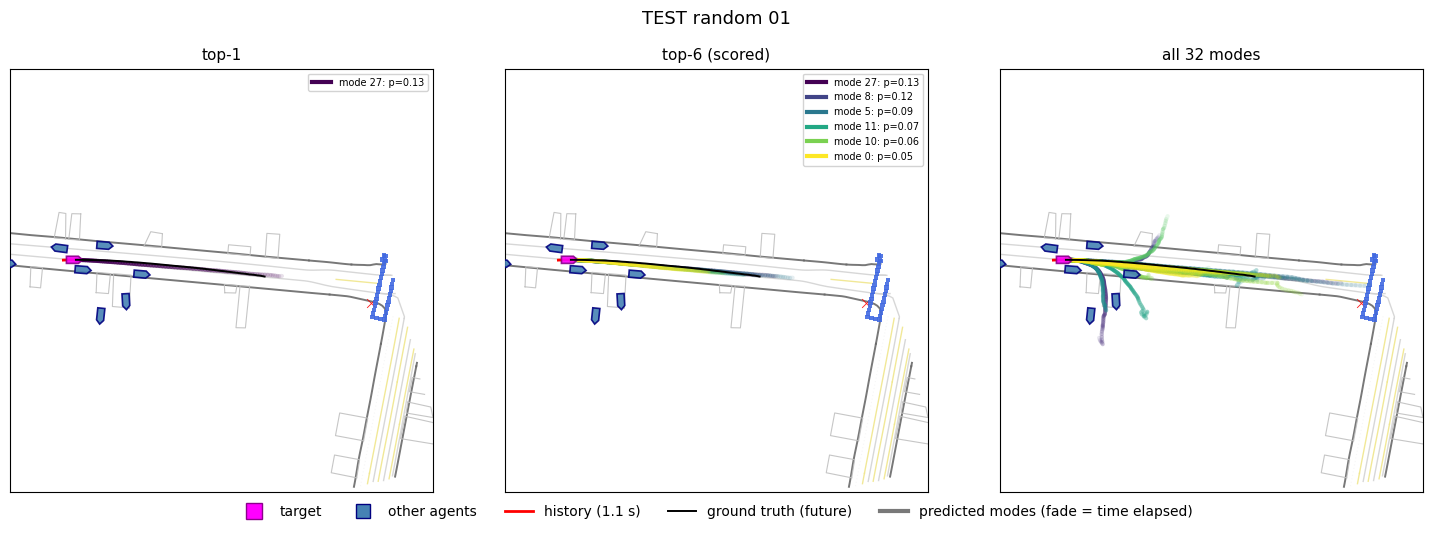

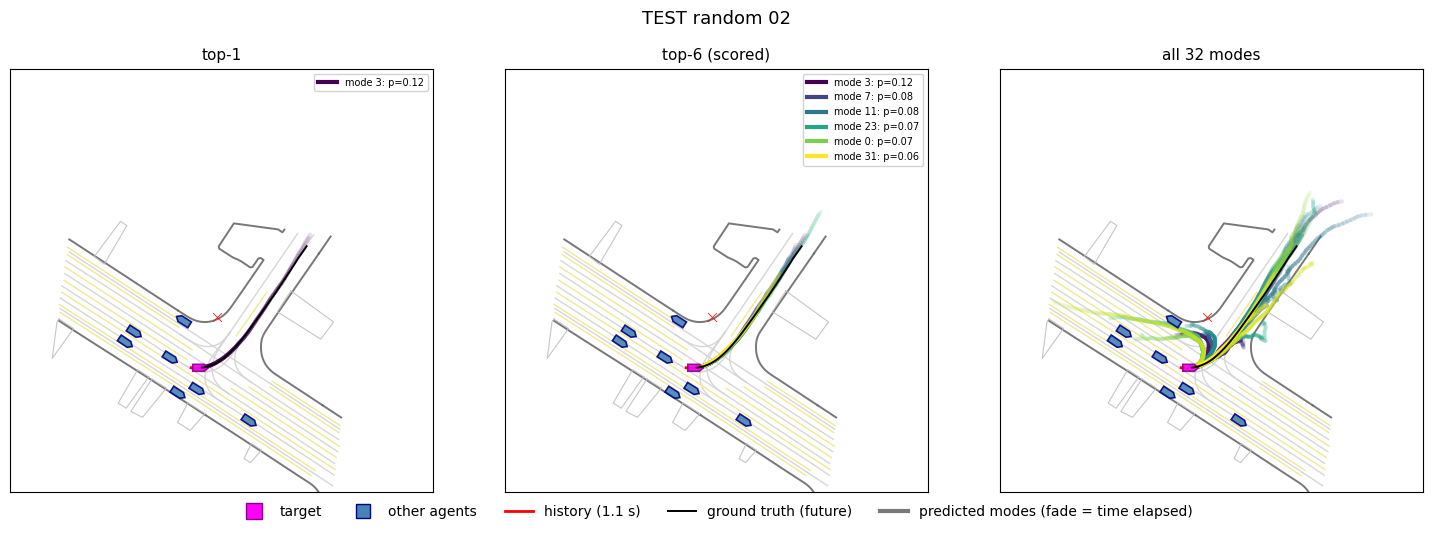

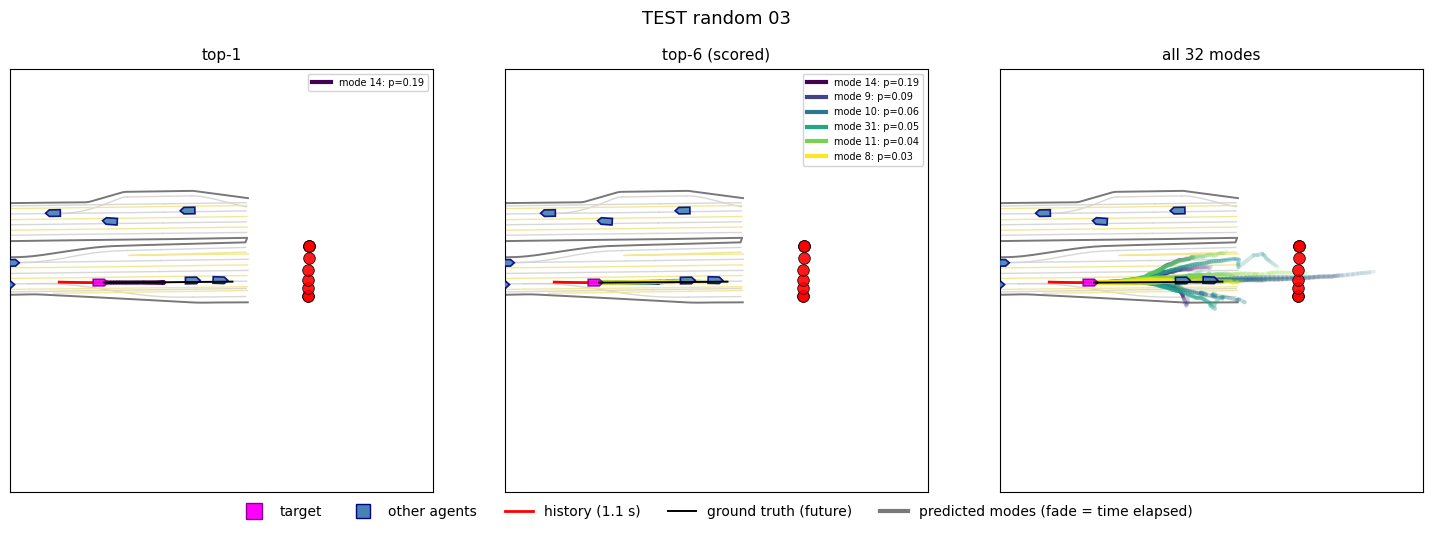

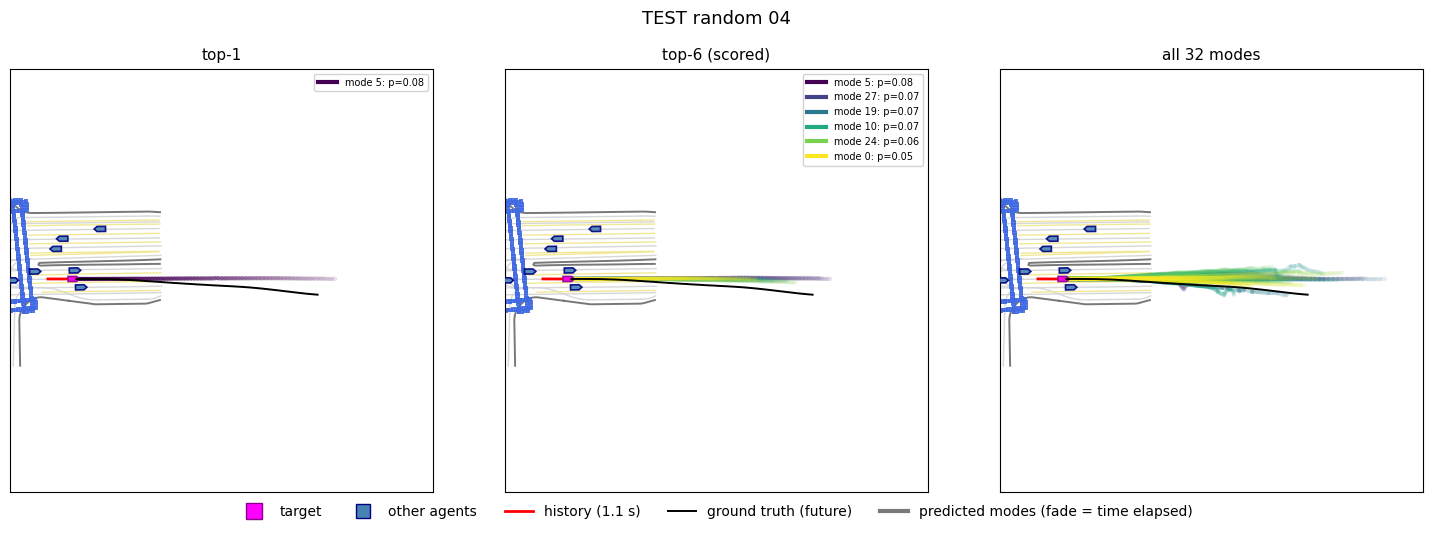

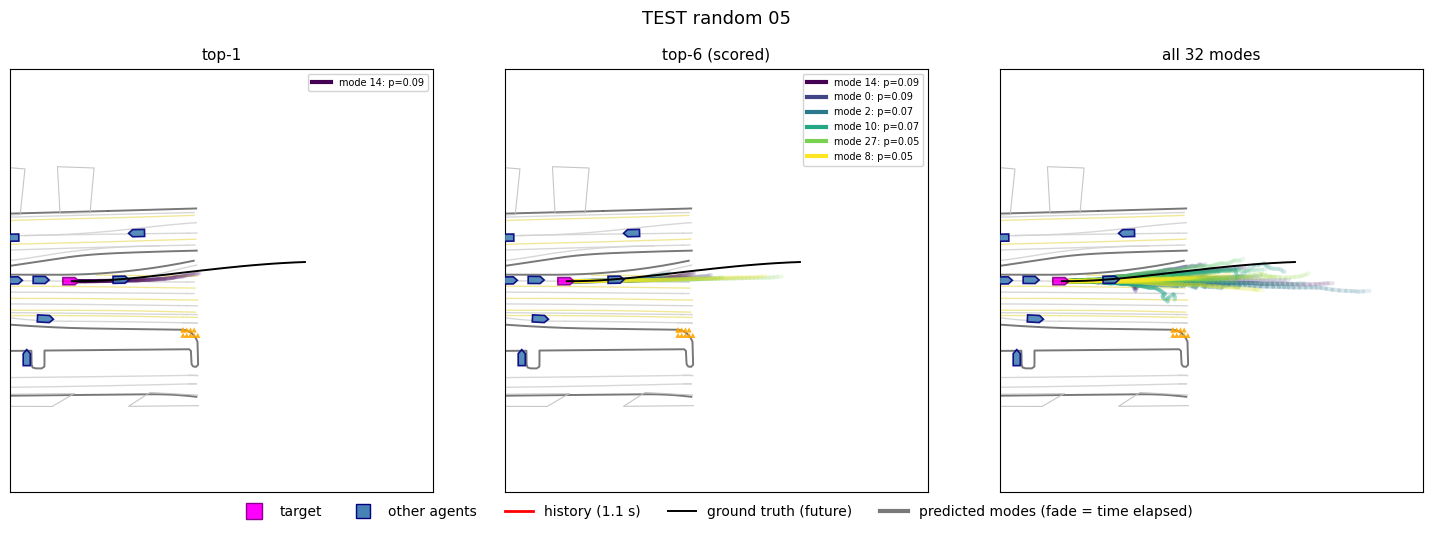

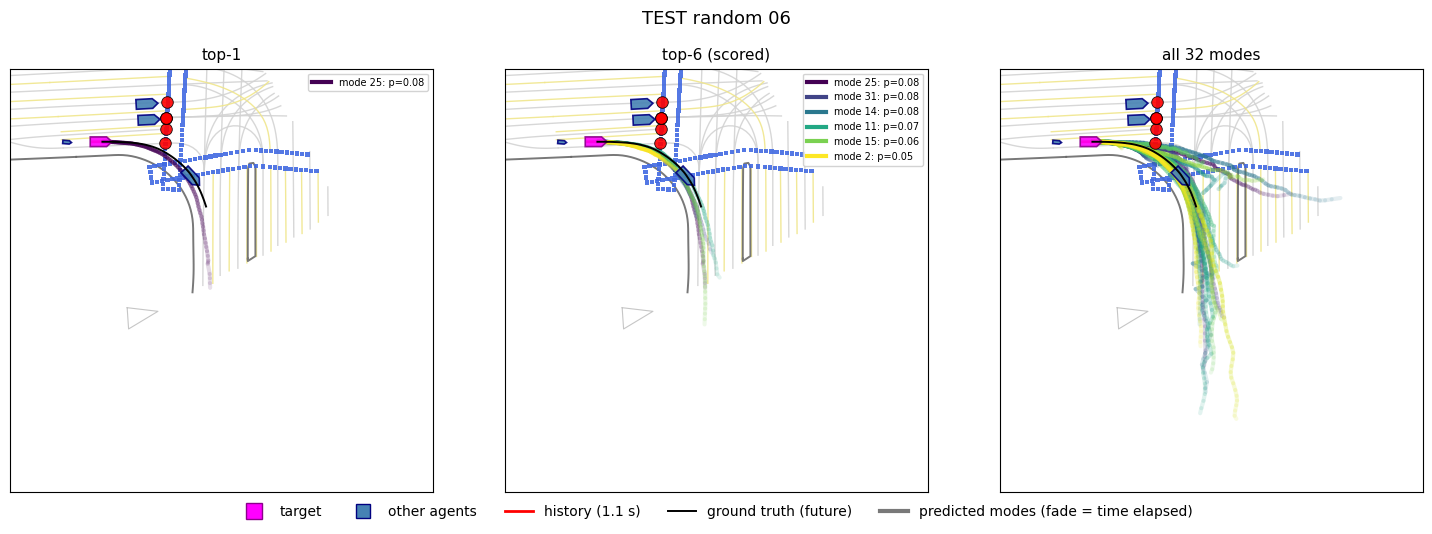

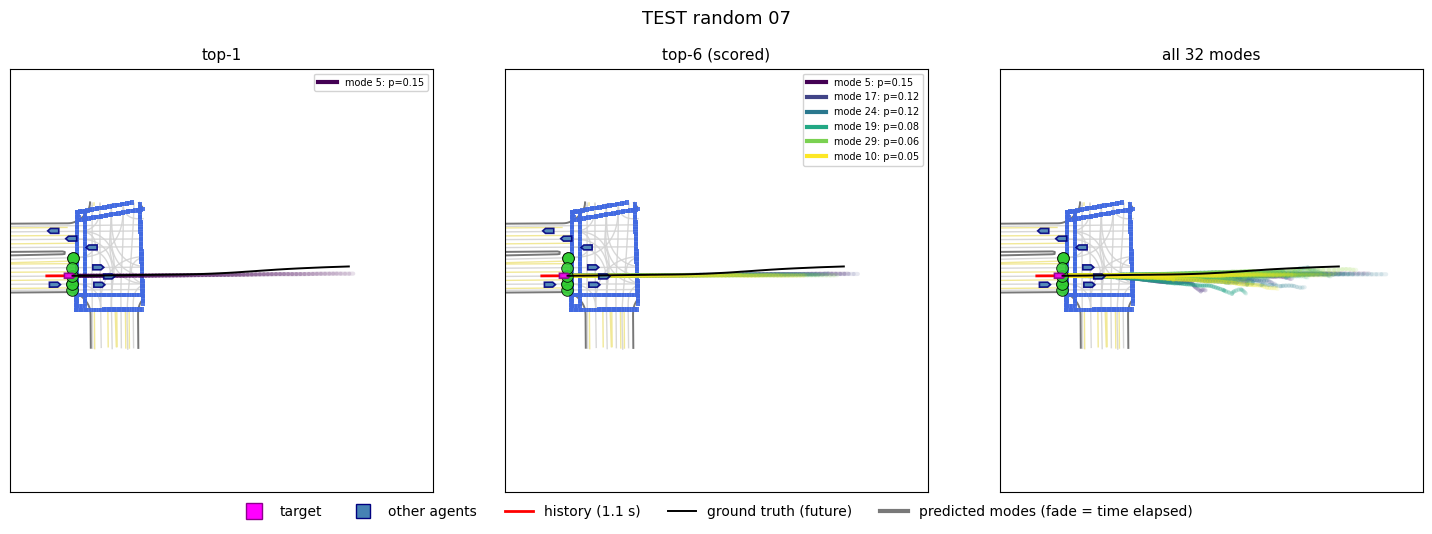

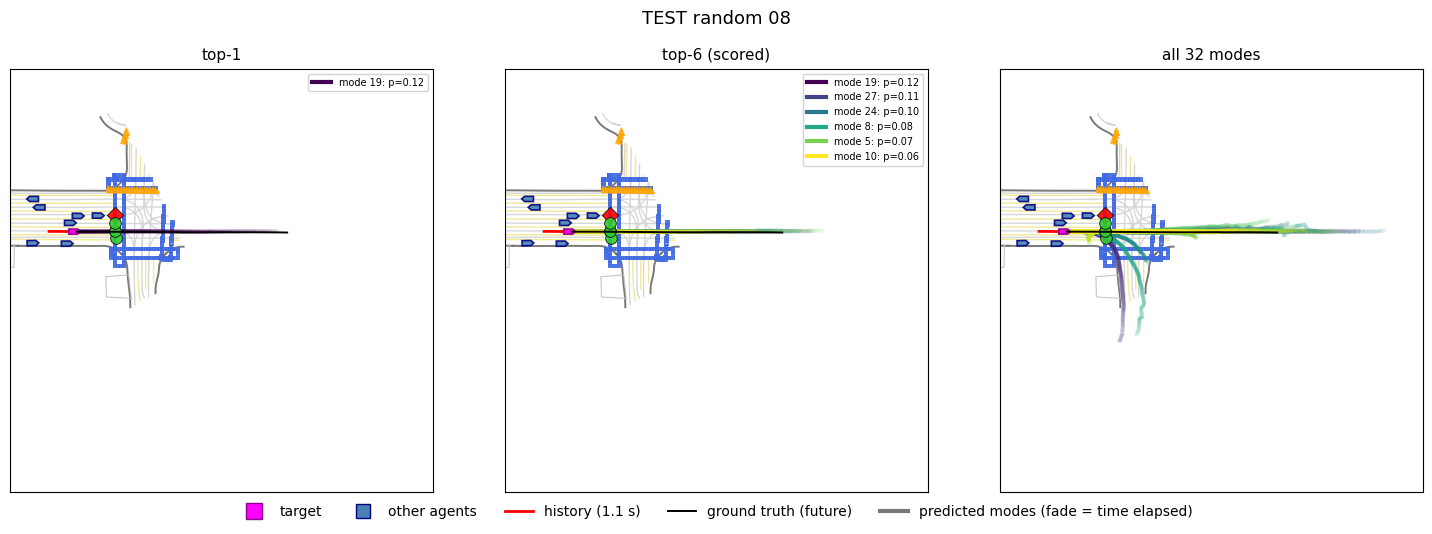

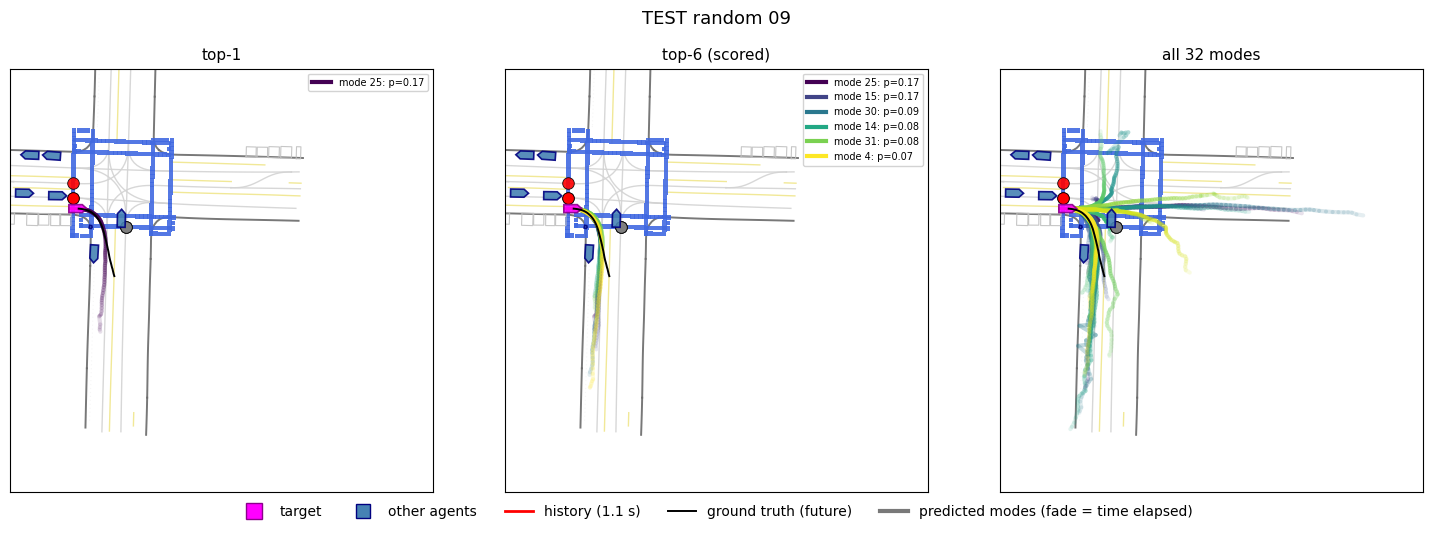

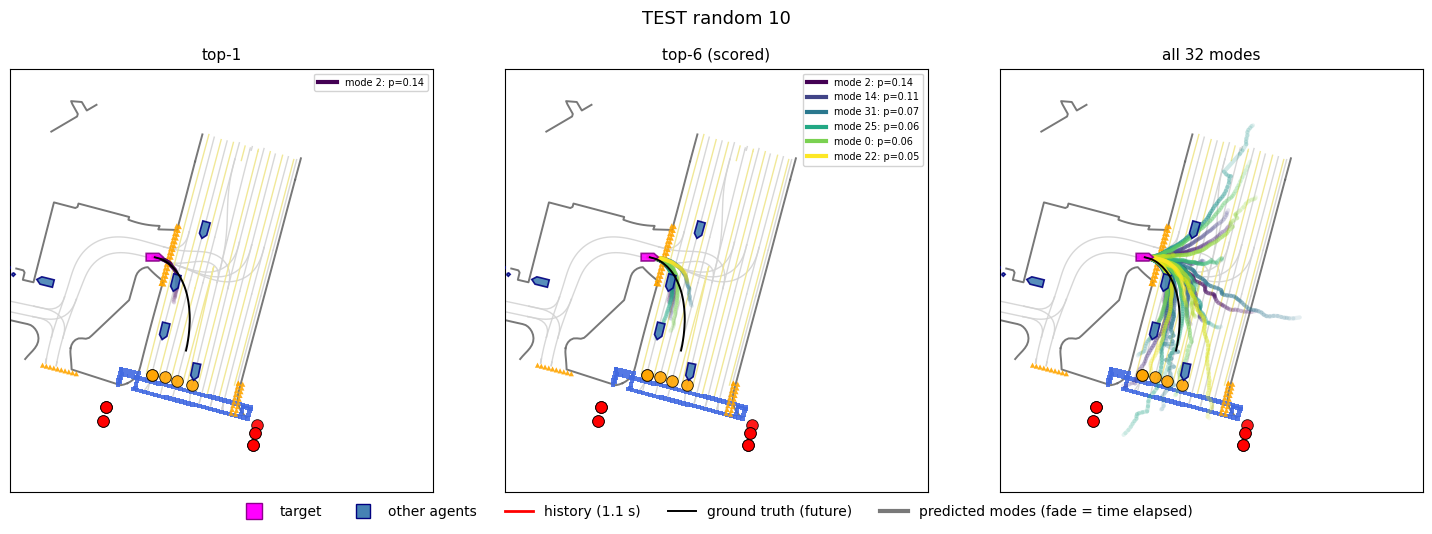

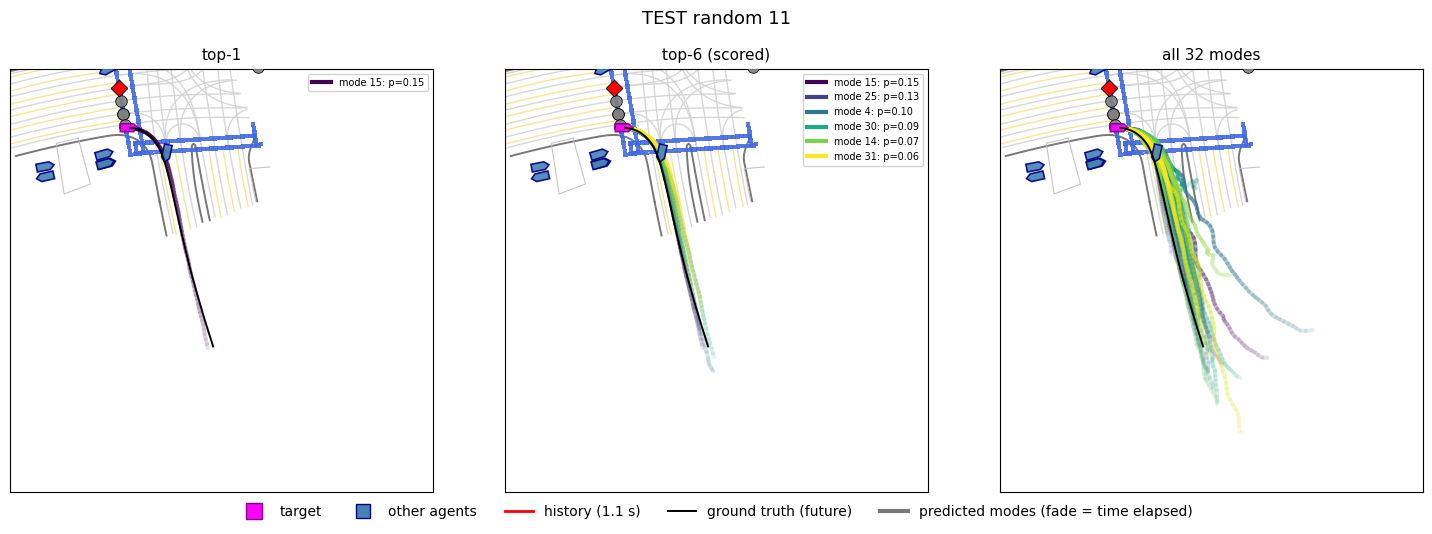

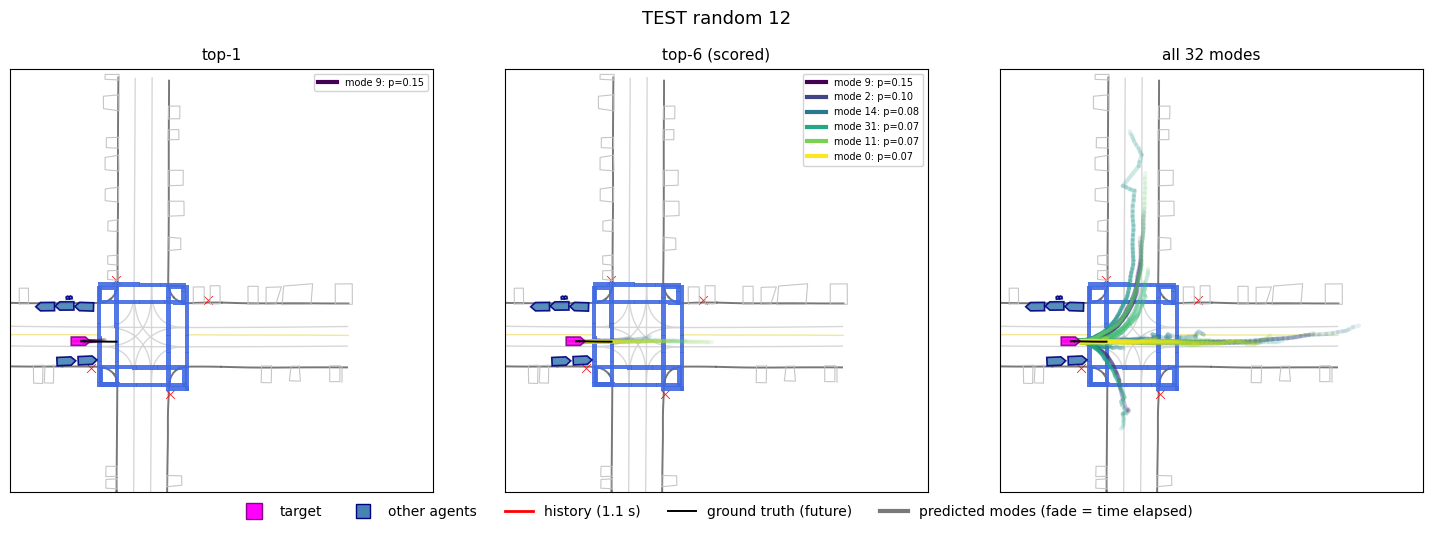

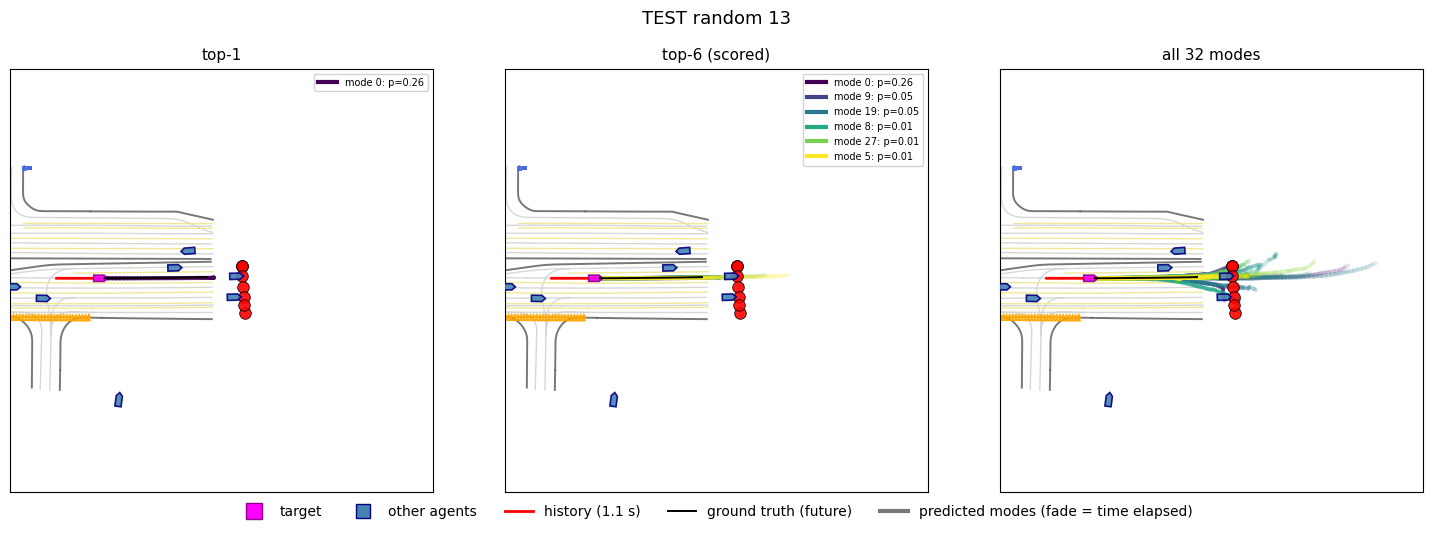

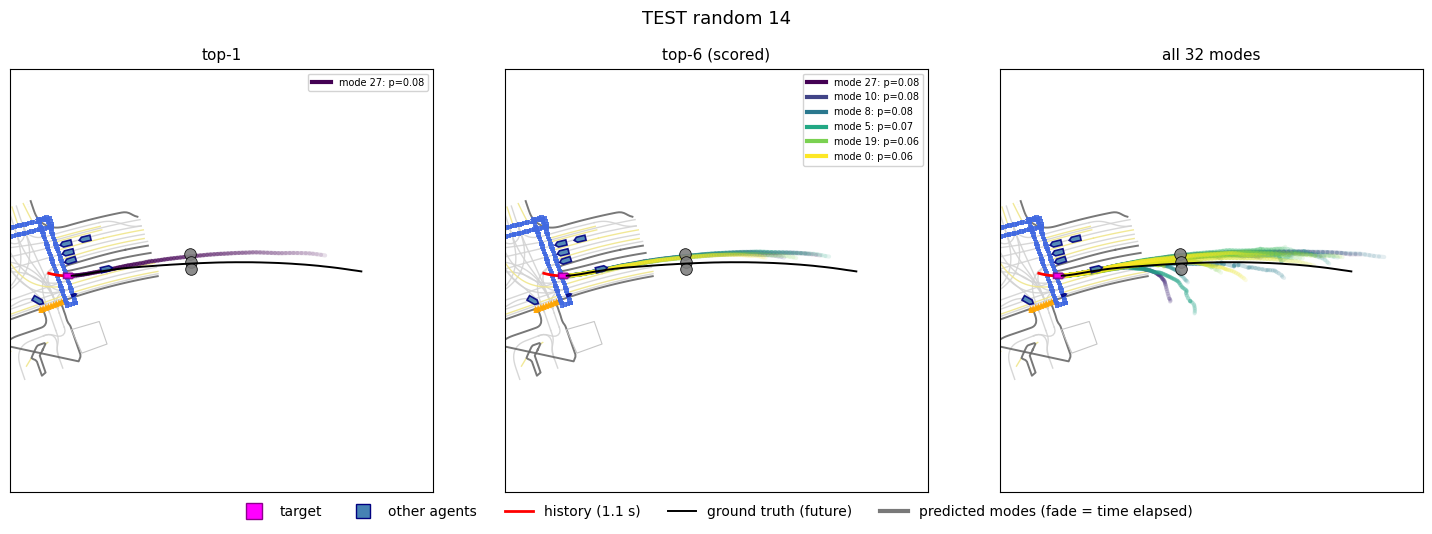

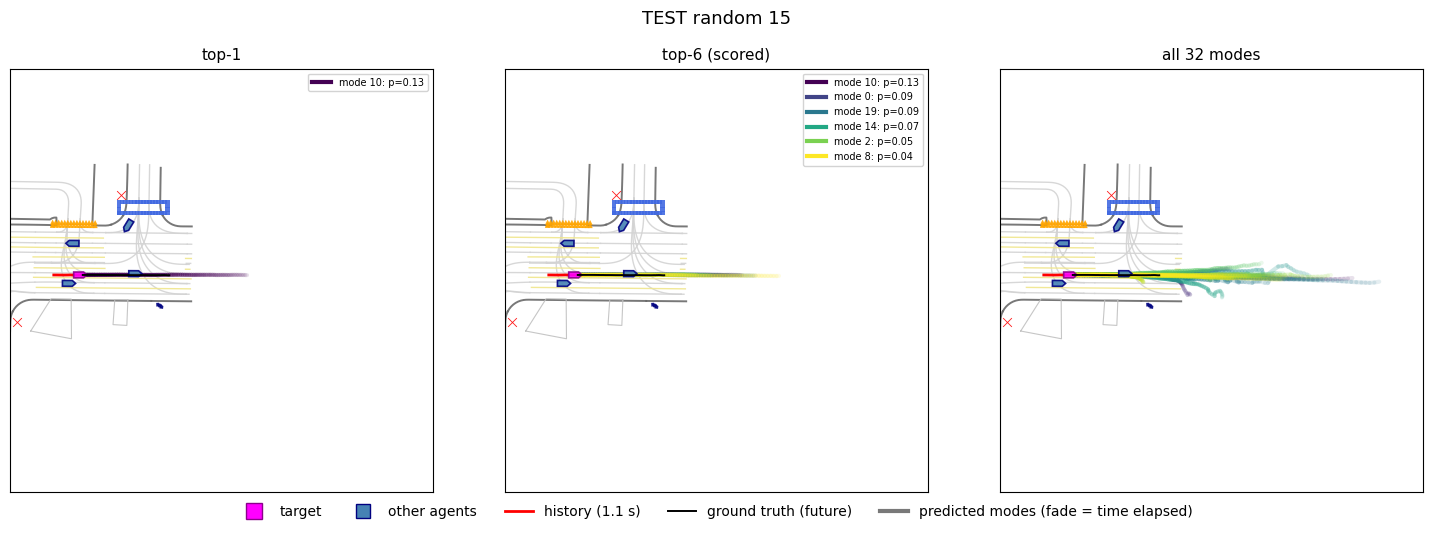

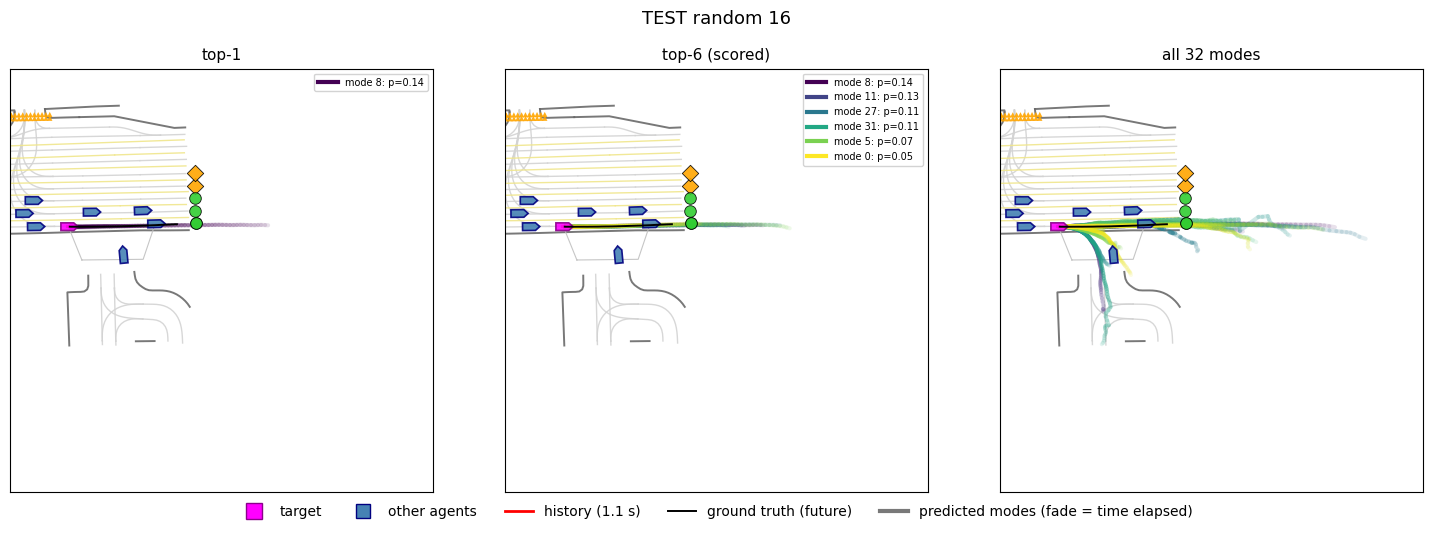

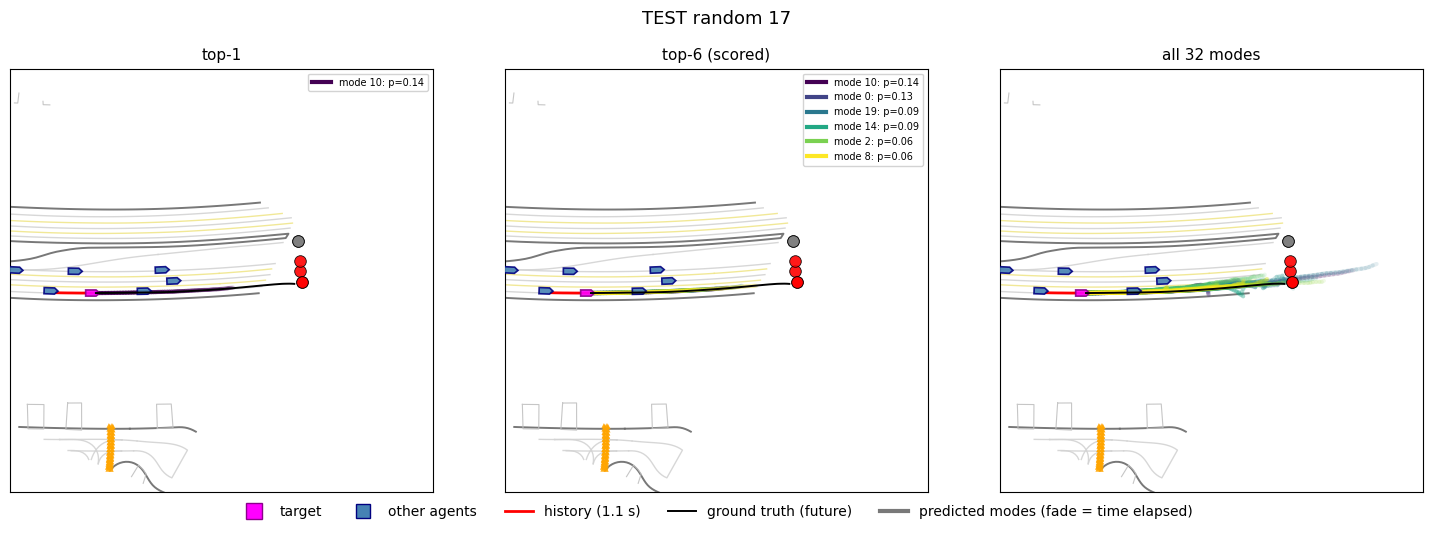

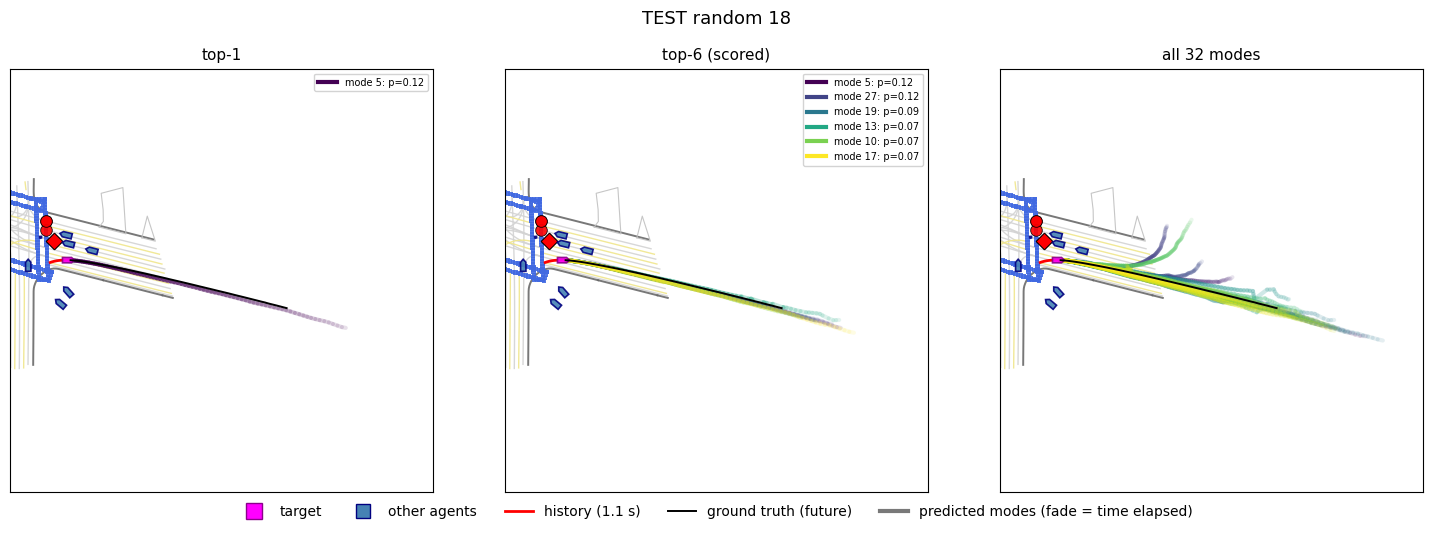

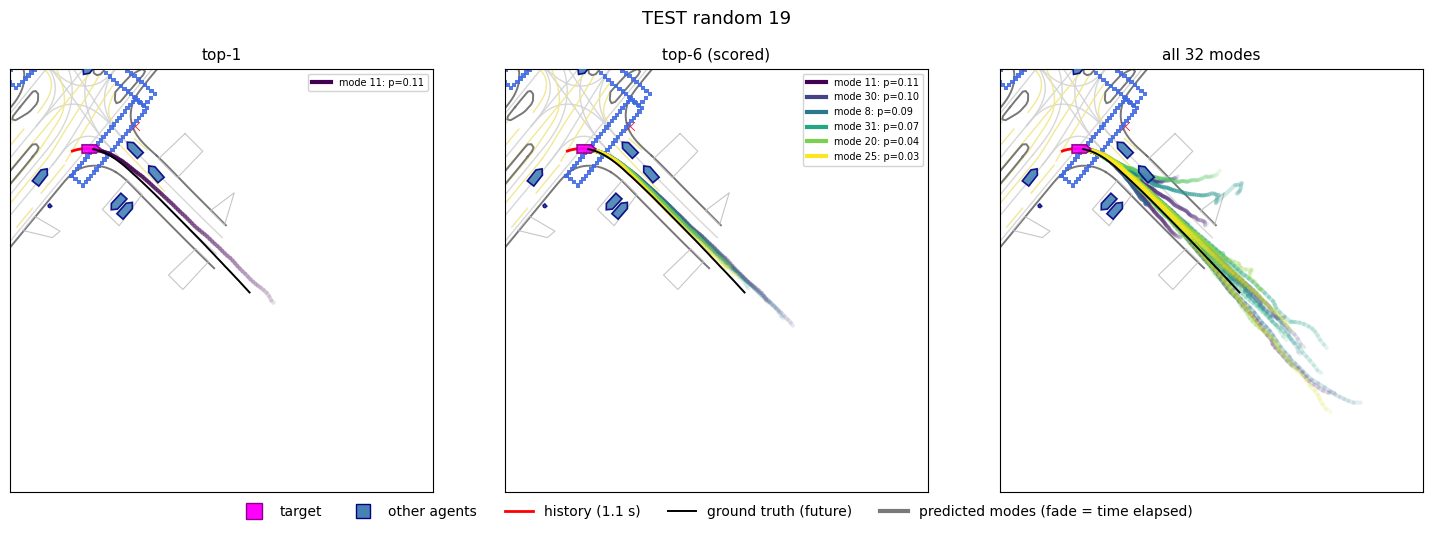

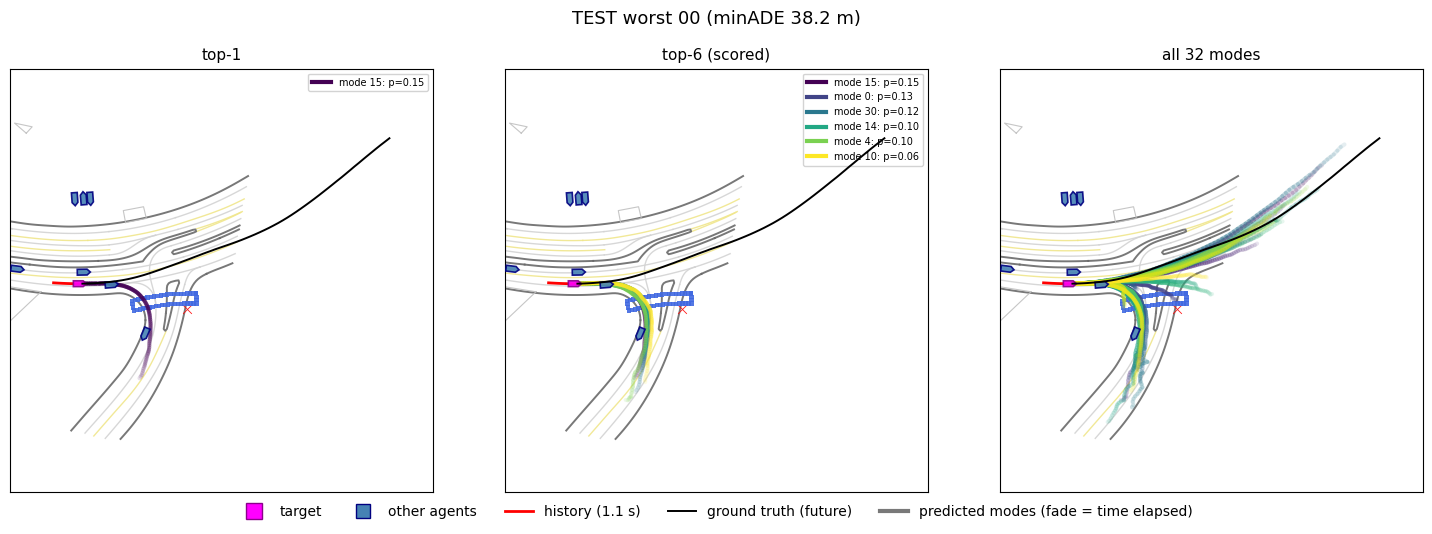

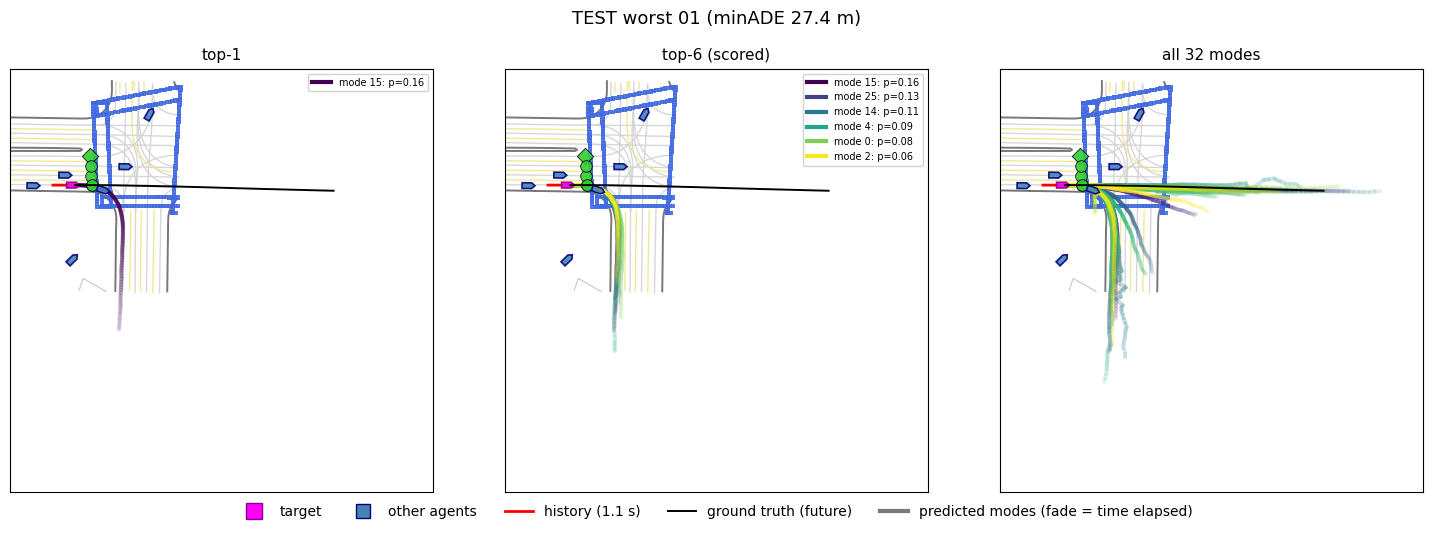

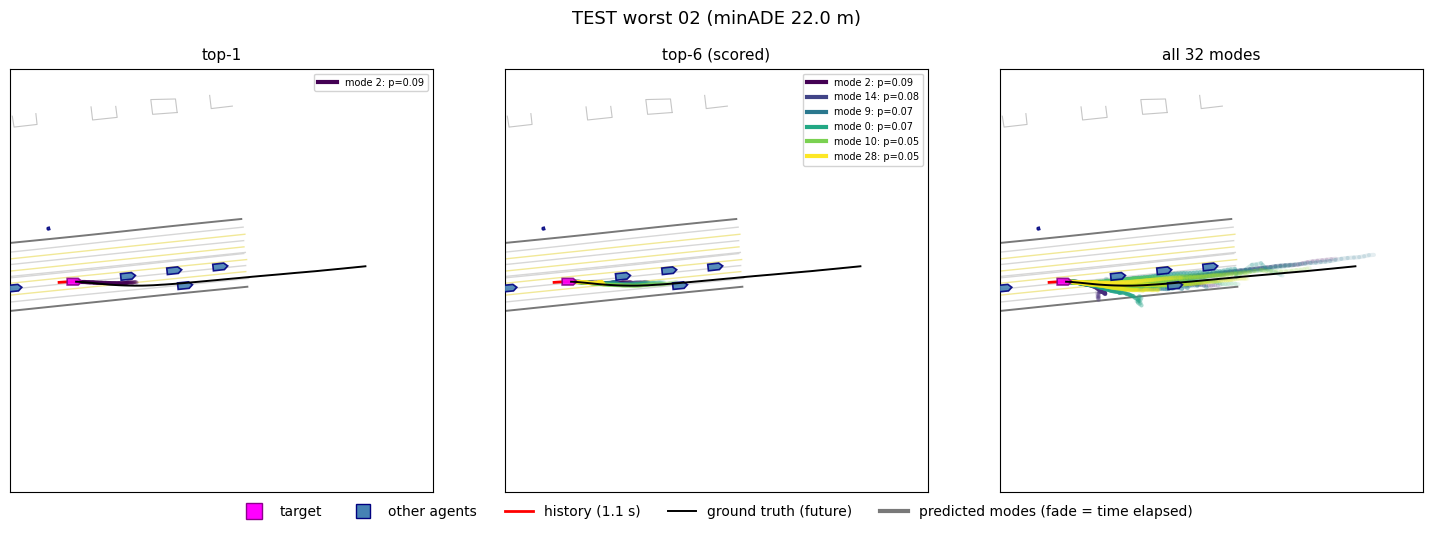

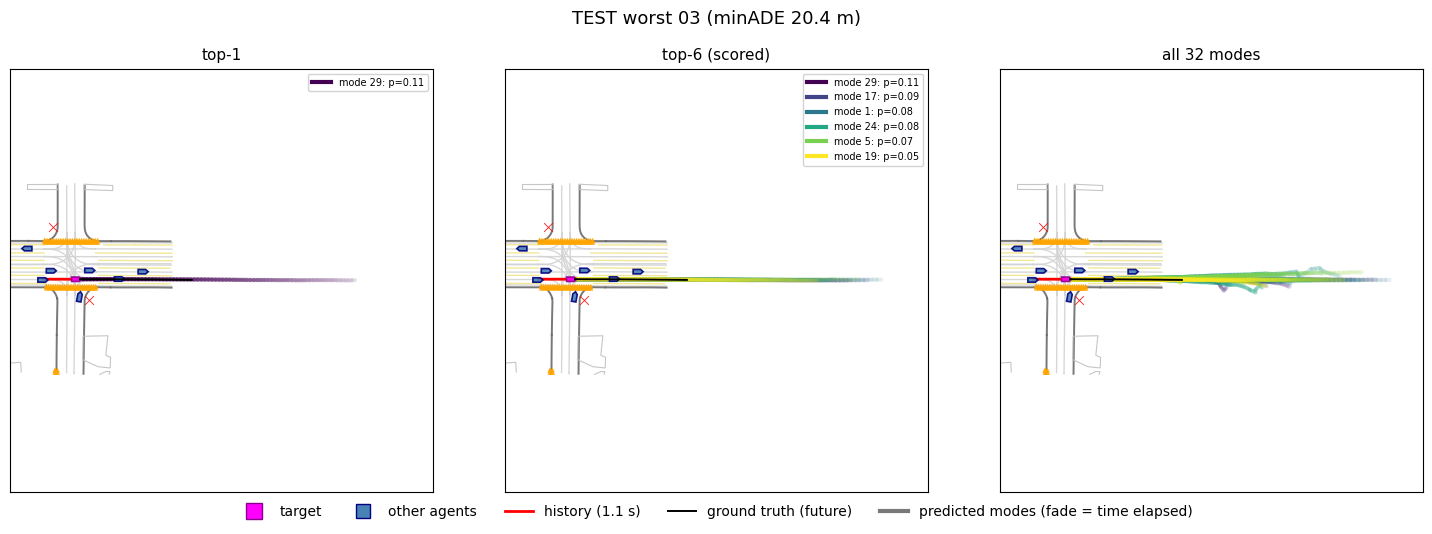

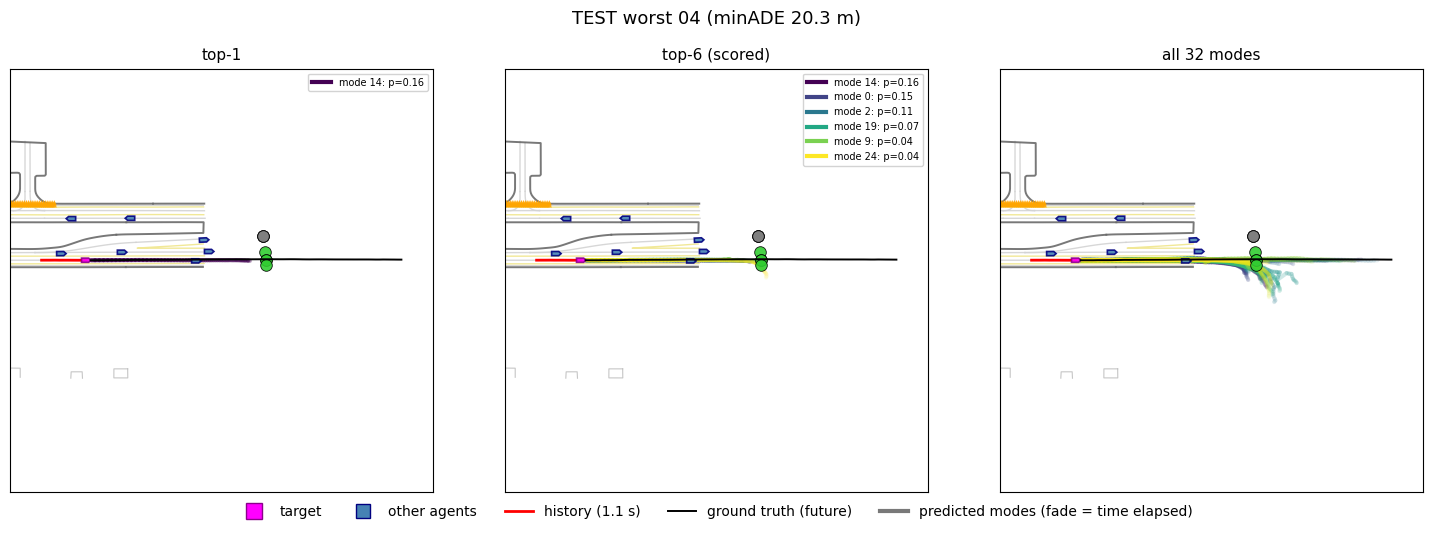

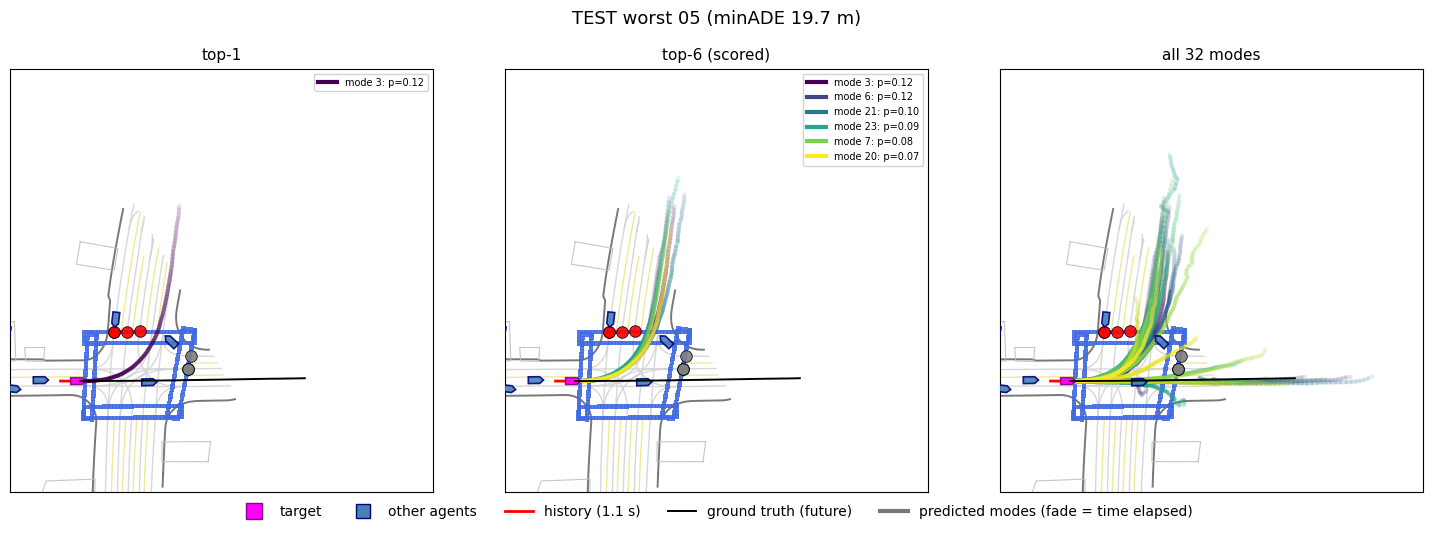

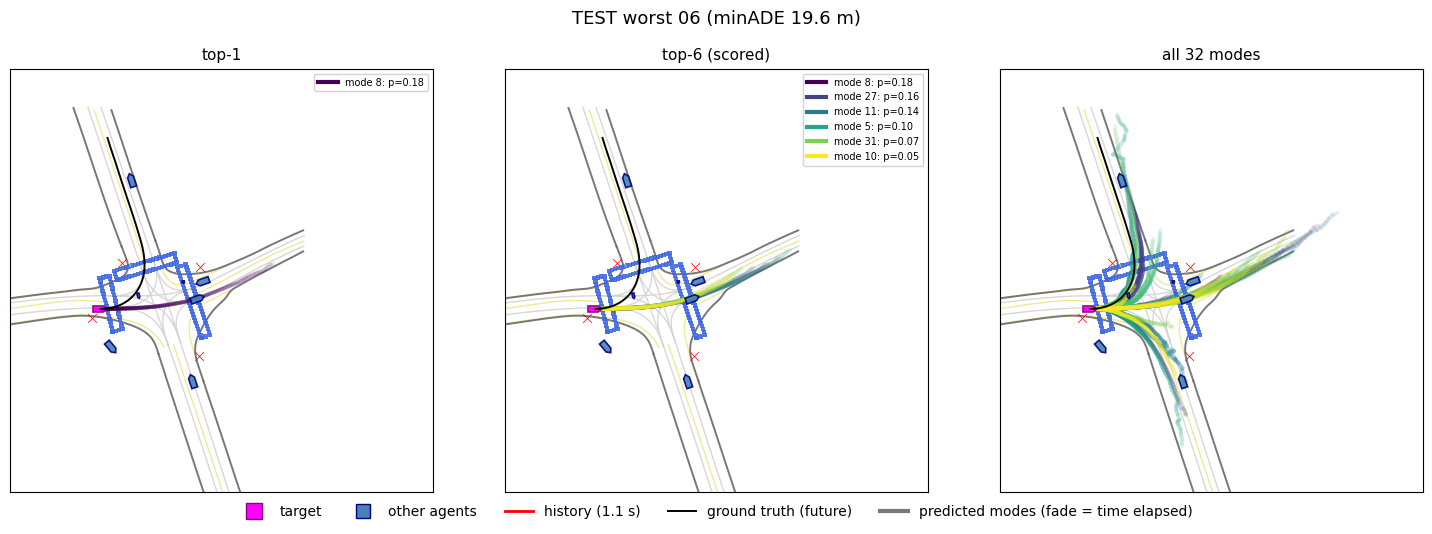

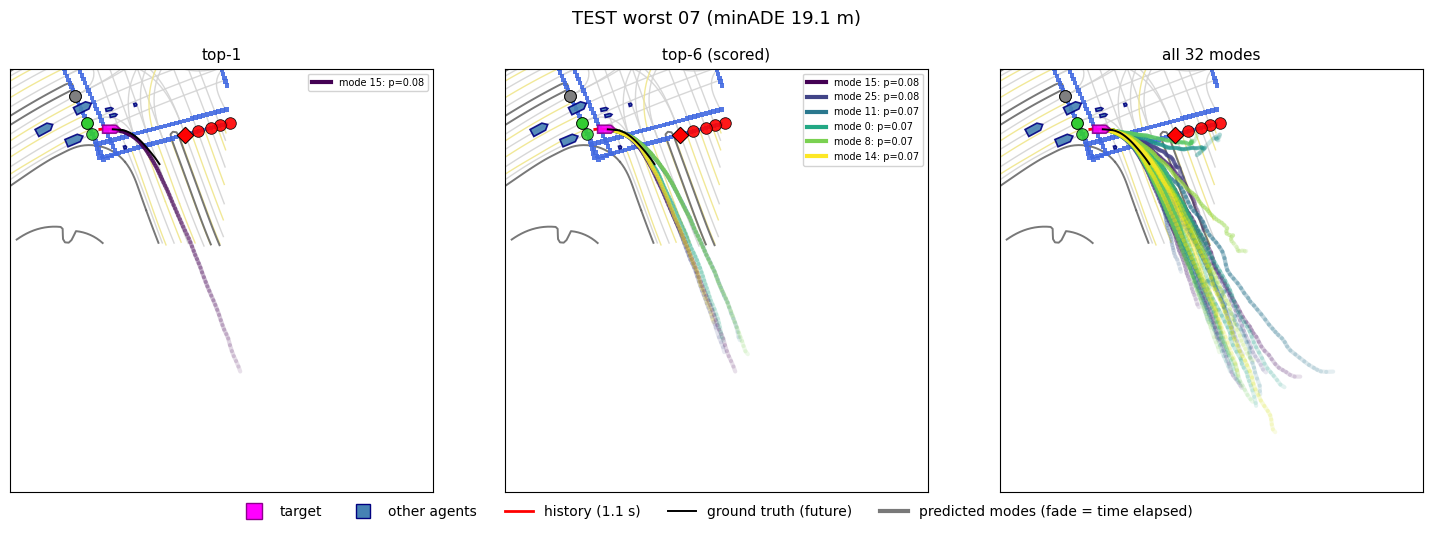

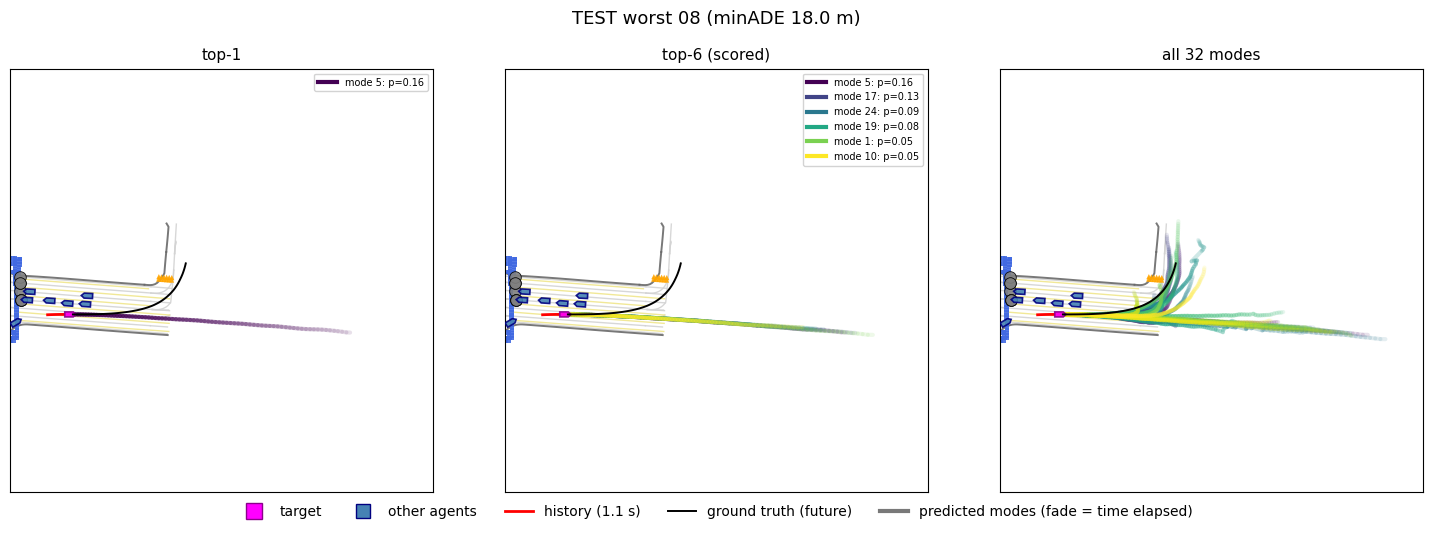

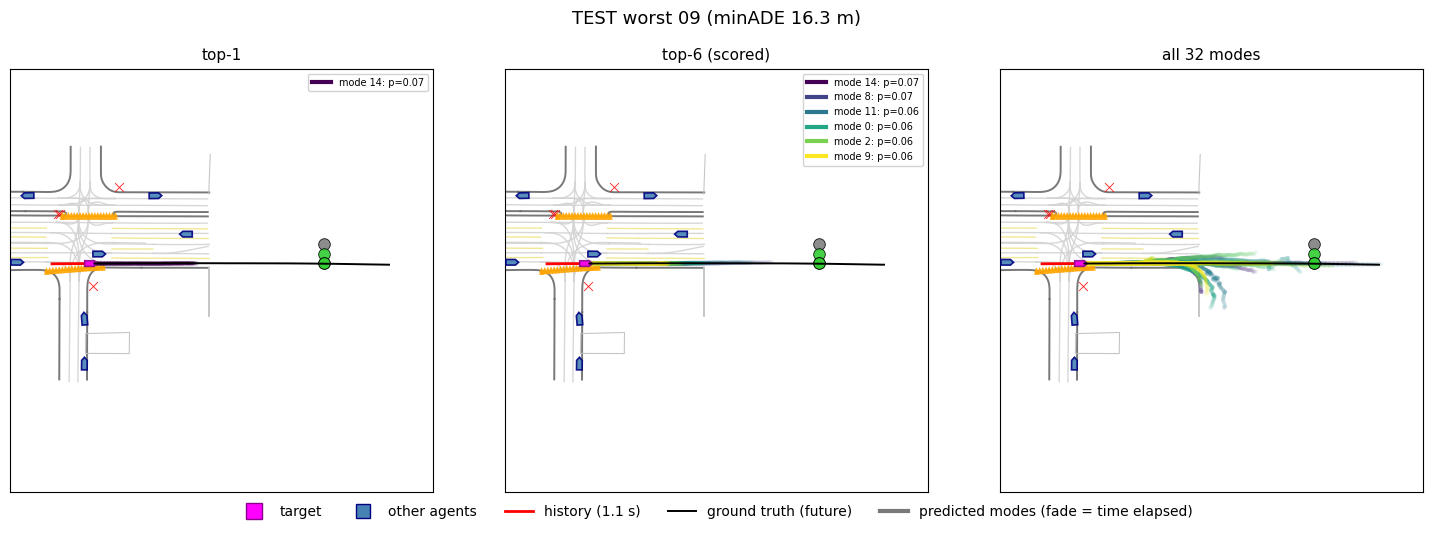

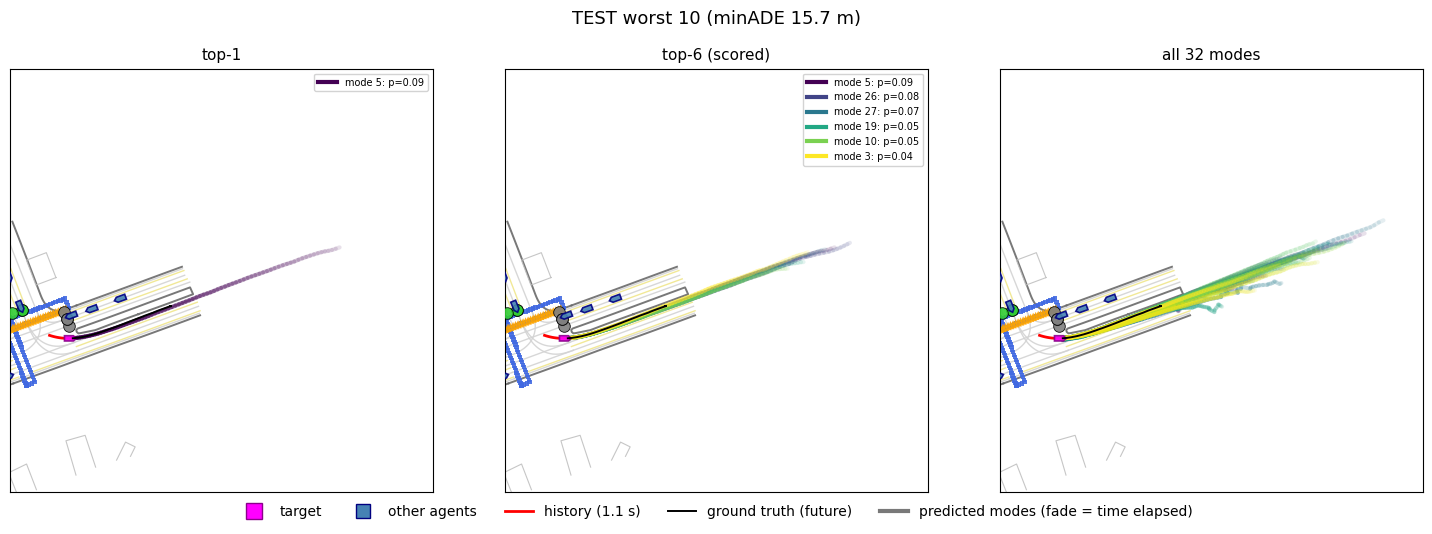

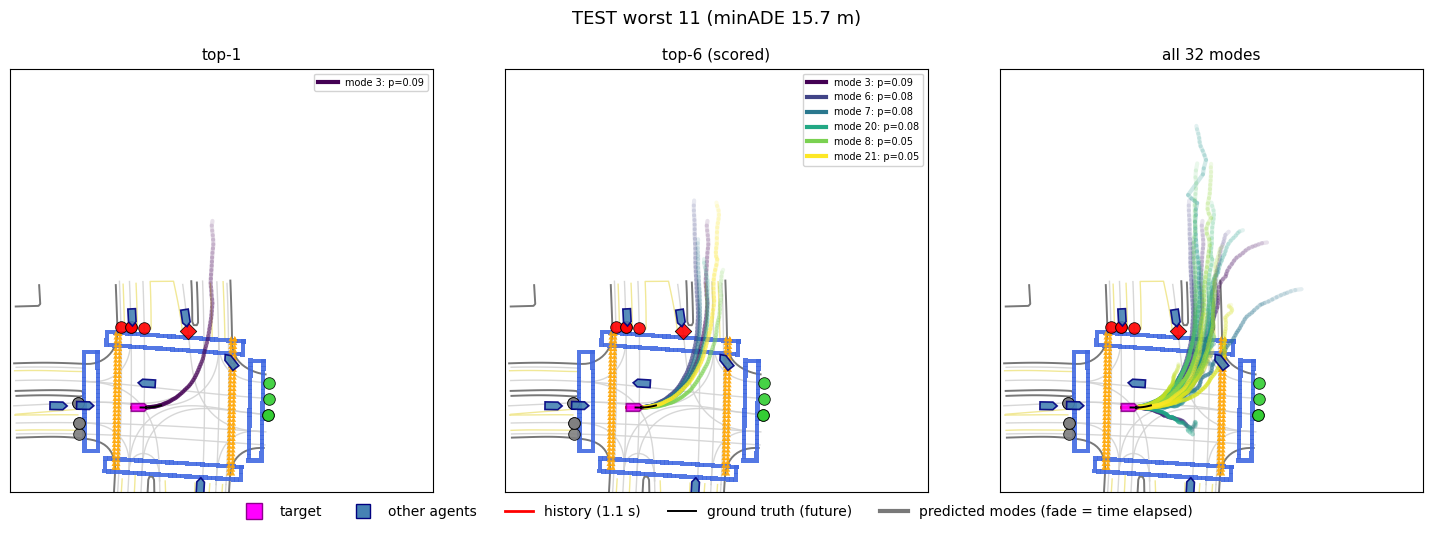

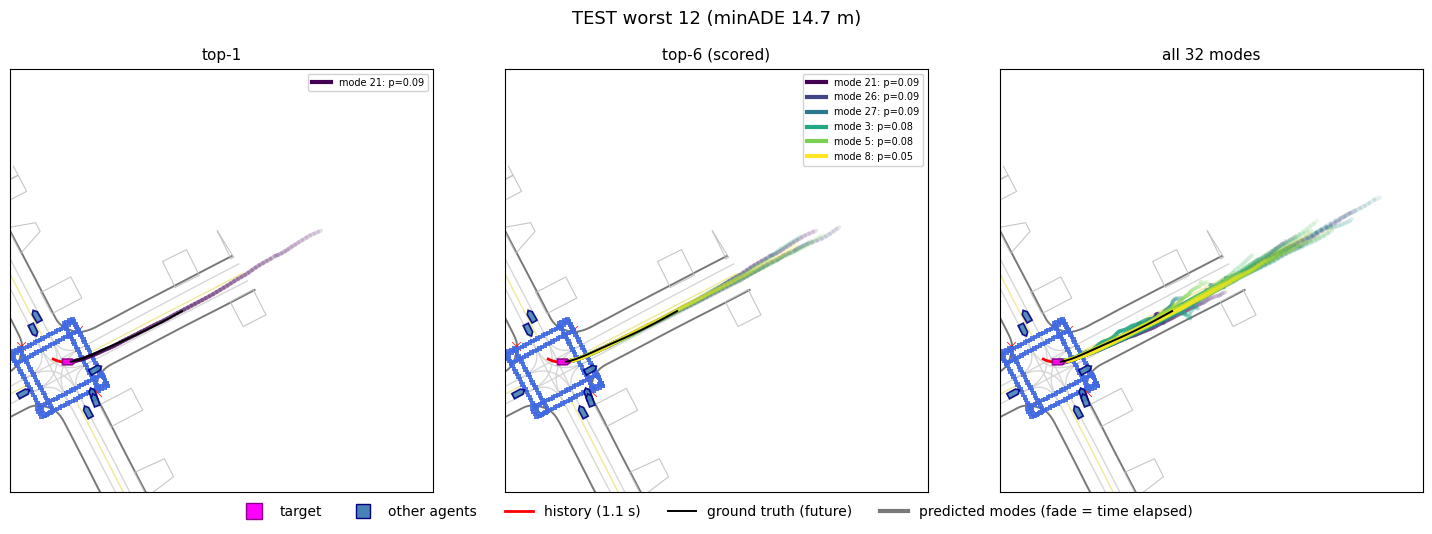

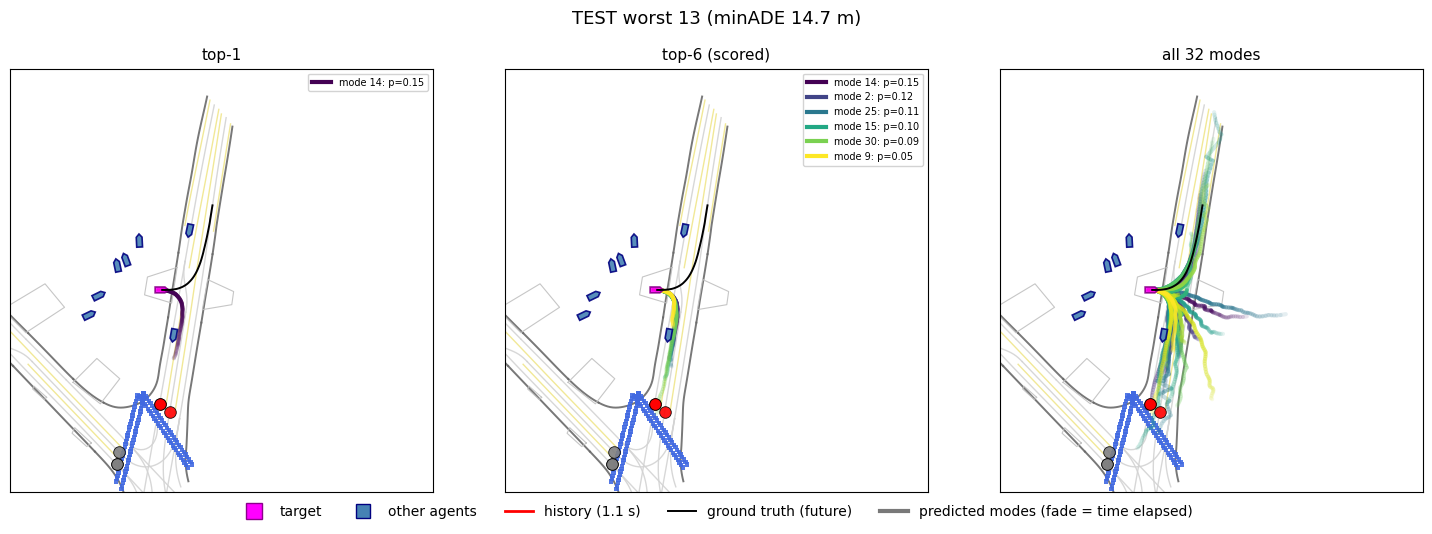

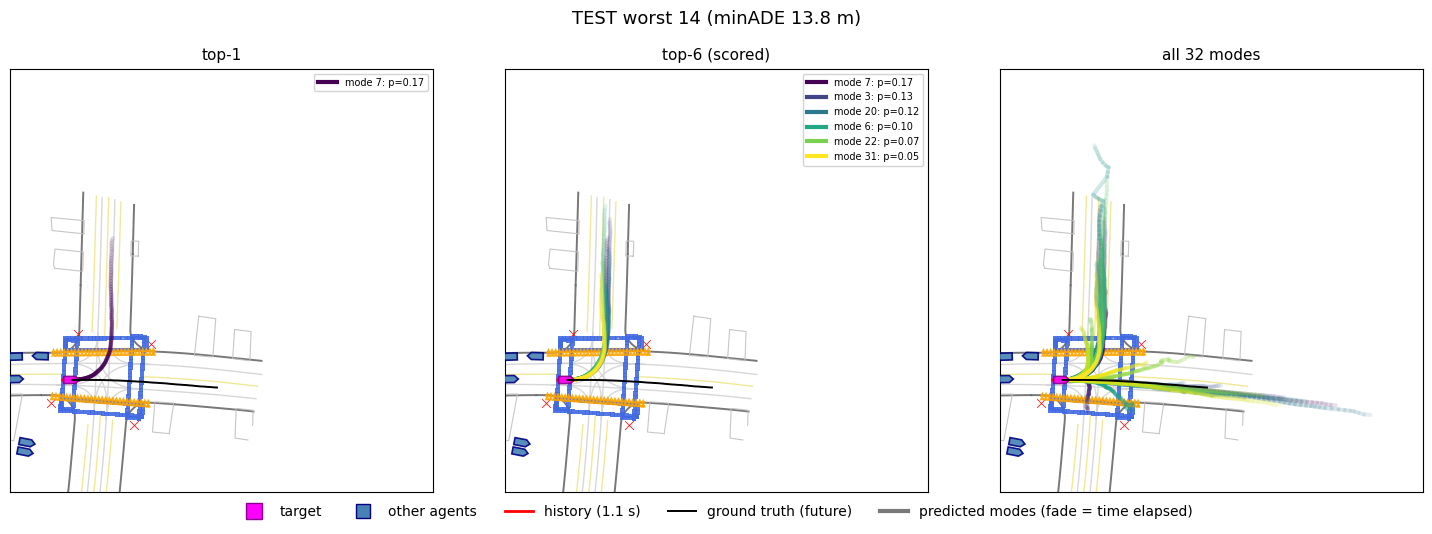

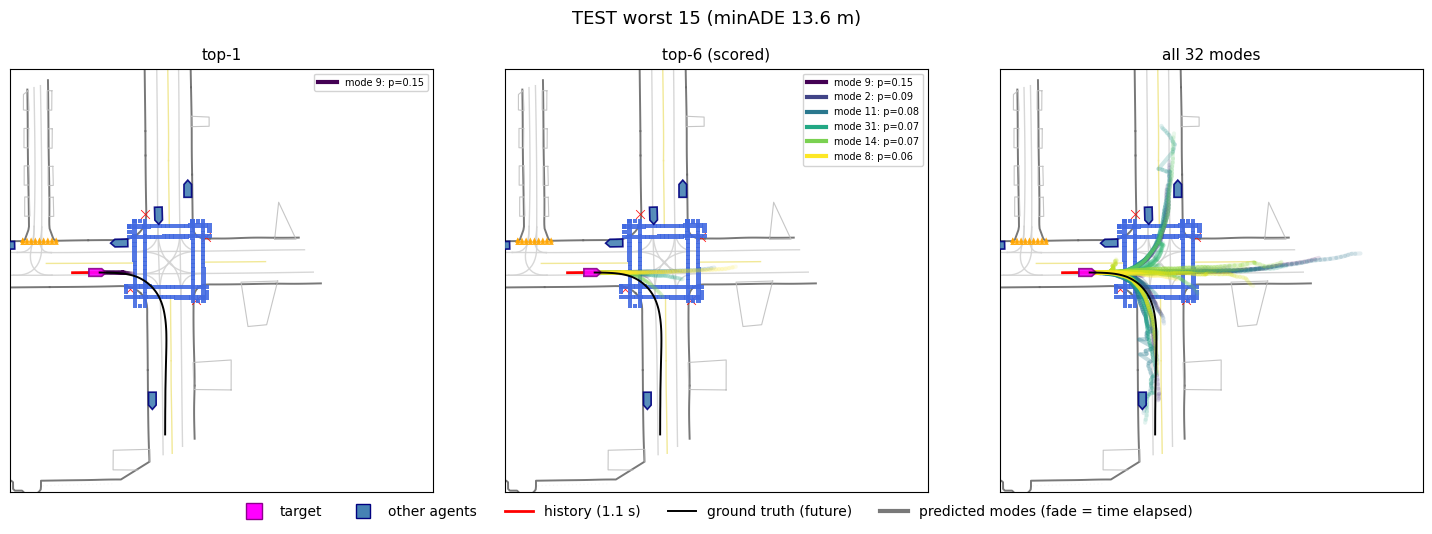

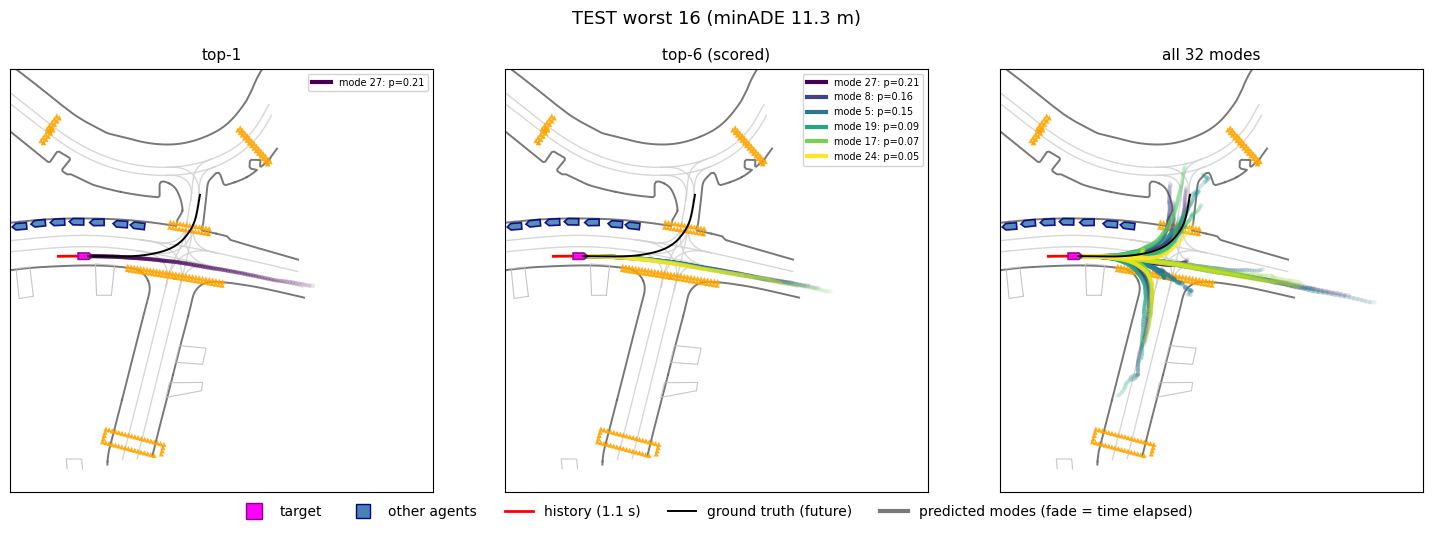

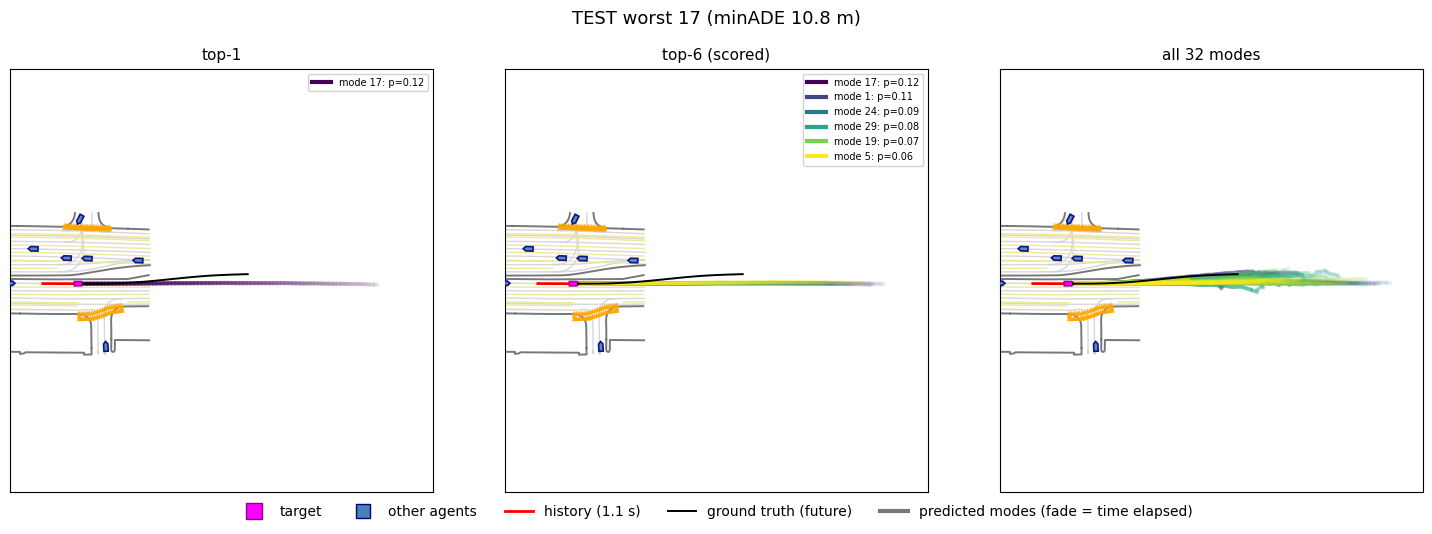

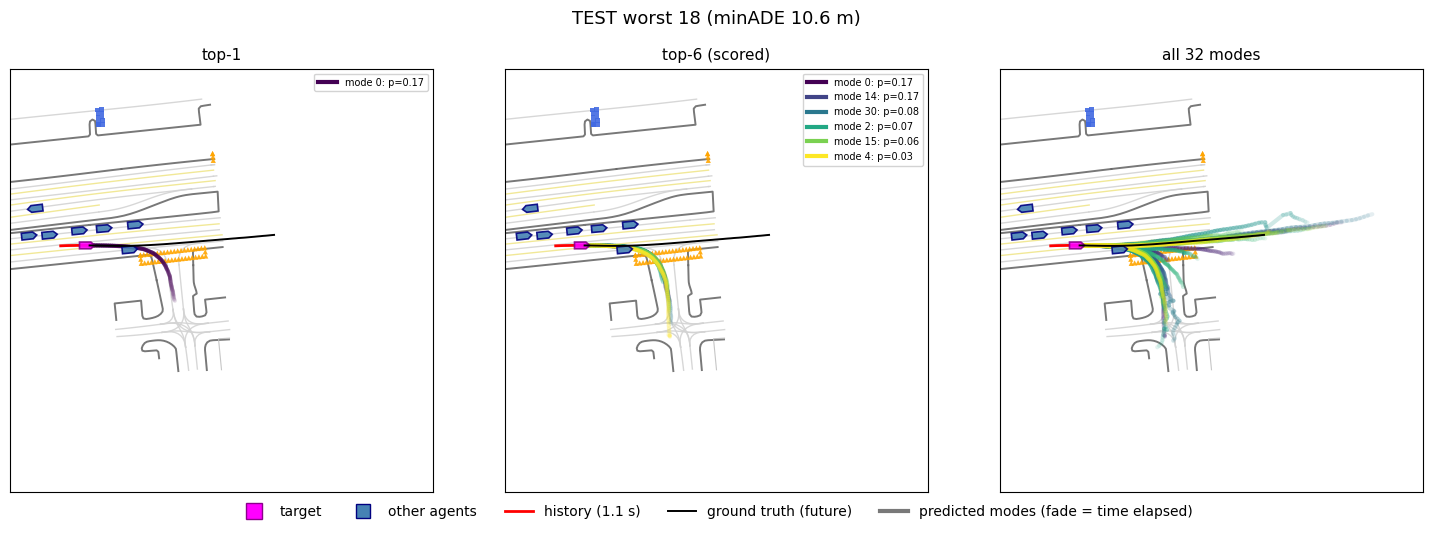

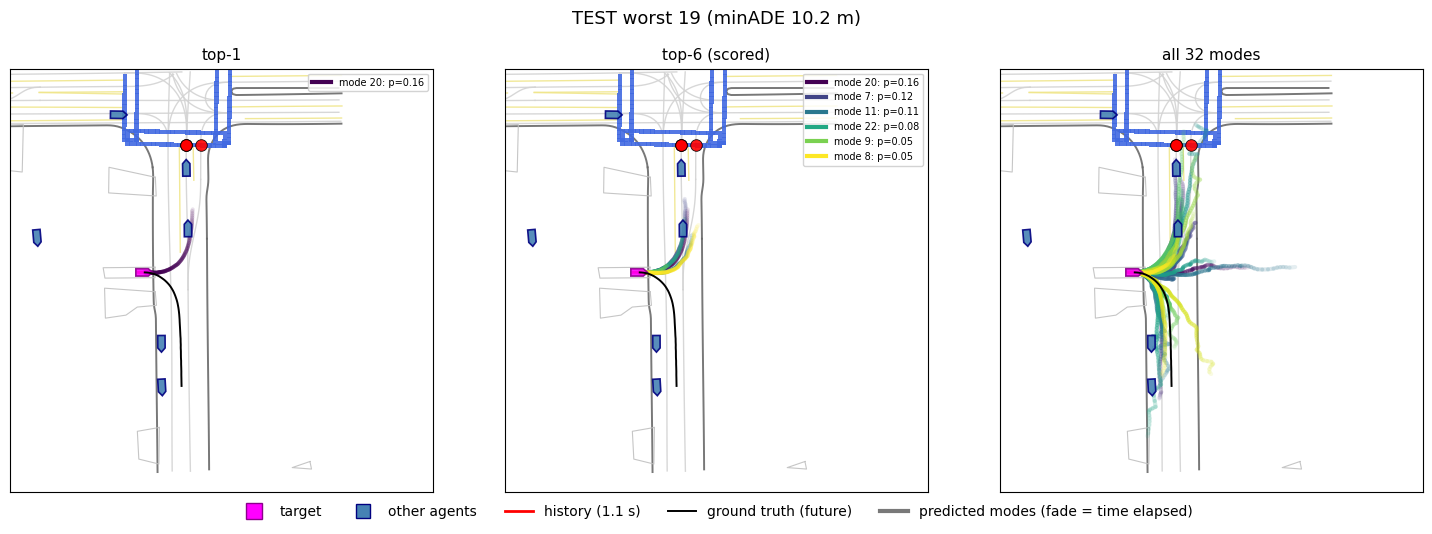

In [30]:
# Prediction plots for held-out TEST scenes, in the agent frame. Three sets so we don't only see
# flattering cases: turn-like, random, and the worst by minADE. Each scene is three square panels:
# top-1, the scored top-6, and all 32 modes. Predicted paths are thick and fade from solid at t=0 to
# faint at 8 s (Wayformer style), colored by mode. History is red, ground truth thin black (drawn last,
# on top). The target and neighbor agents are drawn as oriented car footprints (magenta = target,
# blue = neighbors). The top-1 and top-6 panels also show each drawn mode's probability in a top-right
# legend. The wide road graph is for viewing only. Every figure is saved to <run_dir>/plots/.

import os, re
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

VIZ_ROAD_RADIUS_M = 150.0
VIZ_MAX_ROAD_POINTS = 2000
N_VIZ_SAMPLES = 20     # turn-like scenes
N_VIZ_RANDOM = 20
N_VIZ_WORST = 20

# Rough footprint (length, width) in metres per agent type slot (0 vehicle, 1 pedestrian, 2 cyclist).
CAR_SIZES = {0: (4.5, 2.0), 1: (0.7, 0.7), 2: (1.8, 0.7)}

# Save plots next to the checkpoint that cell 16 loaded, so the folder always matches the model.
try:
    RUN_DIR = os.path.dirname(BEST_CHECKPOINT_PATH)
except NameError:
    RUN_DIR = "/content/drive/MyDrive/waymo_trajectory/run_20260929_1110"
PLOTS_DIR = os.path.join(RUN_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Saving plots to {PLOTS_DIR}")


def is_lane_change_like(scene_inputs, angle_threshold_deg=20):
    fut = scene_inputs["future_xy"].numpy()
    valid = scene_inputs["future_valid"].numpy().astype(bool)
    pts = fut[valid]
    if len(pts) < 12:
        return False
    v0 = pts[5] - pts[0]
    v1 = pts[-1] - pts[-6]
    if np.linalg.norm(v0) < 1e-3 or np.linalg.norm(v1) < 1e-3:
        return False
    cos_angle = np.dot(v0, v1) / (np.linalg.norm(v0) * np.linalg.norm(v1) + 1e-6)
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1))) > angle_threshold_deg


def draw_faded_traj(ax, xy, color, lw=3.0, a_hi=0.85, a_lo=0.12, zorder=2):
    # One trajectory as a thick line whose alpha fades from a_hi at t=0 to a_lo at 8 s,
    # so later (less certain) steps look fainter -- the Wayformer style.
    pts = xy.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    n = len(segs)
    rgba = np.zeros((n, 4))
    rgba[:, :3] = to_rgb(color)
    rgba[:, 3] = np.linspace(a_hi, a_lo, n)
    ax.add_collection(LineCollection(segs, colors=rgba, linewidths=lw, zorder=zorder, capstyle="round"))


def draw_car(ax, cx, cy, theta, length, width, facecolor, edgecolor, zorder, alpha=0.9):
    # An oriented car footprint: a rectangle with a pointed front, so heading is readable.
    l, w = length / 2.0, width / 2.0
    nose = length * 0.25
    local = np.array([[l, 0.0], [l - nose, w], [-l, w], [-l, -w], [l - nose, -w]])
    c, s = math.cos(theta), math.sin(theta)
    pts = local @ np.array([[c, -s], [s, c]]).T + np.array([cx, cy])
    ax.add_patch(Polygon(pts, closed=True, facecolor=facecolor, edgecolor=edgecolor,
                         linewidth=1.2, alpha=alpha, zorder=zorder))


def draw_agents(ax, agent_feats, agent_valid):
    # Draw each agent's current-position footprint (target = row 0). Positions and heading come
    # straight from the agent-frame features (x, y are /POS_SCALE_M; cols 4,5 are cos/sin of heading).
    for i in range(agent_feats.shape[0]):
        vt = np.where(agent_valid[i] > 0)[0]
        if len(vt) == 0:
            continue
        t = vt[-1]
        px, py = agent_feats[i, t, 0] * POS_SCALE_M, agent_feats[i, t, 1] * POS_SCALE_M
        theta = math.atan2(agent_feats[i, t, 5], agent_feats[i, t, 4])
        oh = agent_feats[i, t, 6:9]
        ttype = int(np.argmax(oh)) if oh.sum() > 0 else -1
        length, width = CAR_SIZES.get(ttype, (2.0, 2.0))
        if i == 0:
            draw_car(ax, px, py, theta, length, width, "magenta", "darkmagenta", zorder=6)
        else:
            draw_car(ax, px, py, theta, length, width, "steelblue", "navy", zorder=5)


def plot_prediction(model, scene_inputs, viz_road_xy, viz_road_type, viz_road_id, title="Prediction"):
    model.eval()
    with torch.no_grad():
        batch = collate_scenes([scene_inputs])
        feats, valid, _, _, road_xy, road_type, road_valid, heading = [t.to(DEVICE) for t in batch]
        pred_trajs_t, pred_confs, _ = model(feats, valid, road_xy, road_type, road_valid, heading)
        sel_idx, _ = select_modes(pred_trajs_t, pred_confs, EVAL_TOP_K)
        order = sel_idx[0].cpu().numpy()
        probs = F.softmax(pred_confs, dim=-1)[0].cpu().numpy()
        pred_trajs = pred_trajs_t[0].cpu().numpy()
    model.train()

    agent_feats = scene_inputs["agent_feats"].numpy()   # [A, T, F], agent frame
    agent_valid = scene_inputs["agent_valid"].numpy()   # [A, T]
    gt = scene_inputs["future_xy"].numpy()
    gt_valid = scene_inputs["future_valid"].numpy().astype(bool)
    past = agent_feats[0, :, :2] * POS_SCALE_M
    past_valid = agent_valid[0] > 0
    M = pred_trajs.shape[0]

    # One square window shared by all three panels, framed on all NUM_MODES so nothing is clipped.
    allpts = np.concatenate([pred_trajs.reshape(-1, 2), gt[gt_valid], past[past_valid], np.zeros((1, 2))])
    cx = 0.5 * (allpts[:, 0].min() + allpts[:, 0].max())
    cy = 0.5 * (allpts[:, 1].min() + allpts[:, 1].max())
    half = 0.5 * max(np.ptp(allpts[:, 0]), np.ptp(allpts[:, 1])) + 15.0

    # (title, mode indices to draw, whether to show a per-mode probability legend)
    panels = [("top-1", order[:1], True),
              (f"top-{len(order)} (scored)", order, True),
              (f"all {M} modes", np.arange(M), False)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
    cmap = plt.cm.viridis
    for ax, (ptitle, idxs, show_probs) in zip(axes, panels):
        draw_road_graph(ax, viz_road_xy, viz_road_type, viz_road_id)
        mode_handles = []
        for j, m in enumerate(idxs):
            color = cmap(j / max(len(idxs) - 1, 1))
            draw_faded_traj(ax, pred_trajs[m], color, lw=3.0)
            if show_probs:
                mode_handles.append(Line2D([0], [0], color=color, lw=3.0, label=f"mode {m}: p={probs[m]:.2f}"))
        # History (red), then the agent footprints, then ground truth LAST so it sits on top.
        ax.plot(past[past_valid, 0], past[past_valid, 1], "-", color="red", linewidth=2.0, zorder=3)
        draw_agents(ax, agent_feats, agent_valid)
        ax.plot(gt[gt_valid, 0], gt[gt_valid, 1], "-", color="black", linewidth=1.4, zorder=20)
        ax.set_xlim(cx - half, cx + half)
        ax.set_ylim(cy - half, cy + half)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(ptitle, fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
        if show_probs:
            ax.legend(handles=mode_handles, loc="upper right", fontsize=7, framealpha=0.85)

    handles = [
        Line2D([0], [0], marker="s", color="none", markerfacecolor="magenta",
               markeredgecolor="darkmagenta", markersize=11, label="target"),
        Line2D([0], [0], marker="s", color="none", markerfacecolor="steelblue",
               markeredgecolor="navy", markersize=10, label="other agents"),
        Line2D([0], [0], color="red", lw=2.0, label="history (1.1 s)"),
        Line2D([0], [0], color="black", lw=1.4, label="ground truth (future)"),
        Line2D([0], [0], color="0.25", lw=3.0, alpha=0.7, label="predicted modes (fade = time elapsed)"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False,
               bbox_to_anchor=(0.5, 0.015), fontsize=10)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    fname = re.sub(r"[^A-Za-z0-9]+", "_", title).strip("_") + ".png"
    fig.savefig(os.path.join(PLOTS_DIR, fname), dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)


viz_candidates = []
for parsed_scene in load_dataset(test_paths).take(1500):
    samples = extract_scene_agents(parsed_scene, max_targets=1)
    if not samples:
        continue
    scene = samples[0]
    scene_inputs = build_model_inputs(scene)
    fv = scene_inputs["future_valid"].numpy() > 0
    if np.linalg.norm(scene_inputs["future_xy"].numpy()[fv], axis=1).max() > MAX_PLAUSIBLE_COORD_M:
        continue
    wide_xy_raw, wide_type, wide_id, _ = extract_road_graph(
        parsed_scene, scene["origin"], radius=VIZ_ROAD_RADIUS_M, max_points=VIZ_MAX_ROAD_POINTS, square=True
    )
    wide_xy = to_agent_frame(wide_xy_raw, scene["origin"], scene["yaw0"])
    if len(scene["tl_xy"]):   # overlay traffic lights
        wide_xy = np.concatenate([wide_xy, to_agent_frame(scene["tl_xy"], scene["origin"], scene["yaw0"])])
        wide_type = np.concatenate([wide_type, scene["tl_type"]])
        wide_id = np.concatenate([wide_id, np.full(len(scene["tl_xy"]), -1, dtype=np.int64)])
    viz_candidates.append((scene_inputs, wide_xy, wide_type, wide_id))

lane_change_viz = [c for c in viz_candidates if is_lane_change_like(c[0])]
print(f"{len(viz_candidates)} TEST candidates, {len(lane_change_viz)} turn-like")

# Turn-like scenes
to_show = lane_change_viz[:N_VIZ_SAMPLES] if len(lane_change_viz) >= N_VIZ_SAMPLES else viz_candidates[:N_VIZ_SAMPLES]
for idx, (scene_inputs, wide_xy, wide_type, wide_id) in enumerate(to_show):
    plot_prediction(model, scene_inputs, wide_xy, wide_type, wide_id, title=f"TEST turn-like {idx:02d}")

# Random scenes (fixed seed so the set is reproducible)
for idx, (scene_inputs, wide_xy, wide_type, wide_id) in enumerate(
        random.Random(0).sample(viz_candidates, min(N_VIZ_RANDOM, len(viz_candidates)))):
    plot_prediction(model, scene_inputs, wide_xy, wide_type, wide_id, title=f"TEST random {idx:02d}")

# Worst scenes by top-6 minADE
cand_ade = compute_metrics(model, [c[0] for c in viz_candidates], return_per_sample=True)["per_sample"]["minADE"]
for rank, ci in enumerate(np.argsort(-cand_ade)[:N_VIZ_WORST]):
    scene_inputs, wide_xy, wide_type, wide_id = viz_candidates[ci]
    plot_prediction(model, scene_inputs, wide_xy, wide_type, wide_id,
                    title=f"TEST worst {rank:02d} (minADE {cand_ade[ci]:.1f} m)")


## Results

Best model: 32 modes, trajectory (closest-ADE) winner-take-all assignment, top-6 by endpoint NMS,
uncertainty floored at ~0.2 m, 150 shards. Miss rate uses a fixed 2 m endpoint threshold at 8 s

| Type | n | minADE (m) | minFDE (m) | Miss rate |
|---|---|---|---|---|
| **All** | 13,832 | **1.60** | **3.86** | **47.4%** |
| Vehicle | 13,409 | 1.63 | 3.93 | 48.1% |
| Pedestrian | 356 | 0.70 | 1.60 | 20.8% |
| Cyclist | 67 | 1.36 | 3.06 | 41.8% |

Pedestrian/cyclist counts are small — treat those rows as indicative. Vehicles leave lane centers
16.5% of the time vs a 12.8% ground-truth baseline.

## Key finding

- **Coverage is good.** Across the validation set, all 32 modes get used and are well spread out. The diversity is good.
- **Ranking is the weak spot.** If the model could always keep its own single
  best-fitting mode, minADE would fall from 1.60 m to about 0.85, so roughly 0.78 m is lost
  purely to poor ranking, not to bad predictions. The best-fitting mode is bumped out of the scored
  top-6 about half the time.
- **The head learned the prior, not the posterior.** Confidence correlates almost perfectly with how
  often a mode wins overall, but per scene the top-confidence mode is the best one only
  ~1 in 5 times. In other words the head ranks by which maneuvers are common in general (going
  straight) rather than which fits this scene, so on a turning agent the correct turn mode exists
  but ranks below the popular straight modes and gets cut.
- Re-tuning the selection rule (NMS distance, plain top-k) only
  slides along a minADE-vs-miss-rate trade-off; it never approaches the 0.85 m ceiling. The limit is
  in the confidence scores themselves.
- The setup here (winner-take-all training, top-6 with
  de-duplication, a confidence head) resulting in  poorly-calibrated confidence.
- Visually the top modes render smooth while some modes are squiggly. That's a direct
fingerprint of winner-take-all training- only the winning mode is trained on each example, so
rarely-winning modes are undertrained.

## What worked, and what didn't

- **Soft assignment (early).** Splitting the training signal across all modes collapsed the
  confidence head, every mode looked equally likely. Abandoned.
- **Endpoint assignment, 6 modes, no Traffic lights.** Train only the mode whose endpoint is closest to
  truth. Test: 1.67 / 3.93 / 68.4%. Good closeness, far too many misses.
- **Anchor assignment.** Forcing each mode to its fixed k-means shape regressed badly
  (~2.71 val) and overfit; the confidence head saturated. A clean negative result.
- **Trajectory assignment, 32 modes, traffic lights, top-6 NMS (run 3, 100 shards).** Train the mode
  whose whole path is closest. Test: 1.85 / 4.20 / 54.0%. Miss rate dropped sharply (68% → 54%).
- **uncertainty floor, the ~best model.** Validation loss had been drifting up
  while minADE improved: the model was shrinking its stated uncertainty to game the loss without
  predicting better. Flooring the standard deviation at ~0.2 m removed the drift and produced the
  1.60 / 3.86 / 47.4% model above. Because only that one setting changed on the same 150-shard data,
  it's a clean before/after that isolates the fix.

## Limitations

- Predicts one agent per forward pass, marginal, not joint over the scene.
- Does not predict heading/orientation.
- Confidence ranking is weak.
- Trained on a subset of the dataset; the road graph uses point tokens rather than polyline encoders.